# Reinforcement Learning, from Bandits to GRPO

**A hands-on, build-it-yourself course in one notebook.** You will implement every
algorithm from scratch in NumPy and PyTorch, watch it learn, and test yourself along the way.

| Part | What you build | Environment |
|---|---|---|
| 1. Foundations | MDPs, returns, value functions, Bellman equations | 5×5 GridWorld |
| 2. Bandits | ε-greedy, UCB, optimistic init | 10-armed bandit |
| 3. Dynamic programming | Policy evaluation, policy iteration, value iteration | GridWorld |
| 4. Model-free tabular | Monte Carlo, TD(0), SARSA, Q-learning, Double Q | GridWorld, CliffWalk |
| 5. Deep Q-learning | DQN (replay, target net), Double DQN | CartPole (NumPy) |
| 6. Policy gradients | REINFORCE, reward-to-go, gradient variance | CartPole |
| 7. Actor-critic | Baselines, advantages, GAE | CartPole |
| 8. TRPO | Natural gradient, conjugate gradient, line search | CartPole |
| 9. PPO | Clipped objective, all the diagnostics | CartPole |
| 10. RL for language models | A tiny transformer LM, SFT, pass@k | Arithmetic task |
| 11. Reward models | Bradley–Terry, best-of-n, Goodhart | Arithmetic task |
| 12. RLHF with PPO | Token-level KL penalty, value head | Arithmetic task |
| 13. DPO | Direct preference optimization, IPO/KTO/SimPO | Arithmetic task |
| 14. Critic-free RL | RLOO, REINFORCE++ | Arithmetic task |
| 15. GRPO | Group-relative advantages, the DeepSeek recipe | Arithmetic task |
| 16. After GRPO (2025–26) | Dr. GRPO, DAPO, GSPO, CISPO, and friends | Arithmetic task |
| 17. Agentic RL | Multi-turn, tool calls, loss masking | Arithmetic + calculator tool |
| 18. Wrap-up | Comparison table, decision guide, reading list | |

### How to use this notebook

* **Run it top to bottom.** Every section reuses helpers from earlier sections. `Runtime → Run all`
  (Colab) or `Kernel → Restart & Run All` (Jupyter) takes about 10–15 minutes on a laptop CPU.
* **Read the code.** Each algorithm is built in small cells with comments. The prose explains *why*,
  the code shows *how*.
* **Test your knowledge.** Cells marked `quiz(...)` ask a question; type your answer into the
  `answer(...)` cell below it. Cells marked `exercise(...)` ask you to implement something;
  `check(...)` runs hidden tests and `solution(...)` reveals a reference implementation.
* **Tinker.** Every experiment has hyperparameters at the top of the cell. Change them and re-run.

### Requirements

`numpy`, `matplotlib`, `torch` (CPU is fine). Google Colab has all three preinstalled.
On a Mac: `pip install numpy matplotlib torch` in a fresh virtualenv, then `pip install jupyterlab`.

In [1]:
# If a dependency is missing (e.g. a fresh Mac environment), install it.
import importlib, subprocess, sys
for pkg in ["numpy", "matplotlib", "torch"]:
    if importlib.util.find_spec(pkg) is None:
        print(f"installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("dependencies OK")

dependencies OK


In [2]:
import math, time, random, copy, base64, hashlib, textwrap
from dataclasses import dataclass, field
from collections import deque, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle, FancyArrowPatch, FancyBboxPatch

torch.set_num_threads(max(1, min(8, torch.get_num_threads())))
DEVICE = torch.device("cpu")          # everything here is small enough for CPU
print("torch", torch.__version__, "| numpy", np.__version__)

def seed_everything(seed=0):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

seed_everything(0)

torch 2.14.0+cpu | numpy 2.5.3


In [3]:
# ---- Plot style: one consistent look for every figure in the notebook ----
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.prop_cycle": mpl.cycler(color=PALETTE),
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.axisbelow": True,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "lines.linewidth": 2.0, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 100, "font.size": 10, "font.family": "sans-serif",
})

def smooth(x, k=10):
    '''Trailing moving average that keeps the array length (early values use a shorter window).'''
    x = np.asarray(x, dtype=float)
    if k <= 1 or len(x) == 0:
        return x
    c = np.cumsum(np.insert(x, 0, 0.0))
    idx = np.arange(1, len(x) + 1)
    lo = np.maximum(0, idx - k)
    return (c[idx] - c[lo]) / (idx - lo)

def plot_runs(ax, runs, label=None, color=None, k=1, x=None):
    '''Plot the mean of several runs with a ±1 std band. `runs`: list of 1-D arrays (one per seed).'''
    n = min(len(r) for r in runs)
    arr = np.stack([smooth(np.asarray(r[:n], dtype=float), k) for r in runs])
    mu, sd = arr.mean(0), arr.std(0)
    xs = np.arange(n) if x is None else np.asarray(x[:n])
    line, = ax.plot(xs, mu, label=label, color=color)
    if len(runs) > 1:
        ax.fill_between(xs, mu - sd, mu + sd, color=line.get_color(), alpha=0.12, linewidth=0)
    return line

def finish(ax, title=None, xlabel=None, ylabel=None, legend=True):
    if title: ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend()

class Timer:
    def __init__(self, name=""): self.name = name
    def __enter__(self): self.t = time.time(); return self
    def __exit__(self, *a): print(f"[{self.name}] {time.time() - self.t:.1f}s")

print("plot helpers ready")

plot helpers ready


In [4]:
# ---- Quiz & exercise framework (answers are hashed so you can't peek by accident) ----
_QUIZ, _EX, _SCORE = {}, {}, {"correct": 0, "attempted": 0}

def _dec(b64): return base64.b64decode(b64.encode()).decode()

def register_quiz(qid, question, options, answer_hash, explanation_b64):
    _QUIZ[qid] = dict(q=question, opts=options, h=answer_hash, e=explanation_b64, solved=False)

def quiz(qid):
    q = _QUIZ[qid]
    print(f"QUIZ {qid}: {q['q']}\n")
    for letter, opt in zip("ABCD", q["opts"]):
        print(f"   {letter})  {opt}")
    print(f"\n-> put your choice in the answer('{qid}', ...) cell below and run it.")

def answer(qid, choice):
    q = _QUIZ[qid]
    choice = str(choice).strip().upper()
    if choice not in "ABCD" or len(choice) != 1:
        print("Type a single letter: A, B, C or D."); return
    _SCORE["attempted"] += 1
    ok = hashlib.sha256(f"{qid}:{choice}".encode()).hexdigest() == q["h"]
    if ok:
        if not q["solved"]:
            _SCORE["correct"] += 1
        q["solved"] = True
        print(f"Correct!  {_dec(q['e'])}")
    else:
        print(f"Not quite ({choice}). Think about it once more, then re-run. "
              f"Hint is in the explanation once you get it right.")

def score():
    print(f"quiz score: {_SCORE['correct']} solved / {len(_QUIZ)} registered "
          f"({_SCORE['attempted']} attempts)")

def register_exercise(eid, solution_b64):
    _EX[eid] = dict(sol=solution_b64)

def check(eid, fn, tests):
    try:
        if fn is None:
            raise NotImplementedError
        tests(fn)
    except NotImplementedError:
        print(f"[{eid}] not implemented yet. Fill in the cell above (or run solution('{eid}')).")
    except AssertionError as e:
        print(f"[{eid}] FAIL: {e}")
    except Exception as e:
        print(f"[{eid}] ERROR: {type(e).__name__}: {e}")
    else:
        print(f"[{eid}] PASS - all tests passed.")

def solution(eid):
    print(_dec(_EX[eid]["sol"]))

print("quiz framework ready - questions are checked with answer('<id>', 'A'/'B'/'C'/'D')")

quiz framework ready - questions are checked with answer('<id>', 'A'/'B'/'C'/'D')


---
# Part 1 · Foundations: the RL problem

Reinforcement learning is learning **what to do** from **evaluative feedback**: the environment does not
tell the agent the correct action (that would be supervised learning), it only tells it how good the
outcome was. The agent must discover good behaviour by trial and error, and it must deal with
*delayed* consequences: an action now can pay off much later.

## The agent–environment loop

At every step $t$ the agent sees a state $s_t$, picks an action $a_t$, and receives a reward $r_{t+1}$ and
the next state $s_{t+1}$. That's it. Everything else in this notebook is about how to pick $a_t$ well.

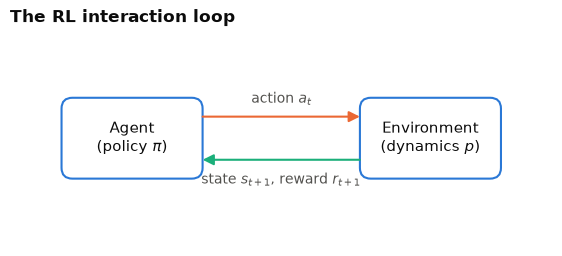

In [5]:
def draw_rl_loop():
    fig, ax = plt.subplots(figsize=(7, 2.8))
    ax.set_xlim(0, 10); ax.set_ylim(0, 4); ax.axis("off"); ax.grid(False)
    for (x, label) in [(1.0, "Agent\n(policy $\\pi$)"), (6.5, "Environment\n(dynamics $p$)")]:
        ax.add_patch(FancyBboxPatch((x, 1.3), 2.5, 1.4, boxstyle="round,pad=0.05,rounding_size=0.2",
                                    fc="white", ec=PALETTE[0], lw=1.5))
        ax.text(x + 1.25, 2.0, label, ha="center", va="center", fontsize=11, color=INK)
    ax.add_patch(FancyArrowPatch((3.5, 2.4), (6.5, 2.4), arrowstyle="-|>", mutation_scale=16, lw=1.5, color=PALETTE[1]))
    ax.text(5.0, 2.65, "action $a_t$", ha="center", color=INK2)
    ax.add_patch(FancyArrowPatch((6.5, 1.6), (3.5, 1.6), arrowstyle="-|>", mutation_scale=16, lw=1.5, color=PALETTE[2]))
    ax.text(5.0, 1.15, "state $s_{t+1}$, reward $r_{t+1}$", ha="center", color=INK2)
    ax.set_title("The RL interaction loop")
    plt.show()
draw_rl_loop()

## Markov decision processes

The standard formalisation is a **Markov decision process (MDP)** $(\mathcal S, \mathcal A, p, r, \gamma)$:

* $\mathcal S$: set of states, $\mathcal A$: set of actions.
* $p(s' \mid s, a)$: transition dynamics, the probability of landing in $s'$ after doing $a$ in $s$.
* $r(s, a, s')$: reward for that transition.
* $\gamma \in [0, 1)$: **discount factor**, how much we care about the future.

The **Markov property** says the next state and reward depend on the past *only through the current state*:
$p(s_{t+1} \mid s_t, a_t) = p(s_{t+1} \mid s_0, a_0, \dots, s_t, a_t)$. The state is a sufficient statistic
of history. (In Part 10 the "state" will be an entire text prefix, which makes this trivially true.)

### Our first environment: a stochastic GridWorld

A 5×5 grid. `S` is the start, `G` a goal worth +1, `P` a pit worth −1 (both terminal), `#` are walls.
Every step costs −0.04 so the agent has a reason to hurry. Moves are noisy: with probability `slip` the
agent goes sideways instead of where it intended. Because we build the transition tensor
`P[s, a, s']` explicitly, we can later do exact **planning** (Part 3) before doing any **learning** (Part 4).

In [6]:
class GridWorld:
    '''Small stochastic grid MDP with a known model (P, R) so we can plan exactly.
    Actions: 0=up, 1=right, 2=down, 3=left.  With prob `slip` the move goes sideways.'''
    MOVES = [(-1, 0), (0, 1), (1, 0), (0, -1)]
    ARROWS = ["↑", "→", "↓", "←"]

    def __init__(self, layout=("S....", ".#.#.", ".....", ".#.P.", "....G"),
                 slip=0.1, step_reward=-0.04, gamma=0.9):
        self.layout = [list(row) for row in layout]
        self.H, self.W = len(layout), len(layout[0])
        self.slip, self.step_reward, self.gamma = slip, step_reward, gamma
        # states = all non-wall cells, numbered row-major
        self.cells = [(r, c) for r in range(self.H) for c in range(self.W) if self.layout[r][c] != "#"]
        self.idx = {cell: i for i, cell in enumerate(self.cells)}
        self.nS, self.nA = len(self.cells), 4
        self.start = self.idx[next(cell for cell in self.cells if self._ch(cell) == "S")]
        self.terminal = np.array([self._ch(cell) in "GP" for cell in self.cells])
        self._build_model()

    def _ch(self, cell): return self.layout[cell[0]][cell[1]]

    def _move(self, cell, a):
        r, c = cell; dr, dc = self.MOVES[a]
        nr, nc = r + dr, c + dc
        if 0 <= nr < self.H and 0 <= nc < self.W and self.layout[nr][nc] != "#":
            return (nr, nc)
        return cell                       # bumping into a wall or the border: stay put

    def _build_model(self):
        '''Fill P[s,a,s'] (transition probabilities) and R[s,a,s'] (rewards).'''
        self.P = np.zeros((self.nS, self.nA, self.nS))
        self.R = np.zeros((self.nS, self.nA, self.nS))
        for s, cell in enumerate(self.cells):
            for a in range(self.nA):
                if self.terminal[s]:      # terminal states absorb with zero reward
                    self.P[s, a, s] = 1.0
                    continue
                outcomes = [(a, 1 - self.slip), ((a + 1) % 4, self.slip / 2), ((a - 1) % 4, self.slip / 2)]
                for a_actual, prob in outcomes:
                    s2 = self.idx[self._move(cell, a_actual)]
                    self.P[s, a, s2] += prob
                    ch = self._ch(self.cells[s2])
                    self.R[s, a, s2] = self.step_reward + (1.0 if ch == "G" else -1.0 if ch == "P" else 0.0)

    # --- the interaction interface used by learning algorithms ---
    def reset(self):
        self.s = self.start
        return self.s

    def step(self, a):
        s2 = np.random.choice(self.nS, p=self.P[self.s, a])
        r = self.R[self.s, a, s2]
        self.s = s2
        return s2, r, bool(self.terminal[s2])

env = GridWorld()
print(f"{env.nS} states, {env.nA} actions, start state {env.start}")
print("P sums to 1 over s' for every (s,a):", np.allclose(env.P.sum(-1), 1.0))

22 states, 4 actions, start state 0
P sums to 1 over s' for every (s,a): True


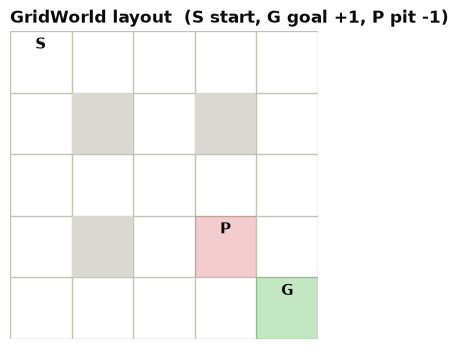

In [7]:
def render_grid(env, V=None, policy=None, title=None, ax=None, annotate=True, cmap="Blues"):
    '''Draw the grid. V: array of state values -> heatmap. policy: array of actions (or nS x nA probs) -> arrows.'''
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.0, 4.0))
    img = np.full((env.H, env.W), np.nan)
    for s, (r, c) in enumerate(env.cells):
        if not env.terminal[s]:                                # terminal cells are drawn separately
            img[r, c] = V[s] if V is not None else 0.0
    cm = plt.get_cmap(cmap if V is not None else "Greys").copy()
    cm.set_bad("white")
    if V is not None:
        vmin, vmax = float(np.nanmin(img)), float(np.nanmax(img))
        if vmax - vmin < 1e-9: vmax = vmin + 1e-9
    else:
        vmin, vmax = 0.0, 1.0
    ax.imshow(img, cmap=cm, vmin=vmin, vmax=vmax)
    for r in range(env.H):                                     # walls
        for c in range(env.W):
            if env.layout[r][c] == "#":
                ax.add_patch(Rectangle((c - .5, r - .5), 1, 1, fc="#d9d8d3", ec="none"))
    for s, (r, c) in enumerate(env.cells):                     # goal / pit washes
        if env.terminal[s]:
            col = "#0ca30c" if env._ch((r, c)) == "G" else "#d03b3b"
            ax.add_patch(Rectangle((c - .5, r - .5), 1, 1, fc=col, alpha=0.25, ec="none"))
    ax.set_xticks(np.arange(-.5, env.W, 1), minor=True); ax.set_yticks(np.arange(-.5, env.H, 1), minor=True)
    ax.grid(which="minor", color=AXIS, linewidth=1); ax.grid(which="major", visible=False)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    for spine in ax.spines.values(): spine.set_visible(False)
    if policy is not None:
        acts = np.asarray(policy).argmax(-1) if np.ndim(policy) == 2 else np.asarray(policy)
    for s, (r, c) in enumerate(env.cells):
        ch = env._ch((r, c))
        dark = V is not None and not env.terminal[s] and (img[r, c] - vmin) / (vmax - vmin) > 0.6
        col = "white" if dark else INK
        if ch in "SGP":
            ax.text(c, r - 0.28, ch, ha="center", va="center", fontsize=11, fontweight="bold", color=col)
        if policy is not None and not env.terminal[s]:
            ax.text(c, r + 0.05, env.ARROWS[acts[s]], ha="center", va="center", fontsize=15, color=col)
        if V is not None and annotate and not env.terminal[s]:
            ax.text(c, r + 0.34, f"{V[s]:.2f}", ha="center", va="center", fontsize=7, color=col)
    if title: ax.set_title(title)
    return ax

render_grid(env, title="GridWorld layout  (S start, G goal +1, P pit -1)")
plt.show()

## Returns and discounting

The agent wants to maximise the **return**, the discounted sum of future rewards:

$$G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \dots = \sum_{k=0}^{\infty} \gamma^k r_{t+k+1}$$

Discounting does three jobs: it keeps the sum finite, it expresses a preference for sooner rewards,
and it sets an **effective horizon** of roughly $1/(1-\gamma)$ steps. Note the recursion
$G_t = r_{t+1} + \gamma G_{t+1}$, which is the seed of every Bellman equation below.

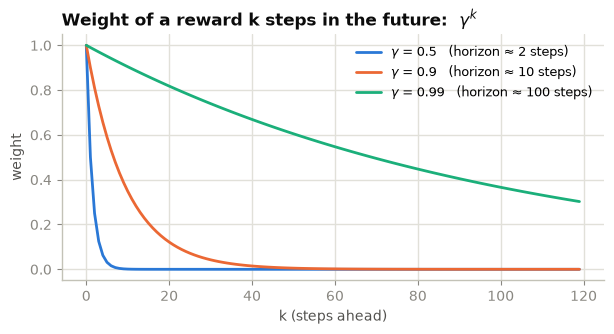

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.2))
t = np.arange(0, 120)
for g in [0.5, 0.9, 0.99]:
    ax.plot(t, g ** t, label=f"$\\gamma$ = {g}   (horizon ≈ {1/(1-g):.0f} steps)")
finish(ax, "Weight of a reward k steps in the future:  $\\gamma^k$", "k (steps ahead)", "weight")
plt.show()

## Policies and value functions

A **policy** $\pi(a \mid s)$ is a distribution over actions in each state. Given a policy, two functions
summarise how good things are:

$$V^\pi(s) = \mathbb E_\pi\big[G_t \mid s_t = s\big], \qquad Q^\pi(s, a) = \mathbb E_\pi\big[G_t \mid s_t = s, a_t = a\big].$$

Using $G_t = r_{t+1} + \gamma G_{t+1}$ and taking expectations gives the **Bellman expectation equation**:

$$V^\pi(s) = \sum_a \pi(a \mid s) \sum_{s'} p(s' \mid s, a)\big[r(s,a,s') + \gamma V^\pi(s')\big].$$

For a finite MDP this is a *linear* system. Writing $P_\pi[s, s'] = \sum_a \pi(a|s) p(s'|s,a)$ and
$R_\pi[s] = \sum_a \pi(a|s) \sum_{s'} p(s'|s,a) r(s,a,s')$:

$$V^\pi = R_\pi + \gamma P_\pi V^\pi \quad \Longrightarrow \quad V^\pi = (I - \gamma P_\pi)^{-1} R_\pi.$$

Let's evaluate the **uniform random policy** exactly.

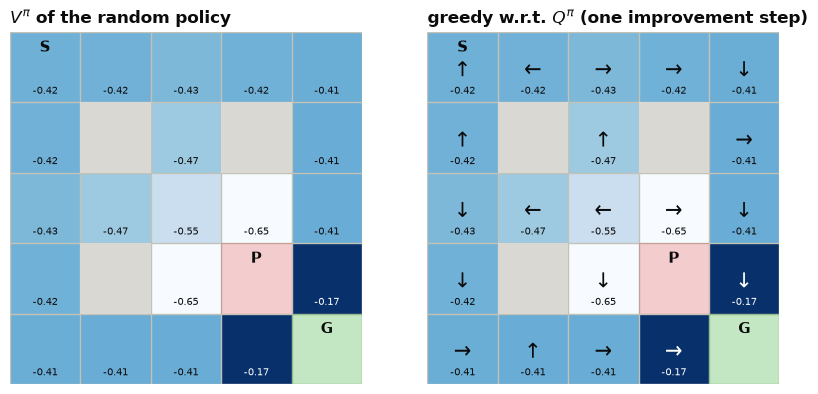

value of the start state under the random policy: -0.416


In [9]:
def evaluate_policy_exact(env, pi, gamma=None):
    '''Solve the Bellman expectation equation as a linear system. pi: (nS, nA) probabilities.'''
    gamma = env.gamma if gamma is None else gamma
    P_pi = np.einsum("sa,sat->st", pi, env.P)                       # (nS, nS)
    R_pi = np.einsum("sa,sat,sat->s", pi, env.P, env.R)             # (nS,)
    return np.linalg.solve(np.eye(env.nS) - gamma * P_pi, R_pi)

def q_from_v(env, V, gamma=None):
    '''Q(s,a) = sum_s' P[s,a,s'] (R[s,a,s'] + gamma V[s'])'''
    gamma = env.gamma if gamma is None else gamma
    return np.einsum("sat,sat->sa", env.P, env.R + gamma * V[None, None, :])

pi_random = np.full((env.nS, env.nA), 0.25)
V_random = evaluate_policy_exact(env, pi_random)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))
render_grid(env, V_random, ax=axes[0], title="$V^\\pi$ of the random policy")
render_grid(env, V_random, policy=q_from_v(env, V_random), ax=axes[1], title="greedy w.r.t. $Q^\\pi$ (one improvement step)")
plt.tight_layout(); plt.show()
print(f"value of the start state under the random policy: {V_random[env.start]:+.3f}")

Even one step of *acting greedily with respect to the random policy's Q-values* already points most
arrows toward the goal and away from the pit. That is the **policy improvement theorem**, and Part 3
turns it into an algorithm.

## Optimality

The **optimal** value functions satisfy the **Bellman optimality equations**, which replace the
expectation over $\pi$ with a max:

$$V^*(s) = \max_a \sum_{s'} p(s'|s,a)\big[r + \gamma V^*(s')\big], \qquad
Q^*(s,a) = \sum_{s'} p(s'|s,a)\big[r + \gamma \max_{a'} Q^*(s',a')\big].$$

Once we have $Q^*$ the optimal policy is trivial: $\pi^*(s) = \arg\max_a Q^*(s,a)$. Almost every
algorithm in this notebook is a way of approximating $V^*$, $Q^*$, or $\pi^*$ directly.

### Test your knowledge

In [10]:
register_quiz('1.1',
    'What does the Markov property say?',
    ['The reward depends only on the action taken.', 'The future depends on the past only through the current state.', 'The environment dynamics are deterministic.', 'The agent must remember all previous states to act optimally.'],
    'f455a89c01838e0281f0114a2bb49c8fb569324e37dbe891d79b2050ec8ac83d',
    'R2l2ZW4gc190IGFuZCBhX3QsIHRoZSBkaXN0cmlidXRpb24gb2Ygc197dCsxfSBhbmQgcl97dCsxfSBkb2VzIG5vdCBjaGFuZ2UgaWYgeW91IGFsc28gY29uZGl0aW9uIG9uIGVhcmxpZXIgaGlzdG9yeS4gVGhlIGN1cnJlbnQgc3RhdGUgYWxyZWFkeSBjb250YWlucyBldmVyeXRoaW5nIHJlbGV2YW50LCB3aGljaCBpcyBleGFjdGx5IHdoYXQgbWFrZXMgdmFsdWUgZnVuY3Rpb25zIG9mIHRoZSAqc3RhdGUqIG1lYW5pbmdmdWwu')
quiz('1.1')

QUIZ 1.1: What does the Markov property say?

   A)  The reward depends only on the action taken.
   B)  The future depends on the past only through the current state.
   C)  The environment dynamics are deterministic.
   D)  The agent must remember all previous states to act optimally.

-> put your choice in the answer('1.1', ...) cell below and run it.


In [11]:
answer('1.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [12]:
register_quiz('1.2',
    "Roughly how many steps into the future does an agent with gamma = 0.99 'care about'?",
    ['About 10 steps', 'Infinitely many, equally', 'About 1000 steps', 'About 100 steps'],
    '9bb7f55b6e6bf9e28faff0f272187473b68123d262417a0f50d1ab056d46ec94',
    'VGhlIGVmZmVjdGl2ZSBob3Jpem9uIGlzIGFib3V0IDEvKDEtZ2FtbWEpID0gMTAwIHN0ZXBzOiByZXdhcmRzIGJleW9uZCB0aGF0IGFyZSB3ZWlnaHRlZCBieSBsZXNzIHRoYW4gZV4tMSBvZiB0aGVpciBub21pbmFsIHZhbHVlLiBUaGlzIGlzIHdoeSBMTE0tUkwsIHdoZXJlIGVwaXNvZGVzIGFyZSBhIGZldyB0aG91c2FuZCB0b2tlbnMsIHR5cGljYWxseSB1c2VzIGdhbW1hID0gMS4=')
quiz('1.2')

QUIZ 1.2: Roughly how many steps into the future does an agent with gamma = 0.99 'care about'?

   A)  About 10 steps
   B)  Infinitely many, equally
   C)  About 1000 steps
   D)  About 100 steps

-> put your choice in the answer('1.2', ...) cell below and run it.


In [13]:
answer('1.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [14]:
register_quiz('1.3',
    "Suppose we change GridWorld's step reward from -0.04 to +0.5 (gamma stays 0.9). What does the optimal policy do?",
    ['Avoids both terminal states so it can collect +0.5 forever.', 'Becomes undefined because returns are infinite.', 'Still rushes to the goal, rewards are relative.', 'Goes to the pit, because -1 is now less bad than before.'],
    'c2f6a9981b44984f08ffe1b7a8de443348395d338b4abb4c87f6801ace5ba449',
    'U3RheWluZyBhbGl2ZSBmb3JldmVyIGlzIHdvcnRoIDAuNS8oMS0wLjkpID0gNSwgZmFyIG1vcmUgdGhhbiB0aGUgZ29hbCdzICsxLiBUaGUgb3B0aW1hbCBwb2xpY3kgaHVncyB3YWxscyBhbmQgbmV2ZXIgdGVybWluYXRlcy4gUmV3YXJkIGRlc2lnbiBkZXRlcm1pbmVzIGJlaGF2aW91cjsgdGhpcyBpcyB0aGUgdG95IHZlcnNpb24gb2YgJ3Jld2FyZCBoYWNraW5nJy4=')
quiz('1.3')

QUIZ 1.3: Suppose we change GridWorld's step reward from -0.04 to +0.5 (gamma stays 0.9). What does the optimal policy do?

   A)  Avoids both terminal states so it can collect +0.5 forever.
   B)  Becomes undefined because returns are infinite.
   C)  Still rushes to the goal, rewards are relative.
   D)  Goes to the pit, because -1 is now less bad than before.

-> put your choice in the answer('1.3', ...) cell below and run it.


In [15]:
answer('1.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


---
# Part 2 · Bandits: exploration versus exploitation

Strip the MDP down to a single state and you get the **k-armed bandit**: each step you pull one of $k$
arms and receive a noisy reward whose mean $q^*(a)$ you don't know. There is no state to worry about,
which isolates one core problem of RL: **should I pull the arm that looks best (exploit), or try
another one to learn more (explore)?**

We estimate action values by averaging observed rewards. The incremental form, which every later
algorithm reuses, is

$$Q_{n+1}(a) = Q_n(a) + \alpha\,\big[r_n - Q_n(a)\big], \qquad \alpha = \tfrac{1}{N(a)} \text{ (sample average) or a constant.}$$

*New estimate = old estimate + step size × (target − old estimate)*. Memorise that shape.

Three classic strategies:

* **ε-greedy**: with probability ε pick a random arm, otherwise the greedy one.
* **UCB** (upper confidence bound): pick $\arg\max_a\; Q(a) + c\sqrt{\ln t / N(a)}$. The bonus is large for
  arms we've tried rarely: *optimism in the face of uncertainty*.
* **Optimistic initialisation**: start all $Q(a)$ high, so every arm looks disappointing after a try and
  the greedy agent explores by itself.

In [16]:
class Bandit:
    '''k arms with Gaussian rewards. q_star ~ N(0, 1), reward ~ N(q_star[a], 1).'''
    def __init__(self, k=10):
        self.k = k
        self.q_star = np.random.randn(k)
        self.best = int(self.q_star.argmax())
    def pull(self, a):
        return self.q_star[a] + np.random.randn()

class EpsGreedy:
    def __init__(self, k, eps=0.1, q0=0.0, alpha=None):
        self.eps, self.alpha = eps, alpha
        self.Q = np.full(k, float(q0)); self.N = np.zeros(k)
    def act(self, t):
        if np.random.rand() < self.eps:
            return np.random.randint(len(self.Q))
        return int(np.argmax(self.Q + 1e-9 * np.random.rand(len(self.Q))))   # random tie-break
    def update(self, a, r):
        self.N[a] += 1
        step = (1.0 / self.N[a]) if self.alpha is None else self.alpha
        self.Q[a] += step * (r - self.Q[a])

class UCB(EpsGreedy):
    def __init__(self, k, c=2.0):
        super().__init__(k, eps=0.0); self.c = c
    def act(self, t):
        if (self.N == 0).any():                       # try every arm once first
            return int(np.argmin(self.N))
        return int(np.argmax(self.Q + self.c * np.sqrt(np.log(t + 1) / self.N)))

def run_bandits(make_agent, n_runs=200, n_steps=1000, k=10):
    '''Returns (reward[n_runs, n_steps], optimal[n_runs, n_steps]) for a factory of agents.'''
    rewards = np.zeros((n_runs, n_steps)); optimal = np.zeros((n_runs, n_steps))
    for run in range(n_runs):
        bandit, agent = Bandit(k), make_agent(k)
        for t in range(n_steps):
            a = agent.act(t); r = bandit.pull(a); agent.update(a, r)
            rewards[run, t] = r; optimal[run, t] = (a == bandit.best)
    return rewards, optimal

seed_everything(0)
with Timer("bandit experiments"):
    results = {
        "greedy (ε=0)":        run_bandits(lambda k: EpsGreedy(k, eps=0.0)),
        "ε-greedy (ε=0.1)":    run_bandits(lambda k: EpsGreedy(k, eps=0.1)),
        "ε-greedy (ε=0.01)":   run_bandits(lambda k: EpsGreedy(k, eps=0.01)),
        "UCB (c=2)":           run_bandits(lambda k: UCB(k, c=2.0)),
        "optimistic (Q0=5, ε=0)": run_bandits(lambda k: EpsGreedy(k, eps=0.0, q0=5.0, alpha=0.1)),
    }

[bandit experiments] 7.1s


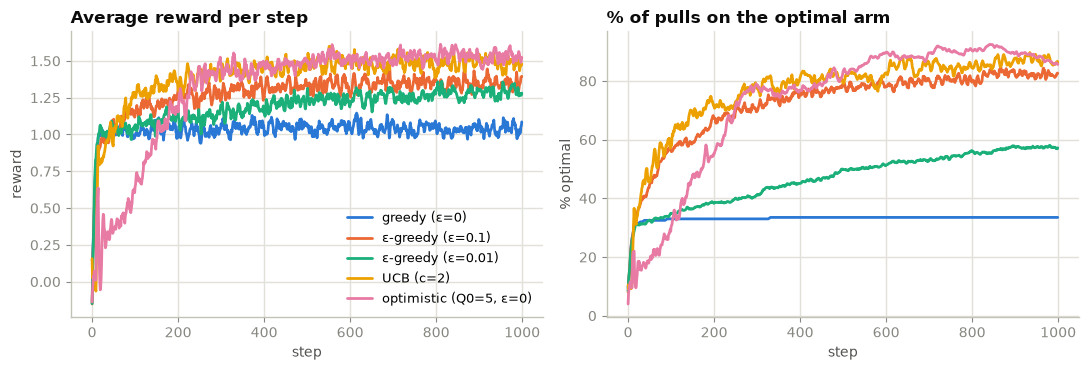

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name, (rew, opt) in results.items():
    plot_runs(axes[0], [rew.mean(0)], label=name, k=5)
    plot_runs(axes[1], [100 * opt.mean(0)], label=name, k=5)
finish(axes[0], "Average reward per step", "step", "reward")
finish(axes[1], "% of pulls on the optimal arm", "step", "% optimal", legend=False)
plt.tight_layout(); plt.show()

**Reading the plot.** Pure greedy locks onto the first arm that looked good and never recovers.
ε = 0.1 learns fast but pays a permanent 10% exploration tax; ε = 0.01 is still catching up after 1000
steps, and only overtakes ε = 0.1 on much longer runs because its tax is ten times smaller (try `n_steps=5000`).
UCB and optimistic initialisation explore *systematically* and then stop exploring, which is why
they win in the long run. There is no free lunch: every exploration strategy trades short-term reward for
information.

**Why this matters later.** When we do RL on language models (Parts 10–17) the "arms" are the
astronomically many possible completions. Sampling $k$ completions per prompt and keeping the good
ones (GRPO's *group*) is exactly a bandit-style exploration, and the pass@k metric measures how much
"exploration" the base model still has in it.

### Test your knowledge

In [18]:
register_quiz('2.1',
    'In UCB, the bonus term c*sqrt(ln t / N(a)) is largest for which arms?',
    ['The arm pulled most recently', 'Arms that have been pulled the fewest times', 'Arms with the highest observed reward variance', 'Arms with the highest estimated value'],
    'd6bd04278582dd95141635b6255207da94c53096cb16b41f30e6284a2bb156dd',
    'TihhKSBpbiB0aGUgZGVub21pbmF0b3IgbWFrZXMgdGhlIGJvbnVzIHNocmluayBhcyBhbiBhcm0gZ2V0cyBwdWxsZWQuIFRoZSBsbiB0IGluIHRoZSBudW1lcmF0b3IgZ3Jvd3Mgc2xvd2x5IHNvIHRoYXQgZXZlcnkgYXJtIGlzIGV2ZW50dWFsbHkgcmUtdHJpZWQuIFJhcmVseSB0cmllZCBhcm1zIGFyZSB0cmVhdGVkIG9wdGltaXN0aWNhbGx5Lg==')
quiz('2.1')

QUIZ 2.1: In UCB, the bonus term c*sqrt(ln t / N(a)) is largest for which arms?

   A)  The arm pulled most recently
   B)  Arms that have been pulled the fewest times
   C)  Arms with the highest observed reward variance
   D)  Arms with the highest estimated value

-> put your choice in the answer('2.1', ...) cell below and run it.


In [19]:
answer('2.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [20]:
register_quiz('2.2',
    'Why does a greedy agent with optimistic initial values (Q0 = 5) explore at all?',
    ["It doesn't; the curve is a coincidence.", 'Every arm it tries returns less than 5, so its estimate drops below the untried arms, which still look like 5.', 'It uses a hidden epsilon.', 'Optimistic values increase the reward variance.'],
    '7b19c54fe35cd665d65ba812625dab3a13c103741d079047e75ccd94977863ae',
    'RGlzYXBwb2ludG1lbnQgZHJpdmVzIGV4cGxvcmF0aW9uOiBlYWNoIHB1bGwgbG93ZXJzIHRoYXQgYXJtJ3MgZXN0aW1hdGUgdG93YXJkIGl0cyB0cnVlIG1lYW4gKDwgNSksIG1ha2luZyB0aGUgc3RpbGwtdW50cmllZCBhcm1zIGxvb2sgYmV0dGVyLiBPbmNlIGV2ZXJ5IGFybSBoYXMgYmVlbiBzYW1wbGVkIGVub3VnaCwgZXhwbG9yYXRpb24gc3RvcHMgYnkgaXRzZWxmLiBUaGlzIG9ubHkgd29ya3Mgd2l0aCBzdGF0aW9uYXJ5IHByb2JsZW1zIGFuZCBhIGNvbnN0YW50IHN0ZXAgc2l6ZSBhbHBoYS4=')
quiz('2.2')

QUIZ 2.2: Why does a greedy agent with optimistic initial values (Q0 = 5) explore at all?

   A)  It doesn't; the curve is a coincidence.
   B)  Every arm it tries returns less than 5, so its estimate drops below the untried arms, which still look like 5.
   C)  It uses a hidden epsilon.
   D)  Optimistic values increase the reward variance.

-> put your choice in the answer('2.2', ...) cell below and run it.


In [21]:
answer('2.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 2.3 · Gradient bandit

Instead of estimating values, learn a **preference** $H(a)$ per arm and act with a softmax
$\pi(a) = e^{H(a)} / \sum_b e^{H(b)}$. After receiving reward $r$ for action $a$ with a baseline $\bar r$
(the running average reward), the update is

$$H(a) \leftarrow H(a) + \alpha (r - \bar r)(1 - \pi(a)), \qquad H(b) \leftarrow H(b) - \alpha (r - \bar r)\pi(b) \;\; \text{for } b \ne a.$$

Implement `gradient_bandit_update(H, a, r, baseline, alpha)` returning the **new** preference vector.
This is a policy-gradient method in disguise; Part 6 derives the general version.

In [22]:
def gradient_bandit_update(H, a, r, baseline, alpha):
    '''H: np.array of preferences. Return the updated copy.'''
    # YOUR CODE HERE
    raise NotImplementedError

In [23]:
register_exercise('2.3', 'ZGVmIGdyYWRpZW50X2JhbmRpdF91cGRhdGUoSCwgYSwgciwgYmFzZWxpbmUsIGFscGhhKToKICAgIHBpID0gbnAuZXhwKEggLSBILm1heCgpKTsgcGkgLz0gcGkuc3VtKCkKICAgIG9uZWhvdCA9IG5wLnplcm9zX2xpa2UoSCk7IG9uZWhvdFthXSA9IDEuMAogICAgcmV0dXJuIEggKyBhbHBoYSAqIChyIC0gYmFzZWxpbmUpICogKG9uZWhvdCAtIHBpKQ==')

def _tests(fn):
    H = np.array([0.0, 0.0, 0.0]); out = fn(H.copy(), 1, r=2.0, baseline=1.0, alpha=0.1)
    assert out is not None, "function returned None"
    pi = np.exp(H) / np.exp(H).sum()
    expected = H - 0.1 * (2.0 - 1.0) * pi; expected[1] += 0.1 * (2.0 - 1.0)
    assert np.allclose(out, expected), f"expected {expected}, got {out}"
    H2 = np.array([1.0, -1.0]); out2 = fn(H2.copy(), 0, r=-0.5, baseline=0.5, alpha=0.2)
    pi2 = np.exp(H2) / np.exp(H2).sum()
    exp2 = H2 - 0.2 * (-1.0) * pi2; exp2[0] += 0.2 * (-1.0)
    assert np.allclose(out2, exp2), "wrong update when reward is below the baseline"

check('2.3', gradient_bandit_update, _tests)
# solution('2.3')   # <- uncomment to reveal the reference solution

[2.3] not implemented yet. Fill in the cell above (or run solution('2.3')).


---
# Part 3 · Dynamic programming: planning with a known model

When we *know* $p$ and $r$ we don't need to interact at all; we can compute $V^*$ by turning the Bellman
equations into update rules. This is **dynamic programming (DP)**. It doesn't scale to real problems
(you rarely know the model, and the state space is usually enormous), but every sample-based method
in later parts is an approximation of one of these two algorithms.

### Policy evaluation as a fixed-point iteration

Define the Bellman operator $(T^\pi V)(s) = \sum_a \pi(a|s)\sum_{s'} p(s'|s,a)[r + \gamma V(s')]$.
It is a **γ-contraction** in the max-norm: $\|T^\pi V - T^\pi U\|_\infty \le \gamma \|V - U\|_\infty$.
So iterating $V \leftarrow T^\pi V$ from any start converges to the unique fixed point $V^\pi$, and the
error shrinks by a factor $\gamma$ per sweep.

### Policy iteration

Alternate two steps until the policy stops changing:

1. **Evaluate** the current policy: compute $V^\pi$ (iteratively or by solving the linear system).
2. **Improve** it: $\pi'(s) = \arg\max_a Q^\pi(s,a)$. The policy improvement theorem guarantees $V^{\pi'} \ge V^\pi$.

### Value iteration

Skip the full evaluation and apply the *optimality* operator directly:
$V(s) \leftarrow \max_a \sum_{s'} p(s'|s,a)[r + \gamma V(s')]$. Also a γ-contraction, converging to $V^*$.

In [24]:
def policy_evaluation(env, pi, gamma=None, theta=1e-8, max_sweeps=10_000, V0=None):
    '''Iterative policy evaluation: sweep V <- T^pi V until the max change < theta.'''
    gamma = env.gamma if gamma is None else gamma
    V = np.zeros(env.nS) if V0 is None else V0.copy()
    for sweep in range(max_sweeps):
        Q = q_from_v(env, V, gamma)                # (nS, nA)
        V_new = (pi * Q).sum(1)
        delta = np.abs(V_new - V).max()
        V = V_new
        if delta < theta:
            break
    return V, sweep + 1

def greedy_policy(env, V, gamma=None):
    '''Deterministic greedy policy w.r.t. V, returned as a (nS, nA) one-hot matrix.'''
    Q = q_from_v(env, V, gamma)
    pi = np.zeros_like(Q); pi[np.arange(env.nS), Q.argmax(1)] = 1.0
    return pi

def policy_iteration(env, gamma=None, verbose=True):
    pi = np.full((env.nS, env.nA), 1.0 / env.nA)
    history = []
    for it in range(100):
        V, sweeps = policy_evaluation(env, pi, gamma)
        pi_new = greedy_policy(env, V, gamma)
        history.append((V, pi_new))
        if verbose:
            print(f"iteration {it}: evaluation took {sweeps:4d} sweeps, V(start) = {V[env.start]:+.3f}")
        if np.array_equal(pi_new, pi):
            break
        pi = pi_new
    return V, pi, history

V_pi, pi_star, hist = policy_iteration(env)

iteration 0: evaluation took  127 sweeps, V(start) = -0.416
iteration 1: evaluation took  146 sweeps, V(start) = -0.400
iteration 2: evaluation took   24 sweeps, V(start) = +0.145
iteration 3: evaluation took   23 sweeps, V(start) = +0.149


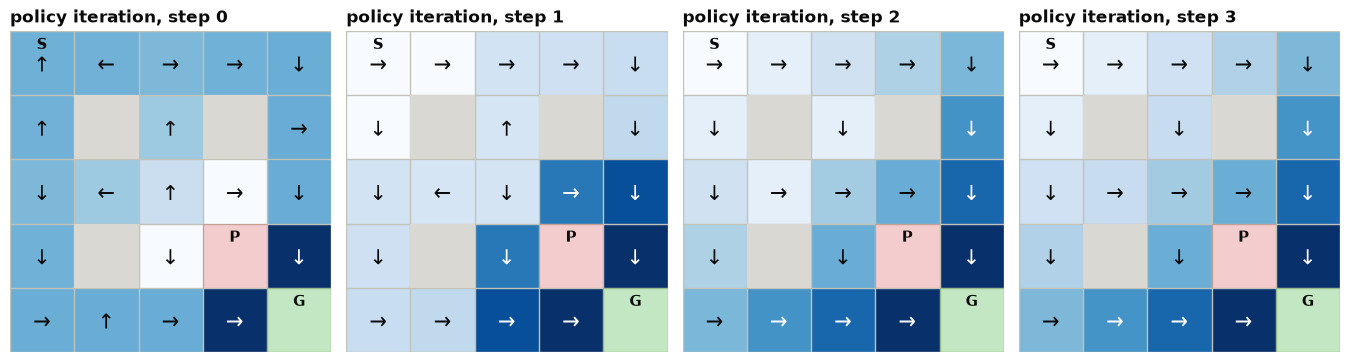

In [25]:
fig, axes = plt.subplots(1, len(hist), figsize=(3.4 * len(hist), 3.6))
for k, (ax, (V, pi)) in enumerate(zip(np.atleast_1d(axes), hist)):
    render_grid(env, V, policy=pi, ax=ax, title=f"policy iteration, step {k}", annotate=False)
plt.tight_layout(); plt.show()

value iteration agrees with policy iteration: True | same greedy policy: True


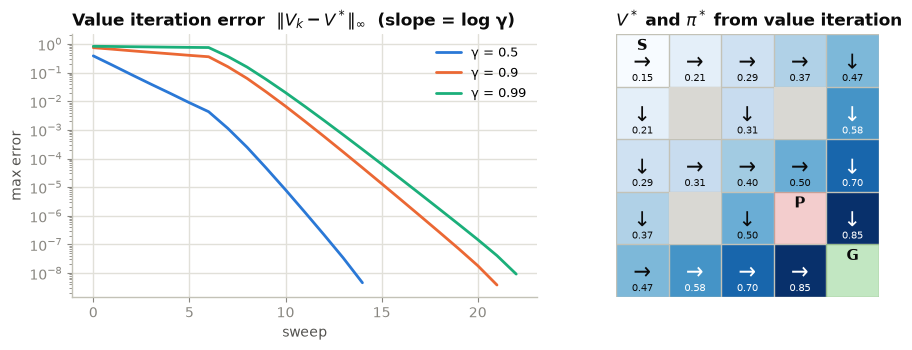

In [26]:
def value_iteration(env, gamma=None, theta=1e-8, max_sweeps=10_000, track=None):
    '''V <- max_a sum_s' P (R + gamma V).  Optionally records ||V_k - track||_inf per sweep.'''
    gamma = env.gamma if gamma is None else gamma
    V = np.zeros(env.nS); errors = []
    for sweep in range(max_sweeps):
        V_new = q_from_v(env, V, gamma).max(1)
        if track is not None:
            errors.append(np.abs(V_new - track).max())
        delta = np.abs(V_new - V).max(); V = V_new
        if delta < theta:
            break
    return V, greedy_policy(env, V, gamma), errors

V_star, pi_vi, errs = value_iteration(env, track=V_pi)
print("value iteration agrees with policy iteration:", np.allclose(V_star, V_pi, atol=1e-6),
      "| same greedy policy:", np.array_equal(pi_vi, pi_star))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for g in [0.5, 0.9, 0.99]:
    Vg, _, _ = value_iteration(env, gamma=g)
    _, _, e = value_iteration(env, gamma=g, track=Vg)
    axes[0].plot(e[:-1], label=f"γ = {g}")
axes[0].set_yscale("log")
finish(axes[0], "Value iteration error  $\\|V_k - V^*\\|_\\infty$  (slope = log γ)", "sweep", "max error")
render_grid(env, V_star, policy=pi_vi, ax=axes[1], title="$V^*$ and $\\pi^*$ from value iteration")
plt.tight_layout(); plt.show()

The error curve on the left is a straight line on a log scale: that is the contraction at work, with
slope $\log\gamma$. A larger $\gamma$ means a longer horizon **and** slower convergence, a tension
that reappears in every algorithm (bootstrapping over long horizons is slow and unstable).

Notice in the optimal policy how the agent, at the cell just left of the pit, prefers to move *up* or
*down* rather than *right* toward the goal: with 10% slip it is worth a detour to avoid a chance of falling in.

### Test your knowledge

In [27]:
register_quiz('3.1',
    'Why does iterative policy evaluation converge from any initial V?',
    ['Because the policy is deterministic', 'Because V is initialised to zero', 'Because rewards are bounded', 'Because the Bellman operator is a gamma-contraction in the max-norm, so it has a unique fixed point'],
    'd5ce4d867b0c1e6013fcf403717e279a6ae50e6a5f28b5ba074277afe871a0bf',
    'QmFuYWNoJ3MgZml4ZWQtcG9pbnQgdGhlb3JlbTogYSBjb250cmFjdGlvbiBvbiBhIGNvbXBsZXRlIG1ldHJpYyBzcGFjZSBoYXMgZXhhY3RseSBvbmUgZml4ZWQgcG9pbnQsIGFuZCBpdGVyYXRpbmcgdGhlIG1hcCBjb252ZXJnZXMgdG8gaXQgZ2VvbWV0cmljYWxseS4gVGhhdCBmaXhlZCBwb2ludCBpcyBWXnBpLiBUaGUgc2FtZSBhcmd1bWVudCBjb3ZlcnMgdmFsdWUgaXRlcmF0aW9uICh0aGUgb3B0aW1hbGl0eSBvcGVyYXRvciBpcyBhbHNvIGEgZ2FtbWEtY29udHJhY3Rpb24pLg==')
quiz('3.1')

QUIZ 3.1: Why does iterative policy evaluation converge from any initial V?

   A)  Because the policy is deterministic
   B)  Because V is initialised to zero
   C)  Because rewards are bounded
   D)  Because the Bellman operator is a gamma-contraction in the max-norm, so it has a unique fixed point

-> put your choice in the answer('3.1', ...) cell below and run it.


In [28]:
answer('3.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [29]:
register_quiz('3.2',
    'Policy iteration converged in a handful of outer iterations while each evaluation took many sweeps. Value iteration needs no inner loop. When is value iteration preferable?',
    ['Never, policy iteration is always cheaper', 'When gamma is exactly 1', 'When a full policy evaluation per iteration is too expensive and we are happy to improve the policy from partially-evaluated values', 'When the model is unknown'],
    'eac6cb99993f0e2a05b67ae82ad79830d59912766259825baf991d7583a47392',
    'VmFsdWUgaXRlcmF0aW9uIGlzIHBvbGljeSBpdGVyYXRpb24gd2l0aCBhIHNpbmdsZSBldmFsdWF0aW9uIHN3ZWVwIHBlciBpbXByb3ZlbWVudCAoYSAndHJ1bmNhdGVkJyBldmFsdWF0aW9uKS4gR2VuZXJhbGlzZWQgcG9saWN5IGl0ZXJhdGlvbiBpbnRlcmxlYXZlcyBldmFsdWF0aW9uIGFuZCBpbXByb3ZlbWVudCBhdCBhbnkgZ3JhbnVsYXJpdHksIHdoaWNoIGlzIHdoYXQgYWN0b3ItY3JpdGljIG1ldGhvZHMgZG8gd2l0aCBmdW5jdGlvbiBhcHByb3hpbWF0aW9uLg==')
quiz('3.2')

QUIZ 3.2: Policy iteration converged in a handful of outer iterations while each evaluation took many sweeps. Value iteration needs no inner loop. When is value iteration preferable?

   A)  Never, policy iteration is always cheaper
   B)  When gamma is exactly 1
   C)  When a full policy evaluation per iteration is too expensive and we are happy to improve the policy from partially-evaluated values
   D)  When the model is unknown

-> put your choice in the answer('3.2', ...) cell below and run it.


In [30]:
answer('3.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 3.3 · Q-value iteration

Run value iteration directly on **Q** instead of V:

$$Q(s,a) \leftarrow \sum_{s'} p(s'|s,a)\big[r(s,a,s') + \gamma \max_{a'} Q(s',a')\big].$$

Implement `q_value_iteration(env, gamma, theta)` returning the converged `Q` of shape `(nS, nA)`.
Hint: `env.P`, `env.R` have shape `(nS, nA, nS)`; `np.einsum("sat,sat->sa", ...)` is your friend.

In [31]:
def q_value_iteration(env, gamma=0.9, theta=1e-8):
    Q = np.zeros((env.nS, env.nA))
    # YOUR CODE HERE
    raise NotImplementedError
    return Q

In [32]:
register_exercise('3.3', 'ZGVmIHFfdmFsdWVfaXRlcmF0aW9uKGVudiwgZ2FtbWE9MC45LCB0aGV0YT0xZS04KToKICAgIFEgPSBucC56ZXJvcygoZW52Lm5TLCBlbnYubkEpKQogICAgd2hpbGUgVHJ1ZToKICAgICAgICB0YXJnZXQgPSBlbnYuUiArIGdhbW1hICogUS5tYXgoMSlbTm9uZSwgTm9uZSwgOl0gICAgICAgICMgKG5TLCBuQSwgblMnKQogICAgICAgIFFfbmV3ID0gbnAuZWluc3VtKCJzYXQsc2F0LT5zYSIsIGVudi5QLCB0YXJnZXQpCiAgICAgICAgaWYgbnAuYWJzKFFfbmV3IC0gUSkubWF4KCkgPCB0aGV0YToKICAgICAgICAgICAgcmV0dXJuIFFfbmV3CiAgICAgICAgUSA9IFFfbmV3')

def _tests(fn):
    Q = fn(env, gamma=0.9)
    assert Q is not None and Q.shape == (env.nS, env.nA), "wrong shape"
    V_ref, _, _ = value_iteration(env, gamma=0.9)
    assert np.allclose(Q.max(1), V_ref, atol=1e-5), "max_a Q(s,a) should equal V*(s)"
    assert np.all(Q.max(1) >= Q.min(1)), "sanity"

check('3.3', q_value_iteration, _tests)
# solution('3.3')   # <- uncomment to reveal the reference solution

[3.3] not implemented yet. Fill in the cell above (or run solution('3.3')).


---
# Part 4 · Model-free learning: Monte Carlo, TD, SARSA, Q-learning

Now throw away the model. The agent only gets samples $(s, a, r, s')$ from interaction and must learn
values from them. Two families:

* **Monte Carlo (MC)**: wait until the episode ends, compute the actual return $G_t$, and move the estimate
  toward it: $V(s_t) \leftarrow V(s_t) + \alpha[G_t - V(s_t)]$. Unbiased, but high variance (a whole
  episode of randomness enters every target).
* **Temporal difference (TD)**: don't wait; use the next state's *current estimate* as a stand-in for the
  rest of the return, i.e. **bootstrap**: $V(s_t) \leftarrow V(s_t) + \alpha[\,r_{t+1} + \gamma V(s_{t+1}) - V(s_t)\,]$.
  Lower variance, but biased while $V$ is wrong.

The quantity $\delta_t = r_{t+1} + \gamma V(s_{t+1}) - V(s_t)$ is the **TD error**. It is the single most
reused idea in RL; it will be the "advantage" in actor-critic methods and the per-step ingredient of GAE.

Let's compare both for *prediction* (estimating $V^\pi$ for the random policy) against the exact answer
from Part 1.

[MC vs TD prediction] 9.9s


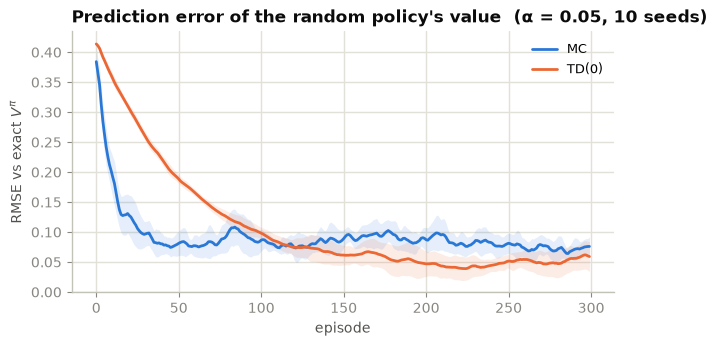

In [33]:
def run_episode(env, pi, max_steps=200):
    '''Sample one episode under a (nS, nA) stochastic policy. Returns lists of states, actions, rewards.'''
    s = env.reset(); S, A, R = [s], [], []
    for _ in range(max_steps):
        a = np.random.choice(env.nA, p=pi[s])
        s, r, done = env.step(a)
        A.append(a); R.append(r); S.append(s)
        if done: break
    return S, A, R

def mc_prediction(env, pi, n_episodes, alpha=0.05, gamma=None, V_true=None):
    '''Every-visit Monte Carlo with a constant step size. Returns RMSE-vs-episode if V_true is given.'''
    gamma = env.gamma if gamma is None else gamma
    V = np.zeros(env.nS); errs = []
    for _ in range(n_episodes):
        S, A, R = run_episode(env, pi)
        G = 0.0
        for t in reversed(range(len(R))):             # walk backwards to accumulate returns
            G = R[t] + gamma * G
            V[S[t]] += alpha * (G - V[S[t]])
        if V_true is not None: errs.append(np.sqrt(np.mean((V - V_true) ** 2)))
    return V, errs

def td0_prediction(env, pi, n_episodes, alpha=0.05, gamma=None, V_true=None):
    gamma = env.gamma if gamma is None else gamma
    V = np.zeros(env.nS); errs = []
    for _ in range(n_episodes):
        s = env.reset()
        for _ in range(200):
            a = np.random.choice(env.nA, p=pi[s])
            s2, r, done = env.step(a)
            target = r + (0.0 if done else gamma * V[s2])      # bootstrap unless terminal
            V[s] += alpha * (target - V[s])
            s = s2
            if done: break
        if V_true is not None: errs.append(np.sqrt(np.mean((V - V_true) ** 2)))
    return V, errs

seed_everything(1)
curves = {"MC": [], "TD(0)": []}
with Timer("MC vs TD prediction"):
    for run in range(10):
        curves["MC"].append(mc_prediction(env, pi_random, 300, V_true=V_random)[1])
        curves["TD(0)"].append(td0_prediction(env, pi_random, 300, V_true=V_random)[1])

fig, ax = plt.subplots(figsize=(7, 3.4))
for name, runs in curves.items():
    plot_runs(ax, runs, label=name, k=3)
finish(ax, "Prediction error of the random policy's value  (α = 0.05, 10 seeds)", "episode", "RMSE vs exact $V^\\pi$")
plt.show()

TD(0) drops faster and settles lower at this step size: bootstrapping trades a little bias for a lot
less variance. The gap widens with longer episodes, which is why almost all deep RL bootstraps.

## Control: learning Q and acting on it

To improve the policy we need action values. Three updates for $Q(s,a)$ after observing $(s,a,r,s')$
and (for SARSA) the next action $a'$ chosen by the current policy:

| Algorithm | Target | Type |
|---|---|---|
| **SARSA** | $r + \gamma\, Q(s', a')$ | on-policy: learns the value of the policy it follows, exploration included |
| **Q-learning** | $r + \gamma\, \max_{a'} Q(s', a')$ | off-policy: learns $Q^*$ regardless of how it explores |
| **Expected SARSA** | $r + \gamma \sum_{a'} \pi(a'|s')\, Q(s', a')$ | on-policy, but averages out the randomness of $a'$ |

We'll use the classic **CliffWalk** environment (Sutton & Barto, Example 6.6): a 4×12 grid, every step
costs −1, and stepping off the cliff costs −100 and sends you back to the start. The shortest path
runs right along the cliff edge. With ε-greedy exploration, is that path really the best one to *follow*?

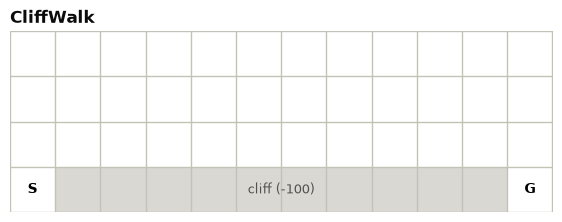

In [34]:
class CliffWalk:
    '''4x12 grid. Start bottom-left, goal bottom-right, cliff in between. Deterministic moves.'''
    MOVES = [(-1, 0), (0, 1), (1, 0), (0, -1)]
    ARROWS = ["↑", "→", "↓", "←"]
    def __init__(self, H=4, W=12):
        self.H, self.W, self.nA = H, W, 4
        self.nS = H * W
        self.start, self.goal = (H - 1, 0), (H - 1, W - 1)
        self.cliff = {(H - 1, c) for c in range(1, W - 1)}
    def _id(self, cell): return cell[0] * self.W + cell[1]
    def reset(self):
        self.pos = self.start; return self._id(self.pos)
    def step(self, a):
        r, c = self.pos; dr, dc = self.MOVES[a]
        nr, nc = min(max(r + dr, 0), self.H - 1), min(max(c + dc, 0), self.W - 1)
        self.pos = (nr, nc)
        if self.pos in self.cliff:
            self.pos = self.start
            return self._id(self.pos), -100.0, False
        return self._id(self.pos), -1.0, self.pos == self.goal

def render_cliff(env, Q=None, paths=None, ax=None, title=None):
    if ax is None: fig, ax = plt.subplots(figsize=(7, 2.6))
    img = np.zeros((env.H, env.W))
    for (r, c) in env.cliff: img[r, c] = 1.0
    ax.imshow(img, cmap=mpl.colors.ListedColormap(["white", "#d9d8d3"]))
    ax.set_xticks(np.arange(-.5, env.W, 1), minor=True); ax.set_yticks(np.arange(-.5, env.H, 1), minor=True)
    ax.grid(which="minor", color=AXIS, linewidth=1); ax.grid(which="major", visible=False)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.text(env.start[1], env.start[0], "S", ha="center", va="center", fontweight="bold")
    ax.text(env.goal[1], env.goal[0], "G", ha="center", va="center", fontweight="bold")
    ax.text((env.W - 1) / 2, env.H - 1, "cliff (-100)", ha="center", va="center", color=INK2, fontsize=9)
    if Q is not None:
        for s in range(env.nS):
            r, c = divmod(s, env.W)
            if (r, c) in env.cliff or (r, c) == env.goal: continue
            ax.text(c, r, env.ARROWS[int(Q[s].argmax())], ha="center", va="center", fontsize=11, color=INK2)
    if paths:
        for (name, path, color) in paths:
            rc = np.array([divmod(s, env.W) for s in path])
            ax.plot(rc[:, 1], rc[:, 0], color=color, lw=2.5, alpha=0.9, label=name, solid_capstyle="round")
        ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
    if title: ax.set_title(title)
    return ax

cliff = CliffWalk()
render_cliff(cliff, title="CliffWalk"); plt.show()

[CliffWalk control] 3.0s


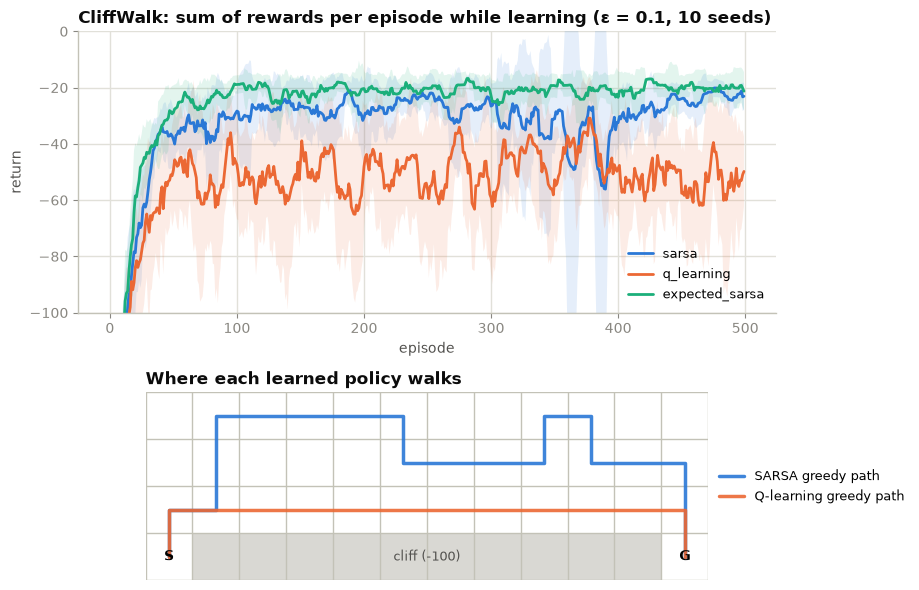

In [35]:
def eps_greedy(Q, s, eps):
    if np.random.rand() < eps:
        return np.random.randint(Q.shape[1])
    return int(np.argmax(Q[s] + 1e-9 * np.random.rand(Q.shape[1])))

def td_control(env, method="q_learning", n_episodes=500, alpha=0.5, gamma=1.0, eps=0.1, max_steps=500):
    '''One generic loop; `method` picks the target: 'sarsa' | 'q_learning' | 'expected_sarsa'.'''
    Q = np.zeros((env.nS, env.nA)); returns = []
    for ep in range(n_episodes):
        s = env.reset(); a = eps_greedy(Q, s, eps); total = 0.0
        for _ in range(max_steps):
            s2, r, done = env.step(a); total += r
            a2 = eps_greedy(Q, s2, eps)                          # the action we will actually take next
            if done:
                target = r
            elif method == "sarsa":
                target = r + gamma * Q[s2, a2]
            elif method == "q_learning":
                target = r + gamma * Q[s2].max()
            elif method == "expected_sarsa":
                probs = np.full(env.nA, eps / env.nA); probs[Q[s2].argmax()] += 1 - eps
                target = r + gamma * (probs * Q[s2]).sum()
            Q[s, a] += alpha * (target - Q[s, a])
            s, a = s2, a2
            if done: break
        returns.append(total)
    return Q, returns

def greedy_path(env, Q, max_steps=100):
    s = env.reset(); path = [s]
    for _ in range(max_steps):
        s, _, done = env.step(int(Q[s].argmax())); path.append(s)
        if done: break
    return path

seed_everything(0)
methods = ["sarsa", "q_learning", "expected_sarsa"]
cliff_results = {m: [] for m in methods}; cliff_Q = {}
with Timer("CliffWalk control"):
    for m in methods:
        for run in range(10):
            Q, rets = td_control(cliff, m); cliff_results[m].append(rets)
        cliff_Q[m] = Q

fig, axes = plt.subplots(2, 1, figsize=(9, 6.0), gridspec_kw={"height_ratios": [1.5, 1]})
for m in methods:
    plot_runs(axes[0], cliff_results[m], label=m, k=10)
axes[0].set_ylim(-100, 0)
finish(axes[0], "CliffWalk: sum of rewards per episode while learning (ε = 0.1, 10 seeds)", "episode", "return")
render_cliff(cliff, paths=[("SARSA greedy path", greedy_path(cliff, cliff_Q["sarsa"]), PALETTE[0]),
                           ("Q-learning greedy path", greedy_path(cliff, cliff_Q["q_learning"]), PALETTE[1])],
             ax=axes[1], title="Where each learned policy walks")
plt.tight_layout(); plt.show()

**The classic result.** Q-learning learns the *optimal* path along the cliff edge, but while it is still
exploring with ε = 0.1 it keeps falling off, so its online return is worse. SARSA learns the value of
the ε-greedy policy it actually follows, and that policy is safer if it stays away from the edge.
Expected SARSA removes the variance of sampling $a'$ and usually does best online.

This is the on-policy / off-policy distinction, and it will come back with a vengeance in Parts 8–16:
PPO and GRPO are *almost* on-policy methods that use importance sampling to reuse slightly stale data,
and the whole art of stable LLM training is managing how far off-policy you can go.

### Test your knowledge

In [36]:
register_quiz('4.1',
    'Q-learning is called off-policy because:',
    ['It requires a model of the environment.', 'It never explores.', "Its update target uses max_a' Q(s', a'), the greedy action, regardless of which action the behaviour policy actually takes next.", 'It updates Q for states it never visited.'],
    '24e1d058093ac0a684d62a552181d5fd0e4b34621db67f550c2c3635bac07546',
    'VGhlIHRhcmdldCBwb2xpY3kgKGdyZWVkeSkgZGlmZmVycyBmcm9tIHRoZSBiZWhhdmlvdXIgcG9saWN5IChlcHNpbG9uLWdyZWVkeSkuIE9mZi1wb2xpY3kgbGVhcm5pbmcgbGV0cyB5b3UgbGVhcm4gYWJvdXQgb25lIHBvbGljeSBmcm9tIGRhdGEgZ2VuZXJhdGVkIGJ5IGFub3RoZXIsIHdoaWNoIGlzIHdoYXQgbWFrZXMgZXhwZXJpZW5jZSByZXBsYXkgbGVnYWwgaW4gRFFOLg==')
quiz('4.1')

QUIZ 4.1: Q-learning is called off-policy because:

   A)  It requires a model of the environment.
   B)  It never explores.
   C)  Its update target uses max_a' Q(s', a'), the greedy action, regardless of which action the behaviour policy actually takes next.
   D)  It updates Q for states it never visited.

-> put your choice in the answer('4.1', ...) cell below and run it.


In [37]:
answer('4.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [38]:
register_quiz('4.2',
    'Why did TD(0) beat Monte Carlo on prediction error in our experiment?',
    ['TD uses a larger step size', 'TD targets have lower variance because they contain only one random step instead of a whole episode', 'TD is unbiased and MC is biased', 'MC needs a model of the environment'],
    '8b6402510fe641a0b9e3575ff13a678db682528b0d970cb88655e4abe1178b51',
    'Qm90aCB1c2VkIGFscGhhID0gMC4wNS4gTUMncyB0YXJnZXQgR190IHN1bXMgbWFueSByYW5kb20gcmV3YXJkcyBhbmQgdHJhbnNpdGlvbnM7IFREJ3MgdGFyZ2V0IHIgKyBnYW1tYSBWKHMnKSBjb250YWlucyBqdXN0IG9uZS4gVEQncyBiaWFzIHZhbmlzaGVzIGFzIFYgaW1wcm92ZXMsIHNvIGZvciBsb25nIGVwaXNvZGVzIHRoZSB2YXJpYW5jZSByZWR1Y3Rpb24gZG9taW5hdGVzLg==')
quiz('4.2')

QUIZ 4.2: Why did TD(0) beat Monte Carlo on prediction error in our experiment?

   A)  TD uses a larger step size
   B)  TD targets have lower variance because they contain only one random step instead of a whole episode
   C)  TD is unbiased and MC is biased
   D)  MC needs a model of the environment

-> put your choice in the answer('4.2', ...) cell below and run it.


In [39]:
answer('4.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [40]:
register_quiz('4.3',
    "Q-learning's max over noisy estimates tends to be too optimistic ('maximisation bias'). Which fix addresses it directly?",
    ['Use a larger discount factor', 'Use a smaller epsilon', 'Double Q-learning: keep two Q tables, select the argmax with one and evaluate it with the other', 'Replace max with min'],
    'fa4d3005e99c9016257a566d6baa9c37157f607eb13c558b2715e88238d52f01',
    'RVttYXgoWF8xLi5YX24pXSA+PSBtYXgoRVtYXzEuLlhfbl0pOiB0YWtpbmcgYSBtYXggb3ZlciBub2lzeSBlc3RpbWF0ZXMgaXMgYmlhc2VkIHVwd2FyZC4gRGVjb3VwbGluZyBzZWxlY3Rpb24gZnJvbSBldmFsdWF0aW9uIHJlbW92ZXMgdGhlIGJpYXMuIERvdWJsZSBEUU4gYXBwbGllcyB0aGUgc2FtZSBpZGVhIHdpdGggbmV1cmFsIG5ldHdvcmtzIChQYXJ0IDUpLg==')
quiz('4.3')

QUIZ 4.3: Q-learning's max over noisy estimates tends to be too optimistic ('maximisation bias'). Which fix addresses it directly?

   A)  Use a larger discount factor
   B)  Use a smaller epsilon
   C)  Double Q-learning: keep two Q tables, select the argmax with one and evaluate it with the other
   D)  Replace max with min

-> put your choice in the answer('4.3', ...) cell below and run it.


In [41]:
answer('4.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 4.4 · Double Q-learning update

Keep two tables $Q_A$ and $Q_B$. On each transition flip a coin. If heads, update $Q_A$ with the target

$$r + \gamma\, Q_B\big(s', \arg\max_{a'} Q_A(s', a')\big),$$

otherwise update $Q_B$ symmetrically. Implement `double_q_update(QA, QB, s, a, r, s2, done, alpha, gamma, update_A)`
that modifies the tables **in place** (`update_A=True` means update $Q_A$). For a terminal transition the target is just `r`.

In [42]:
def double_q_update(QA, QB, s, a, r, s2, done, alpha, gamma, update_A):
    # YOUR CODE HERE
    raise NotImplementedError

In [43]:
register_exercise('4.4', 'ZGVmIGRvdWJsZV9xX3VwZGF0ZShRQSwgUUIsIHMsIGEsIHIsIHMyLCBkb25lLCBhbHBoYSwgZ2FtbWEsIHVwZGF0ZV9BKToKICAgIFFzZWwsIFFldmFsID0gKFFBLCBRQikgaWYgdXBkYXRlX0EgZWxzZSAoUUIsIFFBKQogICAgaWYgZG9uZToKICAgICAgICB0YXJnZXQgPSByCiAgICBlbHNlOgogICAgICAgIGFfc3RhciA9IGludChucC5hcmdtYXgoUXNlbFtzMl0pKSAgICAgICAgICAjIHNlbGVjdCB3aXRoIG9uZSB0YWJsZSAuLi4KICAgICAgICB0YXJnZXQgPSByICsgZ2FtbWEgKiBRZXZhbFtzMiwgYV9zdGFyXSAgICAgIyAuLi4gZXZhbHVhdGUgd2l0aCB0aGUgb3RoZXIKICAgIFFzZWxbcywgYV0gKz0gYWxwaGEgKiAodGFyZ2V0IC0gUXNlbFtzLCBhXSk=')

def _tests(fn):
    QA = np.array([[0.0, 0.0], [1.0, 3.0]]); QB = np.array([[0.0, 0.0], [5.0, 2.0]])
    fn(QA, QB, s=0, a=0, r=1.0, s2=1, done=False, alpha=0.5, gamma=0.9, update_A=True)
    # argmax_a' QA[1] = 1 (value 3), evaluated with QB -> QB[1,1] = 2 ; target = 1 + 0.9*2 = 2.8 ; QA[0,0] = 0.5*2.8 = 1.4
    assert np.isclose(QA[0, 0], 1.4), f"expected QA[0,0]=1.4, got {QA[0,0]}"
    assert np.allclose(QB, [[0, 0], [5, 2]]), "QB must not change when update_A=True"
    fn(QA, QB, s=0, a=1, r=-1.0, s2=1, done=False, alpha=1.0, gamma=1.0, update_A=False)
    # argmax QB[1] = 0 (value 5), evaluated with QA -> QA[1,0] = 1 ; target = -1 + 1 = 0 ; QB[0,1] = 0
    assert np.isclose(QB[0, 1], 0.0), f"expected QB[0,1]=0.0, got {QB[0,1]}"
    fn(QA, QB, s=1, a=0, r=7.0, s2=0, done=True, alpha=1.0, gamma=0.9, update_A=True)
    assert np.isclose(QA[1, 0], 7.0), "terminal transitions should use target = r"

check('4.4', double_q_update, _tests)
# solution('4.4')   # <- uncomment to reveal the reference solution

[4.4] not implemented yet. Fill in the cell above (or run solution('4.4')).


---
# Part 5 · Deep Q-learning (DQN)

Tables stop working the moment the state is continuous or high-dimensional. The fix is
**function approximation**: represent $Q(s, a; \theta)$ with a neural network and move $\theta$ by
gradient descent on the squared TD error. In principle this is Q-learning with a new data structure.
In practice, combining **bootstrapping**, **off-policy** updates and **function approximation** (the
"deadly triad") can diverge, and DQN (Mnih et al., 2013/2015) added two tricks that make it work:

1. **Experience replay.** Store transitions in a buffer and train on random minibatches. This breaks
   the correlation between consecutive samples and reuses each transition many times.
2. **Target network.** Compute the target $r + \gamma \max_{a'} Q(s', a'; \theta^-)$ with a *slowly moving copy*
   $\theta^-$ (refreshed only every 10,000 updates in the 2015 Nature paper; we use the now-common Polyak average
   $\theta^- \leftarrow (1-\tau)\theta^- + \tau\theta$), so the regression target stops jumping under our feet.

## The environment: CartPole

A pole hinged on a cart. The observation is $[x, \dot x, \theta, \dot \theta]$, the actions are push
left / push right, the reward is +1 per step, and the episode ends when the pole falls past 12° or the
cart drifts 2.4 units, or after 500 steps. We implement the physics in NumPy so the notebook needs no
extra packages.

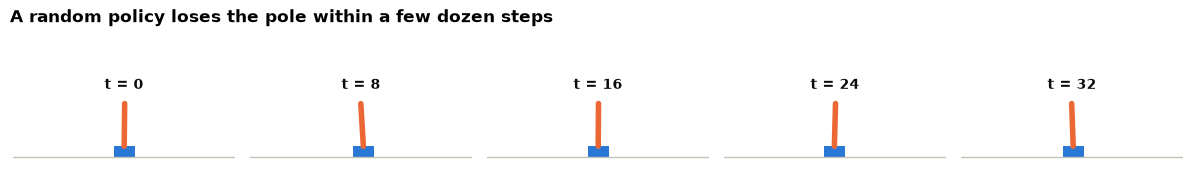

In [44]:
class CartPole:
    '''NumPy port of the classic CartPole-v1 dynamics (Euler integration, dt = 0.02).'''
    def __init__(self, max_steps=500):
        self.g, self.mc, self.mp, self.l, self.force, self.tau = 9.8, 1.0, 0.1, 0.5, 10.0, 0.02
        self.theta_thr, self.x_thr, self.max_steps = 12 * 2 * math.pi / 360, 2.4, max_steps
        self.obs_dim, self.n_actions = 4, 2

    def reset(self):
        self.state = np.random.uniform(-0.05, 0.05, size=4); self.t = 0
        return self.state.astype(np.float32)

    def step(self, a):
        x, xd, th, thd = self.state
        f = self.force if a == 1 else -self.force
        cos, sin = math.cos(th), math.sin(th)
        total = self.mc + self.mp
        temp = (f + self.mp * self.l * thd ** 2 * sin) / total
        thacc = (self.g * sin - cos * temp) / (self.l * (4.0 / 3.0 - self.mp * cos ** 2 / total))
        xacc = temp - self.mp * self.l * thacc * cos / total
        x, xd, th, thd = x + self.tau * xd, xd + self.tau * xacc, th + self.tau * thd, thd + self.tau * thacc
        self.state = np.array([x, xd, th, thd]); self.t += 1
        terminated = bool(abs(x) > self.x_thr or abs(th) > self.theta_thr)   # a real end: pole fell
        truncated = bool(self.t >= self.max_steps and not terminated)        # time limit: NOT a real end
        return self.state.astype(np.float32), 1.0, terminated, truncated

def render_cartpole(state, ax, t=None):
    x, _, th, _ = state
    ax.set_xlim(-2.6, 2.6); ax.set_ylim(-0.4, 1.4); ax.set_aspect("equal"); ax.grid(False)
    ax.axhline(0, color=AXIS, lw=1)
    ax.add_patch(Rectangle((x - 0.25, 0), 0.5, 0.25, fc=PALETTE[0], ec="none"))
    ax.plot([x, x + 1.0 * math.sin(th)], [0.25, 0.25 + 1.0 * math.cos(th)], color=PALETTE[1], lw=4, solid_capstyle="round")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    if t is not None: ax.set_title(f"t = {t}", fontsize=10, loc="center")

seed_everything(0)
cp = CartPole(); obs = cp.reset(); frames = [(0, obs)]
for t in range(1, 40):
    obs, r, term, trunc = cp.step(np.random.randint(2))
    if t % 8 == 0: frames.append((t, obs))
    if term: frames.append((t, obs)); break
fig, axes = plt.subplots(1, len(frames), figsize=(2.4 * len(frames), 2.3))
for ax, (t, s) in zip(axes, frames): render_cartpole(s, ax, t)
fig.suptitle("A random policy loses the pole within a few dozen steps", x=0.01, ha="left", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## Building DQN step by step

Three components: a Q-network, a replay buffer, and the update rule. The loss for a minibatch of
transitions $(s, a, r, s', d)$ ($d = 1$ if $s'$ is terminal) is

$$\mathcal L(\theta) = \mathbb E\Big[\, \ell_{\text{Huber}}\big(Q(s,a;\theta),\; r + \gamma (1-d) \max_{a'} Q(s',a';\theta^-)\big)\Big].$$

The Huber loss behaves like MSE near zero and like an absolute loss for large errors, which keeps
occasional wild targets from dominating the gradient.

A subtle but important detail: **time-limit truncation is not termination.** When CartPole stops at
step 500 the pole is still up, so the correct target still bootstraps from $Q(s', \cdot)$. Only a
genuinely terminal transition (pole fell) gets $d = 1$.

In [45]:
class QNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, n_actions))
    def forward(self, obs):
        return self.net(obs)

class ReplayBuffer:
    '''A ring buffer of transitions stored as NumPy arrays; sample() returns torch tensors.'''
    def __init__(self, capacity, obs_dim):
        self.obs = np.zeros((capacity, obs_dim), np.float32); self.next_obs = np.zeros((capacity, obs_dim), np.float32)
        self.act = np.zeros(capacity, np.int64); self.rew = np.zeros(capacity, np.float32); self.done = np.zeros(capacity, np.float32)
        self.capacity, self.ptr, self.size = capacity, 0, 0
    def add(self, o, a, r, o2, d):
        i = self.ptr
        self.obs[i], self.act[i], self.rew[i], self.next_obs[i], self.done[i] = o, a, r, o2, d
        self.ptr = (self.ptr + 1) % self.capacity; self.size = min(self.size + 1, self.capacity)
    def sample(self, n):
        idx = np.random.randint(0, self.size, size=n)
        return (torch.as_tensor(self.obs[idx]), torch.as_tensor(self.act[idx]), torch.as_tensor(self.rew[idx]),
                torch.as_tensor(self.next_obs[idx]), torch.as_tensor(self.done[idx]))

def dqn_update(q, q_target, opt, batch, gamma, double=False):
    obs, act, rew, next_obs, done = batch
    q_sa = q(obs).gather(1, act[:, None]).squeeze(1)                    # Q(s, a) for the actions taken
    with torch.no_grad():
        if double:   # Double DQN: select with the online net, evaluate with the target net
            best = q(next_obs).argmax(1, keepdim=True)
            q_next = q_target(next_obs).gather(1, best).squeeze(1)
        else:        # DQN: max over the target net
            q_next = q_target(next_obs).max(1).values
        target = rew + gamma * (1.0 - done) * q_next
    loss = F.smooth_l1_loss(q_sa, target)
    opt.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(q.parameters(), 10.0)
    opt.step()
    return loss.item()

def evaluate_policy(env, act_fn, n_episodes=5):
    '''Average undiscounted return of a deterministic act_fn(obs) -> action.'''
    rets = []
    for _ in range(n_episodes):
        obs, total = env.reset(), 0.0
        while True:
            obs, r, term, trunc = env.step(act_fn(obs)); total += r
            if term or trunc: break
        rets.append(total)
    return float(np.mean(rets))

In [46]:
def train_dqn(seed=0, total_steps=40_000, gamma=0.99, lr=1e-3, batch_size=128, buffer_size=50_000,
              learning_starts=1_000, train_every=4, tau=0.005, eps_start=1.0, eps_end=0.05, eps_decay_steps=10_000,
              double=False, eval_every=2_000, verbose=True):
    '''tau: Polyak (soft) target update rate, theta_target <- (1-tau) theta_target + tau theta, every step.'''
    seed_everything(seed)
    env, eval_env = CartPole(), CartPole()
    q = QNet(env.obs_dim, env.n_actions); q_target = copy.deepcopy(q)
    opt = torch.optim.Adam(q.parameters(), lr=lr)
    buf = ReplayBuffer(buffer_size, env.obs_dim)
    log = dict(ep_end_step=[], ep_return=[], loss=[], eval_step=[], eval_return=[], eps=[])
    greedy = lambda o: int(q(torch.as_tensor(o)).argmax())

    obs, ep_ret = env.reset(), 0.0
    for step in range(1, total_steps + 1):
        eps = max(eps_end, eps_start - (eps_start - eps_end) * step / eps_decay_steps)
        with torch.no_grad():
            a = np.random.randint(env.n_actions) if np.random.rand() < eps else greedy(obs)
        next_obs, r, term, trunc = env.step(a); ep_ret += r
        buf.add(obs, a, r, next_obs, float(term))            # bootstrap through truncation, not termination
        obs = next_obs
        if term or trunc:
            log["ep_end_step"].append(step); log["ep_return"].append(ep_ret); log["eps"].append(eps)
            obs, ep_ret = env.reset(), 0.0
        if step >= learning_starts and step % train_every == 0:
            log["loss"].append(dqn_update(q, q_target, opt, buf.sample(batch_size), gamma, double))
        with torch.no_grad():                                  # soft target update
            for p, p_t in zip(q.parameters(), q_target.parameters()):
                p_t.mul_(1 - tau).add_(tau * p)
        if step % eval_every == 0:
            with torch.no_grad():
                ev = evaluate_policy(eval_env, greedy)
            log["eval_step"].append(step); log["eval_return"].append(ev)
            if verbose and step % (eval_every * 5) == 0:
                print(f"step {step:6d} | eps {eps:.2f} | last-10 train return {np.mean(log['ep_return'][-10:]):6.1f} | eval {ev:6.1f}")
    return q, log

In [47]:
with Timer("DQN (3 seeds)"):
    dqn_runs = [train_dqn(seed=s, verbose=(s == 0)) for s in range(3)]
q_dqn, dqn_log = max(dqn_runs, key=lambda r: r[1]["eval_return"][-1])      # keep the best final model for the Q-value plot

step  10000 | eps 0.05 | last-10 train return  241.6 | eval  203.4


step  20000 | eps 0.05 | last-10 train return  201.1 | eval  173.2


step  30000 | eps 0.05 | last-10 train return  225.6 | eval  223.4


step  40000 | eps 0.05 | last-10 train return  188.4 | eval  225.2


[DQN (3 seeds)] 81.0s


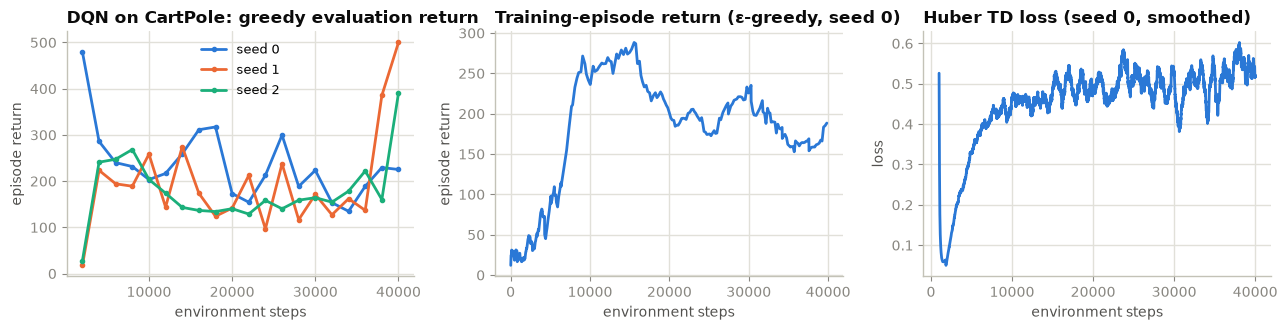

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
ax = axes[0]
for s, (_, lg) in enumerate(dqn_runs):
    ax.plot(lg["eval_step"], lg["eval_return"], marker="o", ms=3, label=f"seed {s}")
finish(ax, "DQN on CartPole: greedy evaluation return", "environment steps", "episode return")
ax = axes[1]
_, lg0 = dqn_runs[0]
ax.plot(lg0["ep_end_step"], smooth(lg0["ep_return"], 10), label="training episodes (ε-greedy), seed 0")
finish(ax, "Training-episode return (ε-greedy, seed 0)", "environment steps", "episode return", legend=False)
ax = axes[2]
ax.plot(np.arange(len(lg0["loss"])) * 4 + 1_000, smooth(lg0["loss"], 200))
finish(ax, "Huber TD loss (seed 0, smoothed)", "environment steps", "loss")
plt.tight_layout(); plt.show()

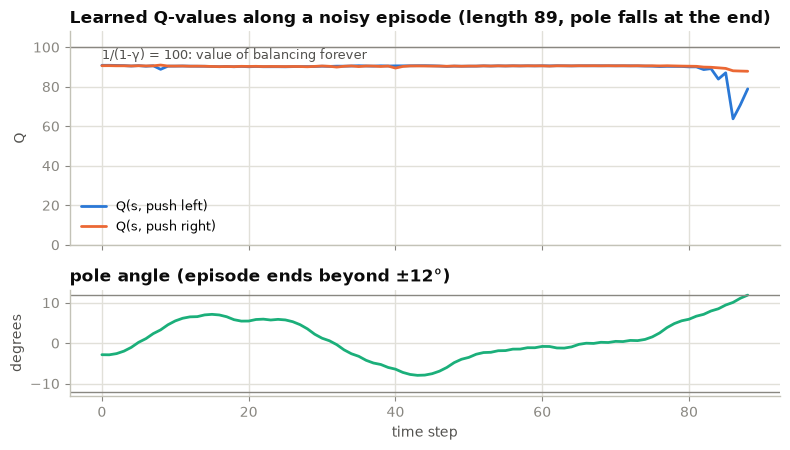

While the pole is balanced both Q-values sit near the ceiling; as the angle drifts toward the limit the values fall,
and the gap between them says which push the network thinks will rescue the pole.


In [49]:
# What does the learned Q-function believe? Trace Q(s, left), Q(s, right) along an episode where the agent
# acts greedily 70% of the time and randomly otherwise, so that the pole eventually falls.
seed_everything(1)
env = CartPole(); obs = env.reset(); qs, angles = [], []
with torch.no_grad():
    while True:
        qv = q_dqn(torch.as_tensor(obs)); qs.append(qv.numpy()); angles.append(obs[2])
        a = int(qv.argmax()) if np.random.rand() < 0.7 else np.random.randint(2)
        obs, r, term, trunc = env.step(a)
        if term or trunc: break
qs = np.array(qs)
fig, axes = plt.subplots(2, 1, figsize=(8, 4.6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(qs[:, 0], label="Q(s, push left)"); axes[0].plot(qs[:, 1], label="Q(s, push right)")
axes[0].axhline(1 / (1 - 0.99), color=MUTED, lw=1); axes[0].text(0, 1 / (1 - 0.99) - 6, "1/(1-γ) = 100: value of balancing forever", color=INK2, fontsize=9)
axes[0].set_ylim(0, 108); finish(axes[0], f"Learned Q-values along a noisy episode (length {len(qs)}, pole falls at the end)", None, "Q")
axes[1].plot(np.degrees(angles), color=PALETTE[2]); axes[1].axhline(12, color=MUTED, lw=1); axes[1].axhline(-12, color=MUTED, lw=1)
finish(axes[1], "pole angle (episode ends beyond ±12°)", "time step", "degrees", legend=False)
plt.tight_layout(); plt.show()
print("While the pole is balanced both Q-values sit near the ceiling; as the angle drifts toward the limit the values fall,")
print("and the gap between them says which push the network thinks will rescue the pole.")

**What to notice.** Q-values sit near the discounted-return ceiling $1/(1-\gamma) = 100$ while the pole is
safe and drop as failure approaches. Look at the three seeds in the evaluation plot: DQN on CartPole is
notoriously **seed-sensitive**. Curves climb, collapse and recover, because a greedy policy flips
abruptly whenever two Q-values cross, and every flip changes the data distribution in the buffer.
Soft (Polyak) target updates, larger batches, Double DQN and more steps all make it steadier; none make it
monotone. Reporting several seeds is not optional in RL.

**The deadly triad in one sentence.** Bootstrapping (targets depend on our own estimates) +
off-policy data (replay contains actions the current policy would not take) + function approximation
(an update to one state changes others) can create a feedback loop where estimates grow without
bound. DQN's tricks don't eliminate the triad; they slow the loop enough for learning to win.

### Test your knowledge

In [50]:
register_quiz('5.1',
    'What is the purpose of the target network in DQN?',
    ['To reduce the number of parameters', 'To keep the regression target fixed for a while so the update does not chase a moving target', 'To make the algorithm on-policy', 'To act in the environment while the online network trains'],
    '23167f74a03e8f53196094638cbb2197b7247afd95047c6219c1dc499089ae1a',
    'V2l0aG91dCBpdCB0aGUgdGFyZ2V0IHIgKyBnYW1tYSBtYXggUShzJykgY2hhbmdlcyBhZnRlciBldmVyeSBncmFkaWVudCBzdGVwLCBiZWNhdXNlIGl0IGlzIGNvbXB1dGVkIHdpdGggdGhlIHNhbWUgd2VpZ2h0cyBiZWluZyB1cGRhdGVkLiBGcmVlemluZyBhIGNvcHkgdHVybnMgZWFjaCBpbnRlcnZhbCBpbnRvIGFuIG9yZGluYXJ5IHN1cGVydmlzZWQgcmVncmVzc2lvbi4=')
quiz('5.1')

QUIZ 5.1: What is the purpose of the target network in DQN?

   A)  To reduce the number of parameters
   B)  To keep the regression target fixed for a while so the update does not chase a moving target
   C)  To make the algorithm on-policy
   D)  To act in the environment while the online network trains

-> put your choice in the answer('5.1', ...) cell below and run it.


In [51]:
answer('5.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [52]:
register_quiz('5.2',
    'Why is experience replay legal for Q-learning but NOT for the policy-gradient methods coming up in Part 6?',
    ['It is legal for both; DQN just happens to use it', "Policy gradients don't use neural networks", 'Q-learning is off-policy: its target does not depend on which policy generated the transition', 'Replay buffers only store discrete actions'],
    '53aee67d7c15ad23616400cde5619d1cc199f6874f171cc3874b6bf1fcdcd866',
    'US1sZWFybmluZydzIHRhcmdldCB1c2VzIG1heCBvdmVyIGEnLCBzbyBvbGQgdHJhbnNpdGlvbnMgZnJvbSBhbnkgYmVoYXZpb3VyIHBvbGljeSBhcmUgdmFsaWQgc2FtcGxlcy4gVGhlIHZhbmlsbGEgcG9saWN5IGdyYWRpZW50IGlzIGFuIGV4cGVjdGF0aW9uIHVuZGVyIHRoZSAqY3VycmVudCogcG9saWN5LCBzbyBzdGFsZSBzYW1wbGVzIGJpYXMgaXQsIHdoaWNoIGlzIHdoeSBQUE8gbmVlZHMgaW1wb3J0YW5jZSByYXRpb3MgdG8gcmV1c2UgZGF0YSBldmVuIGEgZmV3IGVwb2NocyBvbGQu')
quiz('5.2')

QUIZ 5.2: Why is experience replay legal for Q-learning but NOT for the policy-gradient methods coming up in Part 6?

   A)  It is legal for both; DQN just happens to use it
   B)  Policy gradients don't use neural networks
   C)  Q-learning is off-policy: its target does not depend on which policy generated the transition
   D)  Replay buffers only store discrete actions

-> put your choice in the answer('5.2', ...) cell below and run it.


In [53]:
answer('5.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [54]:
register_quiz('5.3',
    'CartPole ends after 500 steps by a time limit. If we stored done=1 for that transition, what would go wrong?',
    ['The network would learn that the state at step 500 is worth zero future reward, even though the pole is still balanced, biasing Q-values near the time limit', 'The replay buffer would overflow', 'Nothing; 500 steps is the maximum anyway', 'Epsilon would stop decaying'],
    '9ce883a892bc74b59c98bd56f920d8f6edff96a9c2b411631e60080d1e0581c2',
    'VHJ1bmNhdGlvbiBpcyBhIHByb3BlcnR5IG9mIHRoZSBleHBlcmltZW50LCBub3QgdGhlIGVudmlyb25tZW50LiBUaGUgb2JzZXJ2YXRpb24gYXQgc3RlcCA1MDAgbG9va3MgbGlrZSBhbnkgb3RoZXIgYmFsYW5jZWQgc3RhdGUsIHNvIGxhYmVsbGluZyBpdCB0ZXJtaW5hbCB0ZWFjaGVzIGEgY29udHJhZGljdGlvbi4gQm9vdHN0cmFwcGluZyB0aHJvdWdoIHRydW5jYXRpb24gKGRvbmU9MCkgaXMgY29ycmVjdDsgYSBjb21tb24gYnVnIGluIHR1dG9yaWFscy4=')
quiz('5.3')

QUIZ 5.3: CartPole ends after 500 steps by a time limit. If we stored done=1 for that transition, what would go wrong?

   A)  The network would learn that the state at step 500 is worth zero future reward, even though the pole is still balanced, biasing Q-values near the time limit
   B)  The replay buffer would overflow
   C)  Nothing; 500 steps is the maximum anyway
   D)  Epsilon would stop decaying

-> put your choice in the answer('5.3', ...) cell below and run it.


In [55]:
answer('5.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 5.4 · The Double DQN target

Implement `double_dqn_target(q, q_target, rew, next_obs, done, gamma)` returning the tensor of targets

$$y = r + \gamma (1-d)\, Q_{\text{target}}\big(s', \arg\max_{a'} Q_{\text{online}}(s', a')\big).$$

`q` and `q_target` are callables mapping a batch of observations to a `(batch, n_actions)` tensor.

In [56]:
def double_dqn_target(q, q_target, rew, next_obs, done, gamma):
    with torch.no_grad():
        # YOUR CODE HERE
        raise NotImplementedError

In [57]:
register_exercise('5.4', 'ZGVmIGRvdWJsZV9kcW5fdGFyZ2V0KHEsIHFfdGFyZ2V0LCByZXcsIG5leHRfb2JzLCBkb25lLCBnYW1tYSk6CiAgICB3aXRoIHRvcmNoLm5vX2dyYWQoKToKICAgICAgICBiZXN0ID0gcShuZXh0X29icykuYXJnbWF4KDEsIGtlZXBkaW09VHJ1ZSkgICAgICAgICAgICAgICAgICMgc2VsZWN0aW9uOiBvbmxpbmUgbmV0CiAgICAgICAgcV9uZXh0ID0gcV90YXJnZXQobmV4dF9vYnMpLmdhdGhlcigxLCBiZXN0KS5zcXVlZXplKDEpICAgICAgIyBldmFsdWF0aW9uOiB0YXJnZXQgbmV0CiAgICAgICAgcmV0dXJuIHJldyArIGdhbW1hICogKDEuMCAtIGRvbmUpICogcV9uZXh0')

def _tests(fn):
    q = lambda o: torch.tensor([[1.0, 2.0], [3.0, 0.0]])
    qt = lambda o: torch.tensor([[10.0, 20.0], [30.0, 40.0]])
    y = fn(q, qt, torch.tensor([1.0, 1.0]), torch.zeros(2, 4), torch.tensor([0.0, 0.0]), 0.5)
    assert y is not None and tuple(y.shape) == (2,), "return a 1-D tensor of shape (batch,)"
    assert torch.allclose(y, torch.tensor([11.0, 16.0])), f"expected [11, 16], got {y.tolist()} (are you selecting with the ONLINE net?)"
    y2 = fn(q, qt, torch.tensor([1.0, 1.0]), torch.zeros(2, 4), torch.tensor([0.0, 1.0]), 0.5)
    assert torch.allclose(y2, torch.tensor([11.0, 1.0])), "terminal transitions must not bootstrap"

check('5.4', double_dqn_target, _tests)
# solution('5.4')   # <- uncomment to reveal the reference solution

[5.4] not implemented yet. Fill in the cell above (or run solution('5.4')).


---
# Part 6 · Policy gradients: REINFORCE

Value-based methods learn $Q$ and act greedily. **Policy gradient** methods skip the detour and
optimise the policy $\pi_\theta(a|s)$ directly by gradient ascent on the expected return
$J(\theta) = \mathbb E_{\tau \sim \pi_\theta}[R(\tau)]$. This handles continuous actions, stochastic
optimal policies, and, crucially for Parts 10–17, policies that are *language models*.

## The policy gradient theorem

Write $p_\theta(\tau) = p(s_0) \prod_t \pi_\theta(a_t|s_t)\, p(s_{t+1}|s_t, a_t)$. Then, using the
**log-derivative trick** $\nabla p = p \nabla \log p$,

$$\nabla_\theta J = \int \nabla_\theta p_\theta(\tau) R(\tau)\, d\tau
= \mathbb E_{\tau}\big[ R(\tau)\, \nabla_\theta \log p_\theta(\tau) \big]
= \mathbb E_{\tau}\Big[ R(\tau) \sum_t \nabla_\theta \log \pi_\theta(a_t|s_t) \Big].$$

The dynamics $p(s'|s,a)$ vanished because they don't depend on $\theta$. **We never need to know
the environment model.** The estimator says: *push up the log-probability of every action taken in
proportion to how good the whole trajectory turned out.*

Two refinements that don't change the expectation but slash the variance:

* **Reward-to-go / causality.** The action at time $t$ cannot affect rewards before $t$, so
  replace $R(\tau)$ by $G_t = \sum_{t' \ge t} \gamma^{t'-t} r_{t'}$.
* **Baselines** (next Part): subtract any function $b(s_t)$ from $G_t$.

The resulting algorithm is **REINFORCE** (Williams, 1992): sample episodes, compute returns, take a
gradient step on $-\frac{1}{N}\sum_t G_t \log \pi_\theta(a_t|s_t)$.

In [58]:
class Policy(nn.Module):
    '''Categorical policy: MLP -> action logits.'''
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(),
                                 nn.Linear(hidden, n_actions))
    def dist(self, obs):
        return torch.distributions.Categorical(logits=self.net(obs))
    @torch.no_grad()
    def act(self, obs):
        probs = torch.softmax(self.net(torch.as_tensor(obs)), -1).numpy()
        return int(np.random.choice(len(probs), p=probs))

class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    def forward(self, obs):
        return self.net(obs).squeeze(-1)

@dataclass
class Rollout:
    obs: torch.Tensor; act: torch.Tensor; next_obs: torch.Tensor
    rew: np.ndarray; term: np.ndarray; done: np.ndarray   # term: true terminal; done: term OR truncated
    ep_returns: list

def collect_rollout(env, policy, n_steps, complete_episodes=False):
    '''Run the policy for >= n_steps. If complete_episodes, keep going until the current episode ends.'''
    O, A, O2, R, T, D, ep_returns = [], [], [], [], [], [], []
    obs, ep_ret, t = env.reset(), 0.0, 0
    while True:
        a = policy.act(obs)
        next_obs, r, term, trunc = env.step(a)
        O.append(obs); A.append(a); O2.append(next_obs); R.append(r); T.append(term); D.append(term or trunc)
        obs, ep_ret, t = next_obs, ep_ret + r, t + 1
        if term or trunc:
            ep_returns.append(ep_ret); ep_ret, obs = 0.0, env.reset()
            if t >= n_steps: break
        elif t >= n_steps and not complete_episodes:
            break
    return Rollout(torch.as_tensor(np.array(O)), torch.as_tensor(np.array(A)), torch.as_tensor(np.array(O2)),
                   np.array(R, np.float32), np.array(T, np.float32), np.array(D, np.float32), ep_returns)

def rewards_to_go(rew, done, gamma):
    '''G_t = r_t + gamma * G_{t+1}, restarting at episode boundaries (done[t] = 1 means t was the last step).'''
    G, running = np.zeros(len(rew), np.float32), 0.0
    for t in reversed(range(len(rew))):
        running = rew[t] + gamma * running * (1.0 - done[t])
        G[t] = running
    return G

def episode_return_per_step(rew, done, gamma):
    '''The naive estimator: every step of an episode gets that episode's full discounted return.'''
    out, start = np.zeros(len(rew), np.float32), 0
    for t in range(len(rew)):
        if done[t] or t == len(rew) - 1:
            disc = gamma ** np.arange(t - start + 1)
            out[start:t + 1] = (rew[start:t + 1] * disc).sum(); start = t + 1
    return out

# quick sanity check of the return computation
_r = np.array([1, 1, 1, 1], np.float32); _d = np.array([0, 1, 0, 1], np.float32)
print("reward-to-go (γ=0.5):", rewards_to_go(_r, _d, 0.5), "  episode return per step:", episode_return_per_step(_r, _d, 0.5))

reward-to-go (γ=0.5): [1.5 1.  1.5 1. ]   episode return per step: [1.5 1.5 1.5 1.5]


In [59]:
def reinforce_update(policy, opt, ro, gamma, mode="rtg"):
    G = rewards_to_go(ro.rew, ro.done, gamma) if mode == "rtg" else episode_return_per_step(ro.rew, ro.done, gamma)
    G = torch.as_tensor(G)
    logp = policy.dist(ro.obs).log_prob(ro.act)
    loss = -(logp * G).mean()                    # gradient ascent on E[G log pi]
    opt.zero_grad(); loss.backward(); opt.step()
    return loss.item()

def train_reinforce(seed=0, mode="rtg", iters=60, batch_steps=1024, lr=3e-3, gamma=0.99, snapshot_at=None):
    seed_everything(seed)
    env = CartPole(); policy = Policy(env.obs_dim, env.n_actions)
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    curve, steps, snapshot, total = [], [], None, 0
    for it in range(iters):
        ro = collect_rollout(env, policy, batch_steps, complete_episodes=True)
        reinforce_update(policy, opt, ro, gamma, mode)
        total += len(ro.rew); curve.append(np.mean(ro.ep_returns)); steps.append(total)
        if snapshot_at is not None and it == snapshot_at: snapshot = copy.deepcopy(policy)
    return policy, np.array(curve), np.array(steps), snapshot

In [60]:
# Shared experiment settings for all CartPole policy-gradient runs (lower N_SEEDS to 1 for a faster notebook)
N_SEEDS = 3
TOTAL_STEPS = 60 * 1024          # same environment budget for every algorithm
pg_results = {}                  # name -> (list of return curves, list of step curves)

with Timer("REINFORCE"):
    for mode, name in [("total", "REINFORCE (total return)"), ("rtg", "REINFORCE (reward-to-go)")]:
        curves, steps = [], []
        for seed in range(N_SEEDS):
            pol, c, s, snap = train_reinforce(seed, mode, iters=TOTAL_STEPS // 1024, snapshot_at=15)
            curves.append(c); steps.append(s)
            if mode == "rtg" and seed == 0: policy_snapshot = snap      # kept for the variance experiment
        pg_results[name] = (curves, steps)
        print(f"{name:30s} final return (mean over seeds): {np.mean([c[-1] for c in curves]):6.1f}")

REINFORCE (total return)       final return (mean over seeds):  104.2


REINFORCE (reward-to-go)       final return (mean over seeds):  387.5
[REINFORCE] 46.0s


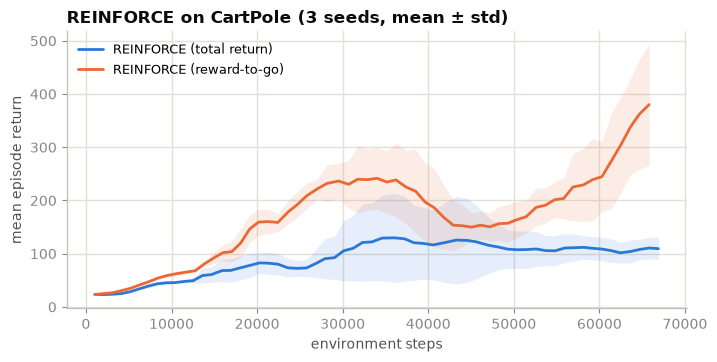

In [61]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for name, (curves, steps) in pg_results.items():
    plot_runs(ax, curves, label=name, k=3, x=steps[0])
finish(ax, f"REINFORCE on CartPole ({N_SEEDS} seeds, mean ± std)", "environment steps", "mean episode return")
plt.show()

## Measuring the variance of the gradient estimate

Let's make the "variance" talk concrete. Freeze a partially trained policy, draw many independent
batches of the same size, compute the gradient estimate for each, and look at how much the estimates
disagree with each other. We compare the naive total-return estimator, reward-to-go, and reward-to-go
minus a constant baseline (the batch mean return).

In [62]:
def flat_grad(y, model, **kw):
    grads = torch.autograd.grad(y, list(model.parameters()), **kw)
    return torch.cat([g.reshape(-1) for g in grads])

def gradient_variance(policy, estimator, n_batches=30, batch_steps=500):
    env, grads = CartPole(), []
    for _ in range(n_batches):
        ro = collect_rollout(env, policy, batch_steps, complete_episodes=True)
        G = torch.as_tensor(estimator(ro))
        logp = policy.dist(ro.obs).log_prob(ro.act)
        grads.append(flat_grad(-(logp * G).mean(), policy))
    grads = torch.stack(grads)
    return grads.var(0).sum().item(), grads.mean(0)

[gradient variance] 6.2s


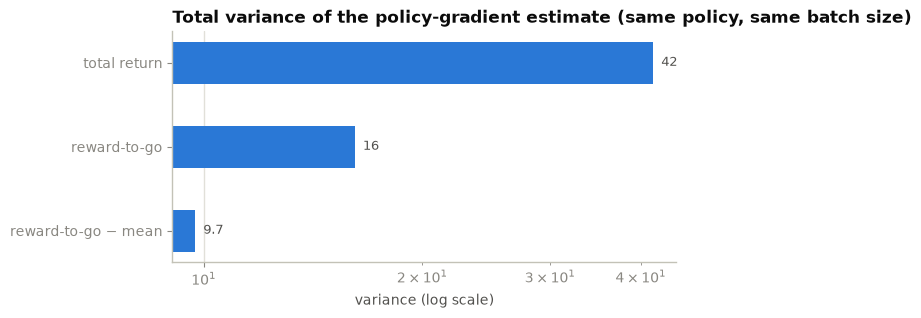

In [63]:
seed_everything(0)
estimators = {
    "total return":            lambda ro: episode_return_per_step(ro.rew, ro.done, 0.99),
    "reward-to-go":            lambda ro: rewards_to_go(ro.rew, ro.done, 0.99),
    "reward-to-go − mean":     lambda ro: (lambda G: G - G.mean())(rewards_to_go(ro.rew, ro.done, 0.99)),
}
with Timer("gradient variance"):
    var = {name: gradient_variance(policy_snapshot, est)[0] for name, est in estimators.items()}

fig, ax = plt.subplots(figsize=(6.5, 3))
names = list(var); vals = [var[n] for n in names]
bars = ax.barh(names, vals, color=PALETTE[0], height=0.5)
for b, v in zip(bars, vals):
    ax.text(v, b.get_y() + b.get_height() / 2, f"  {v:.2g}", va="center", fontsize=9, color=INK2)
ax.set_xscale("log"); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
finish(ax, "Total variance of the policy-gradient estimate (same policy, same batch size)", "variance (log scale)", legend=False)
plt.show()

Each refinement removes a large chunk of variance **without changing what the gradient points at**.
That is the whole game in policy-gradient research: keep the estimator unbiased (or nearly so) and
make it as low-variance as possible so that fewer samples give a usable direction. GAE (Part 7), TRPO's
trust region (Part 8), PPO's clipping (Part 9) and GRPO's group baseline (Part 15) are all moves in
this game.

### Test your knowledge

In [64]:
register_quiz('6.1',
    "Why does the environment's transition model p(s'|s,a) disappear from the policy gradient?",
    ["Because log p(tau) is a sum, and the dynamics terms don't depend on theta so their gradient is zero", 'Because the baseline cancels it', 'Because we use the reward-to-go trick', 'Because we assume deterministic dynamics'],
    '843899a9535a5738ab8df89d3979085c829b6ac6fb3af29007ca02e96c5e68c1',
    'bG9nIHBfdGhldGEodGF1KSA9IGxvZyBwKHMwKSArIHN1bV90IFtsb2cgcGlfdGhldGEoYV90fHNfdCkgKyBsb2cgcChzX3t0KzF9fHNfdCxhX3QpXS4gRGlmZmVyZW50aWF0aW5nIHdpdGggcmVzcGVjdCB0byB0aGV0YSBraWxscyBldmVyeXRoaW5nIGV4Y2VwdCB0aGUgcG9saWN5IHRlcm1zLiBUaGlzIGlzIHdoeSBwb2xpY3kgZ3JhZGllbnRzIGFyZSBtb2RlbC1mcmVlLg==')
quiz('6.1')

QUIZ 6.1: Why does the environment's transition model p(s'|s,a) disappear from the policy gradient?

   A)  Because log p(tau) is a sum, and the dynamics terms don't depend on theta so their gradient is zero
   B)  Because the baseline cancels it
   C)  Because we use the reward-to-go trick
   D)  Because we assume deterministic dynamics

-> put your choice in the answer('6.1', ...) cell below and run it.


In [65]:
answer('6.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [66]:
register_quiz('6.2',
    'Replacing R(tau) with the reward-to-go G_t is allowed because:',
    ['It makes the gradient larger', 'Past rewards are always zero', 'For any t, E[ nabla log pi(a_t|s_t) * (rewards before t) ] = 0: an action cannot influence rewards that came before it', 'Returns are always positive in CartPole'],
    'fb83366f1fa773da94be31612f8703a53e963e2ae04465440a7ecbd0db503984',
    'Q29uZGl0aW9uZWQgb24gc190LCB0aGUgZWFybGllciByZXdhcmRzIGFyZSBmaXhlZCBjb25zdGFudHMsIGFuZCBFX2FbbmFibGEgbG9nIHBpKGF8cyldID0gbmFibGEgc3VtX2EgcGkoYXxzKSA9IG5hYmxhIDEgPSAwLiBTbyB0aGUgcmVtb3ZlZCB0ZXJtcyBoYWQgemVybyBtZWFuOyBkcm9wcGluZyB0aGVtIGtlZXBzIHRoZSBlc3RpbWF0b3IgdW5iaWFzZWQgYW5kIHJlbW92ZXMgbm9pc2Uu')
quiz('6.2')

QUIZ 6.2: Replacing R(tau) with the reward-to-go G_t is allowed because:

   A)  It makes the gradient larger
   B)  Past rewards are always zero
   C)  For any t, E[ nabla log pi(a_t|s_t) * (rewards before t) ] = 0: an action cannot influence rewards that came before it
   D)  Returns are always positive in CartPole

-> put your choice in the answer('6.2', ...) cell below and run it.


In [67]:
answer('6.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [68]:
register_quiz('6.3',
    'REINFORCE is on-policy. What does that imply for sample efficiency?',
    ['It needs a model of the environment', 'It converges in one update', 'It can reuse a replay buffer like DQN', 'Every batch of data can be used only for the policy that generated it, then must be thrown away'],
    '8c904f08c284e1fae4e1baf688293d708fc4e64263aecaae95cb1c60e1d3020e',
    'VGhlIGdyYWRpZW50IGlzIGFuIGV4cGVjdGF0aW9uIHVuZGVyIHRoZSBjdXJyZW50IHBvbGljeS4gQWZ0ZXIgb25lIHVwZGF0ZSB0aGUgc2FtcGxlcyBjb21lIGZyb20gYW4gb2xkIHBvbGljeSBhbmQgdGhlIGVzdGltYXRlIGlzIGJpYXNlZC4gVFJQTyBhbmQgUFBPIGZpeCB0aGlzIHBhcnRpYWxseSBieSBpbXBvcnRhbmNlLXdlaWdodGluZyB0aGUgc2FtcGxlcyBmb3IgYSBmZXcgZXBvY2hzIHdoaWxlIGtlZXBpbmcgdGhlIHBvbGljeSBjbG9zZSB0byB0aGUgb2xkIG9uZS4=')
quiz('6.3')

QUIZ 6.3: REINFORCE is on-policy. What does that imply for sample efficiency?

   A)  It needs a model of the environment
   B)  It converges in one update
   C)  It can reuse a replay buffer like DQN
   D)  Every batch of data can be used only for the policy that generated it, then must be thrown away

-> put your choice in the answer('6.3', ...) cell below and run it.


In [69]:
answer('6.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 6.4 · Discounted reward-to-go with episode boundaries

Write `my_rewards_to_go(rew, done, gamma)` from scratch (don't call the notebook's version). `rew` and
`done` are 1-D arrays; `done[t] = 1` means step `t` was the **last** step of its episode. Return an array
`G` with $G_t = r_t + \gamma G_{t+1}$ inside an episode and $G_t = r_t$ at the last step.

In [70]:
def my_rewards_to_go(rew, done, gamma):
    # YOUR CODE HERE
    raise NotImplementedError

In [71]:
register_exercise('6.4', 'ZGVmIG15X3Jld2FyZHNfdG9fZ28ocmV3LCBkb25lLCBnYW1tYSk6CiAgICBHID0gbnAuemVyb3MobGVuKHJldykpOyBydW5uaW5nID0gMC4wCiAgICBmb3IgdCBpbiByZXZlcnNlZChyYW5nZShsZW4ocmV3KSkpOgogICAgICAgIHJ1bm5pbmcgPSByZXdbdF0gKyBnYW1tYSAqIHJ1bm5pbmcgKiAoMS4wIC0gZG9uZVt0XSkKICAgICAgICBHW3RdID0gcnVubmluZwogICAgcmV0dXJuIEc=')

def _tests(fn):
    rew = np.array([1.0, 2.0, 3.0, 4.0, 5.0]); done = np.array([0, 0, 1, 0, 1])
    G = fn(rew, done, 0.5)
    assert G is not None and len(G) == 5, "wrong length"
    assert np.allclose(G, [1 + 0.5 * (2 + 0.5 * 3), 2 + 0.5 * 3, 3.0, 4 + 0.5 * 5, 5.0]), f"got {G}"
    G2 = fn(np.ones(4), np.array([0, 0, 0, 1]), 1.0)
    assert np.allclose(G2, [4, 3, 2, 1]), f"undiscounted case failed: {G2}"

check('6.4', my_rewards_to_go, _tests)
# solution('6.4')   # <- uncomment to reveal the reference solution

[6.4] not implemented yet. Fill in the cell above (or run solution('6.4')).


---
# Part 7 · Actor-critic and generalised advantage estimation

## Baselines

Subtracting a **baseline** $b(s_t)$ from the return does not change the expected gradient:

$$\mathbb E_{a \sim \pi}\big[\nabla_\theta \log \pi_\theta(a|s)\, b(s)\big] = b(s)\, \nabla_\theta \sum_a \pi_\theta(a|s) = b(s)\, \nabla_\theta 1 = 0.$$

The best simple choice is the state value $b(s) = V^\pi(s)$, which turns the weight into the
**advantage** $A^\pi(s,a) = Q^\pi(s,a) - V^\pi(s)$: *how much better was this action than what the policy
usually gets from here?* Actions that are merely "in a good state" no longer get credit; only actions
that beat expectations do.

## Actor-critic

We don't know $V^\pi$, so we learn it: a second network, the **critic**, trained by regression on
returns (or TD targets), while the **actor** $\pi_\theta$ is trained with the advantage-weighted policy
gradient. This is *generalised policy iteration* with neural networks: the critic evaluates, the actor improves.

## Generalised advantage estimation (GAE)

How should we estimate $A_t$? Two extremes:

* Monte Carlo: $\hat A_t = G_t - V(s_t)$. Unbiased given $V$, but high variance.
* One-step TD: $\hat A_t = \delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$. Low variance, biased if $V$ is wrong.

GAE (Schulman et al., 2016) interpolates with a parameter $\lambda \in [0,1]$ exactly like TD(λ):

$$\hat A_t^{\text{GAE}(\gamma,\lambda)} = \sum_{l=0}^{\infty} (\gamma\lambda)^l\, \delta_{t+l}, \qquad
\text{computed backwards as } \hat A_t = \delta_t + \gamma\lambda\, \hat A_{t+1}.$$

$\lambda = 0$ gives the TD error, $\lambda = 1$ gives the Monte Carlo advantage. $\lambda \approx 0.95$
is the usual sweet spot. Almost every modern on-policy algorithm (A2C, TRPO, PPO, PPO-for-LLMs) uses it.

In [72]:
def compute_gae(rew, values, next_values, term, done, gamma, lam):
    '''Returns (advantages, value targets). term[t]=1: s_{t+1} is terminal (no bootstrap).
    done[t]=1: episode ended after t (terminal OR truncated), so the GAE recursion must restart.'''
    T, adv, last = len(rew), np.zeros(len(rew), np.float32), 0.0
    for t in reversed(range(T)):
        delta = rew[t] + gamma * (1.0 - term[t]) * next_values[t] - values[t]     # TD error
        last = delta + gamma * lam * (1.0 - done[t]) * last
        adv[t] = last
    return adv, adv + values          # value target = advantage + baseline = lambda-return

def a2c_update(policy, value, opt_pi, opt_v, ro, gamma=0.99, lam=0.95, ent_coef=0.0, value_steps=5):
    with torch.no_grad():
        v, v_next = value(ro.obs).numpy(), value(ro.next_obs).numpy()
    adv, ret = compute_gae(ro.rew, v, v_next, ro.term, ro.done, gamma, lam)
    adv, ret = torch.as_tensor(adv), torch.as_tensor(ret)
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)                       # advantage normalisation
    dist = policy.dist(ro.obs)
    pi_loss = -(dist.log_prob(ro.act) * adv).mean() - ent_coef * dist.entropy().mean()
    opt_pi.zero_grad(); pi_loss.backward(); opt_pi.step()
    for _ in range(value_steps):                                         # the critic can afford more steps
        v_loss = F.mse_loss(value(ro.obs), ret)
        opt_v.zero_grad(); v_loss.backward(); opt_v.step()
    return pi_loss.item(), v_loss.item()

def train_a2c(seed=0, iters=60, batch_steps=1024, lr=3e-3, lr_v=3e-3, gamma=0.99, lam=0.95):
    seed_everything(seed)
    env = CartPole(); policy, value = Policy(env.obs_dim, env.n_actions), ValueNet(env.obs_dim)
    opt_pi, opt_v = torch.optim.Adam(policy.parameters(), lr=lr), torch.optim.Adam(value.parameters(), lr=lr_v)
    curve, steps, total = [], [], 0
    for it in range(iters):
        ro = collect_rollout(env, policy, batch_steps, complete_episodes=True)
        a2c_update(policy, value, opt_pi, opt_v, ro, gamma, lam)
        total += len(ro.rew); curve.append(np.mean(ro.ep_returns)); steps.append(total)
    return policy, value, np.array(curve), np.array(steps)

A2C final return (mean over seeds):  388.1
[A2C] 27.1s


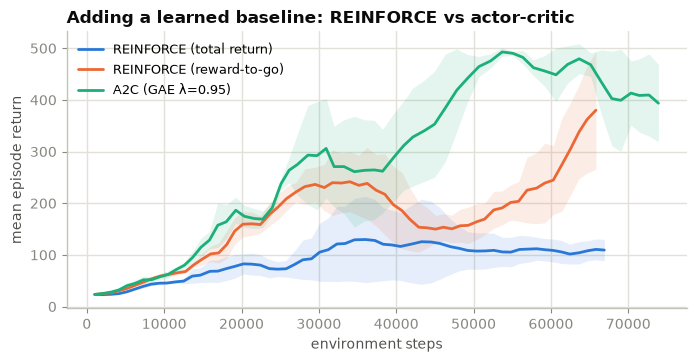

In [73]:
with Timer("A2C"):
    curves, steps = [], []
    for seed in range(N_SEEDS):
        pol_a2c, val_a2c, c, s = train_a2c(seed, iters=TOTAL_STEPS // 1024); curves.append(c); steps.append(s)
    pg_results["A2C (GAE λ=0.95)"] = (curves, steps)
    print(f"A2C final return (mean over seeds): {np.mean([c[-1] for c in curves]):6.1f}")

fig, ax = plt.subplots(figsize=(8, 3.6))
for name, (curves, steps) in pg_results.items():
    plot_runs(ax, curves, label=name, k=3, x=steps[0])
finish(ax, "Adding a learned baseline: REINFORCE vs actor-critic", "environment steps", "mean episode return")
plt.show()

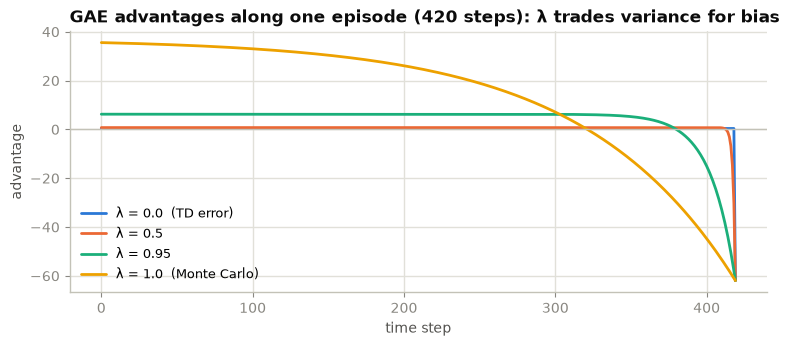

In [74]:
# What does lambda do? Advantages of one episode under the trained critic for several lambdas.
seed_everything(3)
ro = collect_rollout(CartPole(), pol_a2c, 400, complete_episodes=True)
end = int(np.where(ro.done)[0][0]) + 1                              # first complete episode
with torch.no_grad():
    v, v_next = val_a2c(ro.obs).numpy(), val_a2c(ro.next_obs).numpy()
fig, ax = plt.subplots(figsize=(9, 3.4))
for lam in [0.0, 0.5, 0.95, 1.0]:
    adv, _ = compute_gae(ro.rew, v, v_next, ro.term, ro.done, 0.99, lam)
    ax.plot(adv[:end], label=f"λ = {lam}" + ("  (TD error)" if lam == 0 else "  (Monte Carlo)" if lam == 1 else ""))
ax.axhline(0, color=AXIS, lw=1)
finish(ax, f"GAE advantages along one episode ({end} steps): λ trades variance for bias", "time step", "advantage")
plt.show()

With $\lambda = 1$ the advantage carries the *entire* remaining episode's randomness; at
$\lambda = 0$ it is a single TD error, small and smooth but only as accurate as the critic. Values in
between blend the two. The last few steps before termination are where all curves agree: the critic
sees the fall coming.

### Test your knowledge

In [75]:
register_quiz('7.1',
    'Which statement about a state-dependent baseline b(s) is true?',
    ['It makes the estimator biased but faster', 'It increases the variance but improves exploration', 'It reduces the variance of the gradient estimate and leaves its expectation unchanged', 'It only works if b(s) equals the true value function'],
    '21f367d674e1501ccb601ad6d2233ce8888c141d8db38f9255768ae654cd74a7',
    'RV9hW25hYmxhIGxvZyBwaShhfHMpIGIocyldID0gMCBmb3IgYW55IGIgdGhhdCBkb2VzIG5vdCBkZXBlbmQgb24gdGhlIGFjdGlvbi4gVGhlIGNsb3NlciBiIGlzIHRvIFZecGksIHRoZSBzbWFsbGVyIHRoZSB2YXJpYW5jZSwgYnV0IGFueSBiIGlzICdsZWdhbCcuIFRoaXMgaXMgd2h5IEdSUE8ncyBncm91cC1tZWFuIGJhc2VsaW5lIHdvcmtzIGV2ZW4gdGhvdWdoIGl0IGlzIGEgY3J1ZGUgZXN0aW1hdGUgb2YgVi4=')
quiz('7.1')

QUIZ 7.1: Which statement about a state-dependent baseline b(s) is true?

   A)  It makes the estimator biased but faster
   B)  It increases the variance but improves exploration
   C)  It reduces the variance of the gradient estimate and leaves its expectation unchanged
   D)  It only works if b(s) equals the true value function

-> put your choice in the answer('7.1', ...) cell below and run it.


In [76]:
answer('7.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [77]:
register_quiz('7.2',
    'GAE with lambda = 0 gives the advantage estimate:',
    ['r_t + gamma V(s_{t+1}) - V(s_t)', 'r_t', 'Q(s_t, a_t)', 'G_t - V(s_t)'],
    'bef01d76b903429a52fb750086088264acd323c9aab01a5dda0604100ec39d0d',
    'T25seSB0aGUgZmlyc3QgVEQgZXJyb3Igc3Vydml2ZXMgd2hlbiAoZ2FtbWEqbGFtYmRhKV5sID0gMCBmb3IgbCA+PSAxLiBUaGlzIGlzIHRoZSBsb3dlc3QtdmFyaWFuY2UsIGhpZ2hlc3QtYmlhcyBlc3RpbWF0b3I7IGxhbWJkYSA9IDEgcmVjb3ZlcnMgdGhlIE1vbnRlIENhcmxvIGFkdmFudGFnZS4=')
quiz('7.2')

QUIZ 7.2: GAE with lambda = 0 gives the advantage estimate:

   A)  r_t + gamma V(s_{t+1}) - V(s_t)
   B)  r_t
   C)  Q(s_t, a_t)
   D)  G_t - V(s_t)

-> put your choice in the answer('7.2', ...) cell below and run it.


In [78]:
answer('7.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [79]:
register_quiz('7.3',
    'Why do we bootstrap from V(s_{t+1}) at a truncated (time-limit) step but not at a terminal one?',
    ['Because after a true terminal state there is no future reward, while after truncation the episode would have continued', 'To save computation', 'Truncated steps are rare', 'Because V is undefined at terminal states'],
    'f668e924a285cbade790ea9b6a5d3da7d47913419b8d90eead717da0697dd433',
    'dGVybVt0XSBjb250cm9scyB0aGUgYm9vdHN0cmFwIChWIG9mIGEgdGVybWluYWwgc3RhdGUgaXMgMCBieSBkZWZpbml0aW9uKTsgZG9uZVt0XSBjb250cm9scyB3aGVyZSB0aGUgcmVjdXJzaW9uIHJlc3RhcnRzLiBDb25mdXNpbmcgdGhlIHR3byB0ZWFjaGVzIHRoZSBjcml0aWMgdGhhdCB0aW1lIGl0c2VsZiBpcyBkYW5nZXJvdXMu')
quiz('7.3')

QUIZ 7.3: Why do we bootstrap from V(s_{t+1}) at a truncated (time-limit) step but not at a terminal one?

   A)  Because after a true terminal state there is no future reward, while after truncation the episode would have continued
   B)  To save computation
   C)  Truncated steps are rare
   D)  Because V is undefined at terminal states

-> put your choice in the answer('7.3', ...) cell below and run it.


In [80]:
answer('7.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 7.4 · Implement GAE

Write `my_gae(rew, values, next_values, term, done, gamma, lam)` returning **only** the advantage array.
Check the recursion: $\delta_t = r_t + \gamma (1-\text{term}_t) V(s_{t+1}) - V(s_t)$ and
$\hat A_t = \delta_t + \gamma\lambda (1-\text{done}_t) \hat A_{t+1}$.

In [81]:
def my_gae(rew, values, next_values, term, done, gamma, lam):
    # YOUR CODE HERE
    raise NotImplementedError

In [82]:
register_exercise('7.4', 'ZGVmIG15X2dhZShyZXcsIHZhbHVlcywgbmV4dF92YWx1ZXMsIHRlcm0sIGRvbmUsIGdhbW1hLCBsYW0pOgogICAgYWR2LCBsYXN0ID0gbnAuemVyb3MobGVuKHJldykpLCAwLjAKICAgIGZvciB0IGluIHJldmVyc2VkKHJhbmdlKGxlbihyZXcpKSk6CiAgICAgICAgZGVsdGEgPSByZXdbdF0gKyBnYW1tYSAqICgxIC0gdGVybVt0XSkgKiBuZXh0X3ZhbHVlc1t0XSAtIHZhbHVlc1t0XQogICAgICAgIGxhc3QgPSBkZWx0YSArIGdhbW1hICogbGFtICogKDEgLSBkb25lW3RdKSAqIGxhc3QKICAgICAgICBhZHZbdF0gPSBsYXN0CiAgICByZXR1cm4gYWR2')

def _tests(fn):
    rew = np.array([1.0, 1.0, 1.0]); values = np.array([0.5, 0.4, 0.3]); next_values = np.array([0.4, 0.3, 0.2])
    term = np.array([0.0, 0.0, 1.0]); done = np.array([0.0, 0.0, 1.0])
    A = fn(rew, values, next_values, term, done, gamma=0.9, lam=0.5)
    assert A is not None and len(A) == 3, "wrong length"
    d2 = 1.0 - 0.3                                   # terminal: no bootstrap
    d1 = 1.0 + 0.9 * 0.3 - 0.4; d0 = 1.0 + 0.9 * 0.4 - 0.5
    exp = np.array([d0 + 0.45 * (d1 + 0.45 * d2), d1 + 0.45 * d2, d2])
    assert np.allclose(A, exp, atol=1e-6), f"expected {exp}, got {A}"
    # truncation: bootstrap but restart the recursion
    A2 = fn(np.array([1.0, 1.0]), np.array([0.0, 0.0]), np.array([2.0, 2.0]), np.array([0.0, 0.0]), np.array([1.0, 1.0]), 0.5, 0.9)
    assert np.allclose(A2, [2.0, 2.0]), f"truncation handling wrong: {A2}"

check('7.4', my_gae, _tests)
# solution('7.4')   # <- uncomment to reveal the reference solution

[7.4] not implemented yet. Fill in the cell above (or run solution('7.4')).


---
# Part 8 · TRPO: trust region policy optimisation

## The step-size problem

In supervised learning a too-large step just makes the loss go up for one iteration. In on-policy RL
it is worse: a bad policy update **changes the data you collect next**. Collapse the policy into a bad
region and you may never sample your way out. The Adam learning rate in Parts 6–7 was a fragile
compromise; we want a step size defined in terms of *how much the policy changes*, not how much the
parameters change.

## The surrogate objective

The **performance difference lemma** (Kakade & Langford, 2002) says, for any two policies,

$$J(\pi') - J(\pi) = \frac{1}{1-\gamma}\,\mathbb E_{s \sim d^{\pi'},\, a \sim \pi'}\big[A^\pi(s,a)\big].$$

The catch is $d^{\pi'}$: it needs states visited by the *new* policy, which we don't have. If $\pi'$ is
close to $\pi$ we can approximate $d^{\pi'} \approx d^\pi$ and importance-sample the actions:

$$L_\pi(\pi') = \mathbb E_{s \sim d^\pi,\, a \sim \pi}\Big[\frac{\pi'(a|s)}{\pi(a|s)} A^\pi(s,a)\Big].$$

TRPO (Schulman et al., 2015) proves $J(\pi') \ge J(\pi) + L_\pi(\pi') - C \cdot \max_s \mathrm{KL}(\pi \| \pi')$
and turns it into a practical constrained problem:

$$\max_\theta\; L_{\theta_{\text{old}}}(\theta) \quad \text{s.t.} \quad \bar{\mathrm{KL}}(\theta_{\text{old}} \| \theta) \le \delta.$$

## Solving it: natural gradient + conjugate gradient + line search

Expand to second order around $\theta_{\text{old}}$: the objective is linear, $g^\top \Delta\theta$, and
the KL is quadratic, $\tfrac12 \Delta\theta^\top F \Delta\theta$ with $F$ the **Fisher information
matrix** (the KL's Hessian). The solution is the **natural gradient** step

$$\Delta\theta = \sqrt{\frac{2\delta}{g^\top F^{-1} g}}\; F^{-1} g .$$

$F$ is (#params)² so we never form it. Instead we solve $F x = g$ with **conjugate gradient**, which
only needs Fisher-vector products $Fv$, and those come for free from automatic differentiation as
$\nabla_\theta \big( (\nabla_\theta \bar{\mathrm{KL}})^\top v \big)$. Finally, because the quadratic model is
only approximate, a **backtracking line search** shrinks the step until the real KL is within $\delta$
and the real surrogate improves.

In [83]:
def flat_params(model):
    return torch.cat([p.data.reshape(-1) for p in model.parameters()])

def set_flat_params(model, flat):
    i = 0
    for p in model.parameters():
        n = p.numel(); p.data.copy_(flat[i:i + n].view_as(p)); i += n

def conjugate_gradient(Avp, b, iters=10, tol=1e-10):
    '''Solve A x = b for symmetric positive-definite A given only the matrix-vector product Avp(v) = A v.'''
    x, r = torch.zeros_like(b), b.clone()
    p, rr = r.clone(), r @ r
    for _ in range(iters):
        Ap = Avp(p)
        alpha = rr / (p @ Ap + 1e-12)
        x = x + alpha * p; r = r - alpha * Ap
        rr_new = r @ r
        if rr_new < tol: break
        p = r + (rr_new / rr) * p; rr = rr_new
    return x

def trpo_update(policy, value, opt_v, ro, gamma=0.99, lam=0.95, max_kl=0.01, damping=0.1,
                cg_iters=10, backtrack_iters=10, value_steps=20):
    with torch.no_grad():
        v, v_next = value(ro.obs).numpy(), value(ro.next_obs).numpy()
    adv, ret = compute_gae(ro.rew, v, v_next, ro.term, ro.done, gamma, lam)
    adv, ret = torch.as_tensor(adv), torch.as_tensor(ret)
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)
    obs, act = ro.obs, ro.act
    with torch.no_grad():
        old_dist = policy.dist(obs); old_logp = old_dist.log_prob(act)
    old_dist = torch.distributions.Categorical(probs=old_dist.probs.detach())

    def surrogate():                       # L(theta) = E[ pi_theta / pi_old * A ]
        return (torch.exp(policy.dist(obs).log_prob(act) - old_logp) * adv).mean()
    def mean_kl():                         # KL(pi_old || pi_theta), zero at theta_old with Hessian = Fisher
        return torch.distributions.kl_divergence(old_dist, policy.dist(obs)).mean()
    def fisher_vector_product(vec):
        grad_kl = flat_grad(mean_kl(), policy, create_graph=True)
        return flat_grad(grad_kl @ vec, policy) + damping * vec

    L_old = surrogate()
    g = flat_grad(L_old, policy)                                  # policy gradient
    step_dir = conjugate_gradient(fisher_vector_product, g, cg_iters)    # ~ F^{-1} g
    shs = 0.5 * step_dir @ fisher_vector_product(step_dir)               # 1/2 s^T F s
    full_step = torch.sqrt(max_kl / shs) * step_dir                      # scaled so the quadratic KL model hits max_kl
    expected_improve = g @ full_step
    theta_old = flat_params(policy)
    info = dict(kl=0.0, improve=0.0, frac=0.0, accepted=False)
    for i in range(backtrack_iters):                                     # backtracking line search
        frac = 0.5 ** i
        set_flat_params(policy, theta_old + frac * full_step)
        with torch.no_grad():
            improve, kl = (surrogate() - L_old).item(), mean_kl().item()
        if kl <= 1.5 * max_kl and improve > 0 and improve / (frac * expected_improve.item() + 1e-12) > 0.1:
            info.update(kl=kl, improve=improve, frac=frac, accepted=True); break
    if not info["accepted"]:
        set_flat_params(policy, theta_old)
    for _ in range(value_steps):
        v_loss = F.mse_loss(value(obs), ret); opt_v.zero_grad(); v_loss.backward(); opt_v.step()
    return info, (obs, act, adv, old_logp, old_dist, g, full_step)

def train_trpo(seed=0, iters=30, batch_steps=2048, gamma=0.99, lam=0.95, max_kl=0.01, snapshot_at=None):
    seed_everything(seed)
    env = CartPole(); policy, value = Policy(env.obs_dim, env.n_actions), ValueNet(env.obs_dim)
    opt_v = torch.optim.Adam(value.parameters(), lr=3e-3)
    curve, steps, kls, total, snapshot = [], [], [], 0, None
    for it in range(iters):
        ro = collect_rollout(env, policy, batch_steps)
        if snapshot_at is not None and it == snapshot_at:
            snapshot = (copy.deepcopy(policy), copy.deepcopy(value), ro)
        info, _ = trpo_update(policy, value, opt_v, ro, gamma, lam, max_kl)
        total += len(ro.rew); curve.append(np.mean(ro.ep_returns) if ro.ep_returns else curve[-1]); steps.append(total); kls.append(info["kl"])
    return policy, value, np.array(curve), np.array(steps), np.array(kls), snapshot

In [84]:
with Timer("TRPO"):
    curves, steps, kl_curves = [], [], []
    for seed in range(N_SEEDS):
        pol_trpo, val_trpo, c, s, k, snap = train_trpo(seed, iters=TOTAL_STEPS // 2048, snapshot_at=6)
        curves.append(c); steps.append(s); kl_curves.append(k)
        if seed == 0: trpo_snapshot = snap
    pg_results["TRPO (δ=0.01)"] = (curves, steps)
    print(f"TRPO final return (mean over seeds): {np.mean([c[-1] for c in curves]):6.1f}")

TRPO final return (mean over seeds):  388.4
[TRPO] 30.3s


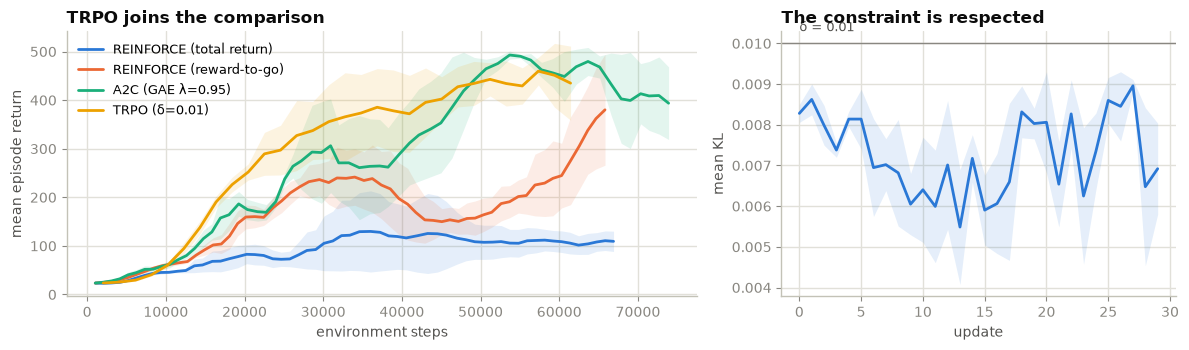

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
for name, (curves, steps) in pg_results.items():
    plot_runs(axes[0], curves, label=name, k=3, x=steps[0])
finish(axes[0], "TRPO joins the comparison", "environment steps", "mean episode return")
plot_runs(axes[1], kl_curves, label="KL(old‖new) after each update", color=PALETTE[0])
axes[1].axhline(0.01, color=MUTED, lw=1); axes[1].text(0, 0.0103, "δ = 0.01", color=INK2, fontsize=9)
finish(axes[1], "The constraint is respected", "update", "mean KL", legend=False)
plt.tight_layout(); plt.show()

## Why the natural gradient direction is special

Take a batch from a snapshot of training and walk along two directions from the current parameters:
the natural-gradient step $F^{-1} g$ (scaled so that $s=1$ is exactly TRPO's step) and the plain
gradient $g$ (scaled to the same Euclidean length). We measure the surrogate objective and the true KL
along each ray.

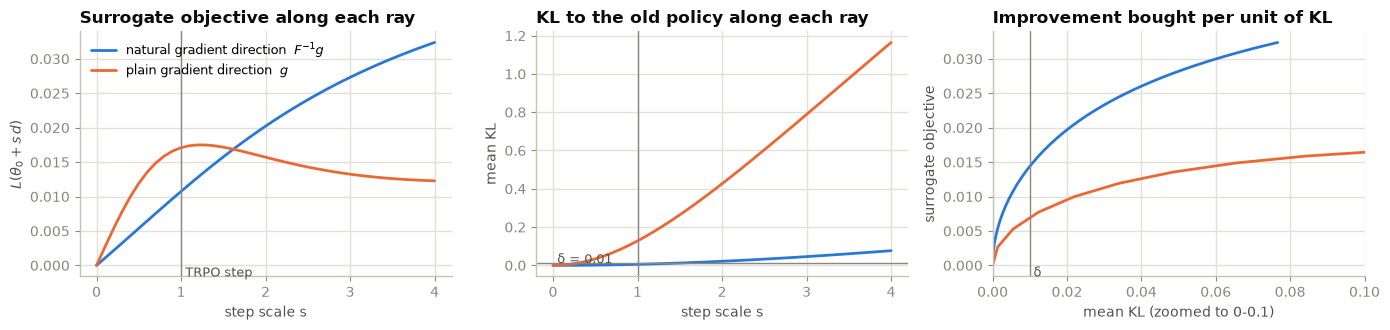

In [86]:
pol_s, val_s, ro_s = trpo_snapshot
pol_s = copy.deepcopy(pol_s); opt_dummy = torch.optim.Adam(val_s.parameters(), lr=0.0)
_, (obs, act, adv, old_logp, old_dist, g, full_step) = trpo_update(pol_s, val_s, opt_dummy, ro_s, backtrack_iters=0, value_steps=0)
theta0 = flat_params(pol_s)
grad_step = g / g.norm() * full_step.norm()                 # plain gradient, same length as the TRPO step

def measure(direction, scales):
    Ls, KLs = [], []
    for s in scales:
        set_flat_params(pol_s, theta0 + s * direction)
        with torch.no_grad():
            d = pol_s.dist(obs)
            Ls.append((torch.exp(d.log_prob(act) - old_logp) * adv).mean().item())
            KLs.append(torch.distributions.kl_divergence(old_dist, d).mean().item())
    set_flat_params(pol_s, theta0)
    return np.array(Ls), np.array(KLs)

scales = np.linspace(0, 4, 41)
L_nat, KL_nat = measure(full_step, scales); L_grad, KL_grad = measure(grad_step, scales)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
axes[0].plot(scales, L_nat, label="natural gradient direction  $F^{-1}g$"); axes[0].plot(scales, L_grad, label="plain gradient direction  $g$")
axes[0].axvline(1, color=MUTED, lw=1); axes[0].text(1.05, axes[0].get_ylim()[0], "TRPO step", color=INK2, fontsize=9)
finish(axes[0], "Surrogate objective along each ray", "step scale s", "$L(\\theta_0 + s\\, d)$")
axes[1].plot(scales, KL_nat); axes[1].plot(scales, KL_grad)
axes[1].axhline(0.01, color=MUTED, lw=1); axes[1].text(0.05, 0.011, "δ = 0.01", color=INK2, fontsize=9); axes[1].axvline(1, color=MUTED, lw=1)
finish(axes[1], "KL to the old policy along each ray", "step scale s", "mean KL", legend=False)
axes[2].plot(KL_nat, L_nat); axes[2].plot(KL_grad, L_grad); axes[2].set_xlim(0, 0.1)
axes[2].axvline(0.01, color=MUTED, lw=1); axes[2].text(0.011, axes[2].get_ylim()[0], "δ", color=INK2, fontsize=9)
finish(axes[2], "Improvement bought per unit of KL", "mean KL (zoomed to 0-0.1)", "surrogate objective", legend=False)
plt.tight_layout(); plt.show()

Per unit of *parameter* length (left two panels) the plain gradient improves the surrogate faster, but it
also moves the **policy distribution** many times further: its KL explodes while the natural direction's
KL grows gently and hits $\delta$ exactly at the TRPO step. The fair comparison is the right panel,
improvement per unit of KL: for any given policy change we are willing to tolerate, the natural direction buys
more objective. That is what "measuring distance in policy space, not parameter space" means, and it is
why a large plain-gradient step can wreck a policy that a same-length natural step would only nudge.

**Why not just use TRPO everywhere?** Every update needs several Fisher-vector products (each a
double backward pass) and a line search, it is awkward with shared actor-critic parameters and with
dropout / batch-norm, and it does not scale gracefully to billion-parameter models. PPO keeps the
idea and drops the machinery.

### Test your knowledge

In [87]:
register_quiz('8.1',
    'Why does TRPO measure the step in KL divergence rather than in Euclidean parameter distance?',
    ['Because the Fisher matrix is diagonal', 'Euclidean distance is undefined for neural networks', 'KL is cheaper to compute than a norm', 'The same parameter change can alter the action distribution a lot or a little depending on where you are; KL measures the change that actually matters for the data you collect'],
    '51a21d89c6be789e98b78f7046764b14e1c6485af49ea300c7d6241153da92c5',
    'UG9saWN5IHBlcmZvcm1hbmNlIGRlcGVuZHMgb24gdGhlIGFjdGlvbiBkaXN0cmlidXRpb24sIG5vdCBvbiB0aGUgcGFyYW1ldGVyaXNhdGlvbi4gQSB0cnVzdCByZWdpb24gaW4gS0wgaXMgaW52YXJpYW50IHRvIHJlcGFyYW1ldGVyaXNhdGlvbiwgd2hpY2ggaXMgZXhhY3RseSB0aGUgcHJvcGVydHkgYSBzdGVwLXNpemUgcnVsZSBmb3Igb24tcG9saWN5IGxlYXJuaW5nIHNob3VsZCBoYXZlLg==')
quiz('8.1')

QUIZ 8.1: Why does TRPO measure the step in KL divergence rather than in Euclidean parameter distance?

   A)  Because the Fisher matrix is diagonal
   B)  Euclidean distance is undefined for neural networks
   C)  KL is cheaper to compute than a norm
   D)  The same parameter change can alter the action distribution a lot or a little depending on where you are; KL measures the change that actually matters for the data you collect

-> put your choice in the answer('8.1', ...) cell below and run it.


In [88]:
answer('8.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [89]:
register_quiz('8.2',
    'What does conjugate gradient compute in TRPO, and why not just invert the Fisher matrix?',
    ['It replaces the line search', 'It solves F x = g using only Fisher-vector products; forming or inverting F (#params squared) would be far too expensive', 'It computes the KL divergence exactly', 'It computes the policy gradient g; inversion is impossible for non-square matrices'],
    '4d9c84efa098132d9475e3a3751b13e5f43321efd293eb68f57dcc8f2cecbe74',
    'RWFjaCBGaXNoZXItdmVjdG9yIHByb2R1Y3QgaXMgb25lIGV4dHJhIGJhY2t3YXJkIHBhc3MsIHNvIH4xMCBDRyBpdGVyYXRpb25zIGNvc3QgYWJvdXQgMTAgYmFja3dhcmQgcGFzc2VzLCBpbmRlcGVuZGVudCBvZiB0aGUgcGFyYW1ldGVyIGNvdW50LiBGb3JtaW5nIEYgd291bGQgbmVlZCAoI3BhcmFtcyleMiBtZW1vcnku')
quiz('8.2')

QUIZ 8.2: What does conjugate gradient compute in TRPO, and why not just invert the Fisher matrix?

   A)  It replaces the line search
   B)  It solves F x = g using only Fisher-vector products; forming or inverting F (#params squared) would be far too expensive
   C)  It computes the KL divergence exactly
   D)  It computes the policy gradient g; inversion is impossible for non-square matrices

-> put your choice in the answer('8.2', ...) cell below and run it.


In [90]:
answer('8.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [91]:
register_quiz('8.3',
    'The line search rejects a step when the real KL exceeds 1.5*delta or the surrogate does not improve. Why is that check necessary at all?',
    ['Because CG is randomised', "It isn't; it only saves computation", 'Because the step was computed from a second-order Taylor model of the KL and a first-order model of the objective, which can be wrong for a step of finite size', 'Because the value function is inaccurate'],
    '41acc3b54a9dcd53baa1a1fe7ecefa9ab4161ea91f0157cd61b6c7852e466251',
    'VGhlIG5hdHVyYWwtZ3JhZGllbnQgc3RlcCBpcyBleGFjdCBvbmx5IGZvciB0aGUgcXVhZHJhdGljIGFwcHJveGltYXRpb24uIEJhY2t0cmFja2luZyBndWFyYW50ZWVzIHRoZSB0d28gdGhpbmdzIHdlIGFjdHVhbGx5IGNhcmUgYWJvdXQsIG1vbm90b25lIGltcHJvdmVtZW50IG9mIHRoZSBzdXJyb2dhdGUgYW5kIGEgYm91bmRlZCBwb2xpY3kgY2hhbmdlLCBob2xkIGZvciB0aGUgcmVhbCBmdW5jdGlvbnMu')
quiz('8.3')

QUIZ 8.3: The line search rejects a step when the real KL exceeds 1.5*delta or the surrogate does not improve. Why is that check necessary at all?

   A)  Because CG is randomised
   B)  It isn't; it only saves computation
   C)  Because the step was computed from a second-order Taylor model of the KL and a first-order model of the objective, which can be wrong for a step of finite size
   D)  Because the value function is inaccurate

-> put your choice in the answer('8.3', ...) cell below and run it.


In [92]:
answer('8.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 8.4 · Conjugate gradient

Implement `my_cg(Avp, b, iters=20)` that solves $Ax = b$ for a symmetric positive-definite $A$ given
only a function `Avp(v) -> A @ v`. Use the standard recurrences (residual $r$, search direction $p$,
step $\alpha = r^\top r / p^\top A p$, $\beta = r_{\text{new}}^\top r_{\text{new}} / r^\top r$).

In [93]:
def my_cg(Avp, b, iters=20):
    # YOUR CODE HERE
    raise NotImplementedError

In [94]:
register_exercise('8.4', 'ZGVmIG15X2NnKEF2cCwgYiwgaXRlcnM9MjApOgogICAgeCwgciA9IHRvcmNoLnplcm9zX2xpa2UoYiksIGIuY2xvbmUoKTsgcCwgcnIgPSByLmNsb25lKCksIHIgQCByCiAgICBmb3IgXyBpbiByYW5nZShpdGVycyk6CiAgICAgICAgQXAgPSBBdnAocCk7IGFscGhhID0gcnIgLyAocCBAIEFwKQogICAgICAgIHggPSB4ICsgYWxwaGEgKiBwOyByID0gciAtIGFscGhhICogQXAKICAgICAgICBycl9uZXcgPSByIEAgcgogICAgICAgIGlmIHJyX25ldyA8IDFlLTEwOiBicmVhawogICAgICAgIHAgPSByICsgKHJyX25ldyAvIHJyKSAqIHA7IHJyID0gcnJfbmV3CiAgICByZXR1cm4geA==')

def _tests(fn):
    torch.manual_seed(0)
    M = torch.randn(6, 6); A = M @ M.T + 0.5 * torch.eye(6)     # SPD
    b = torch.randn(6)
    x = fn(lambda v: A @ v, b, iters=20)
    assert x is not None and x.shape == b.shape, "wrong shape"
    assert torch.allclose(A @ x, b, atol=1e-3), f"residual too large: {(A @ x - b).norm():.4f}"

check('8.4', my_cg, _tests)
# solution('8.4')   # <- uncomment to reveal the reference solution

[8.4] not implemented yet. Fill in the cell above (or run solution('8.4')).


---
# Part 9 · PPO: proximal policy optimisation

PPO (Schulman et al., 2017) keeps TRPO's insight, *don't let the policy move too far from the one that
collected the data*, but enforces it with a first-order trick instead of a constrained second-order
solve. Define the probability ratio $\rho_t(\theta) = \pi_\theta(a_t|s_t) / \pi_{\theta_{\text{old}}}(a_t|s_t)$
and use the **clipped surrogate objective**

$$L^{\text{CLIP}}(\theta) = \mathbb E_t\Big[\min\big(\rho_t \hat A_t,\; \text{clip}(\rho_t,\, 1-\epsilon,\, 1+\epsilon)\, \hat A_t\big)\Big].$$

Read it case by case:

* $\hat A_t > 0$ (good action): we would like to raise $\rho_t$, but once $\rho_t > 1 + \epsilon$ the clipped
  term is flat and the min picks it, so **the gradient is zero**. No incentive to move further.
* $\hat A_t < 0$ (bad action): we would like to lower $\rho_t$, but below $1 - \epsilon$ the gradient again vanishes.
* The `min` makes the objective a **pessimistic lower bound**: the clip only ever removes incentives,
  never adds them, so the unclipped objective is always used when it is *worse*.

Because clipping kills the gradient of samples that already moved far, we can safely take **many
gradient steps on the same batch** (several epochs of minibatches). That is the source of PPO's sample
efficiency compared to A2C, and the whole reason it became the default for everything from robotics to
RLHF.

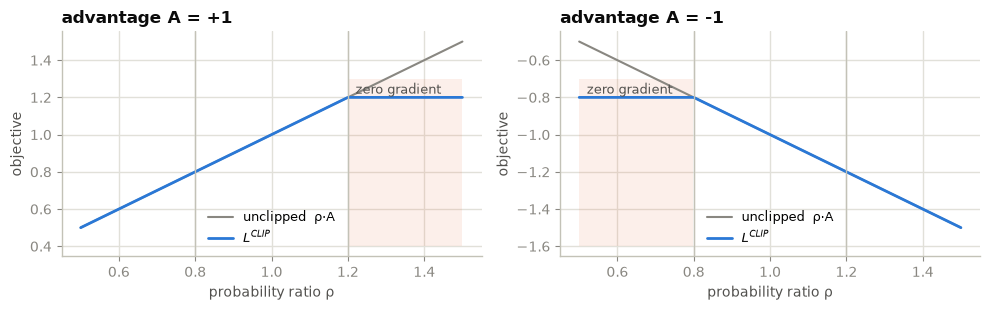

In [95]:
ratio = np.linspace(0.5, 1.5, 300); eps = 0.2
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, A in zip(axes, [1.0, -1.0]):
    unclipped = ratio * A
    clipped = np.minimum(ratio * A, np.clip(ratio, 1 - eps, 1 + eps) * A)
    ax.plot(ratio, unclipped, color=MUTED, lw=1.5, label="unclipped  ρ·A")
    ax.plot(ratio, clipped, label="$L^{CLIP}$")
    ax.axvline(1 - eps, color=AXIS, lw=1); ax.axvline(1 + eps, color=AXIS, lw=1)
    flat = ratio > 1 + eps if A > 0 else ratio < 1 - eps
    ax.fill_between(ratio, clipped.min() - 0.1, clipped.max() + 0.1, where=flat, color=PALETTE[1], alpha=0.10, linewidth=0)
    ax.text(1 + eps + 0.02 if A > 0 else 0.52, clipped.max() + 0.02, "zero gradient", color=INK2, fontsize=9)
    finish(ax, f"advantage A = {A:+.0f}", "probability ratio ρ", "objective")
plt.tight_layout(); plt.show()

## The full recipe

The objective above is the heart; a production PPO adds several details, all of which matter:

| Ingredient | Why |
|---|---|
| GAE advantages, normalised per minibatch | low-variance credit assignment; scale-free updates |
| Value loss $\tfrac12 (V_\theta(s_t) - \hat R_t)^2$ | the critic is trained jointly (optionally clipped too) |
| Entropy bonus $-\beta\, \mathcal H[\pi_\theta(\cdot|s)]$ | discourages premature collapse to a deterministic policy |
| Several epochs of minibatch SGD per batch | reuses data; the clip makes it safe |
| Global gradient-norm clipping (0.5) | robustness against rare huge advantages |
| Diagnostics: approx. KL, clip fraction, explained variance | tells you whether the update is too aggressive or the critic is useless |

We'll implement all of it in about 40 lines.

In [96]:
def ppo_update(policy, value, opt, ro, gamma=0.99, lam=0.95, clip=0.2, epochs=10, minibatch=256,
               vf_coef=0.5, ent_coef=0.0, max_grad_norm=0.5, record_ratios=False):
    with torch.no_grad():
        v, v_next = value(ro.obs).numpy(), value(ro.next_obs).numpy()
        old_logp = policy.dist(ro.obs).log_prob(ro.act)
    adv, ret = compute_gae(ro.rew, v, v_next, ro.term, ro.done, gamma, lam)
    adv, ret = torch.as_tensor(adv), torch.as_tensor(ret)
    N, params = len(ro.rew), list(policy.parameters()) + list(value.parameters())
    stats = defaultdict(list); ratio_snapshots = {}
    for epoch in range(epochs):
        perm = torch.randperm(N)
        for start in range(0, N, minibatch):
            idx = perm[start:start + minibatch]
            dist = policy.dist(ro.obs[idx]); logp = dist.log_prob(ro.act[idx])
            ratio = torch.exp(logp - old_logp[idx])                         # pi_theta / pi_old
            mb_adv = adv[idx]; mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)
            pg_loss = -torch.min(ratio * mb_adv, torch.clamp(ratio, 1 - clip, 1 + clip) * mb_adv).mean()
            v_loss = 0.5 * F.mse_loss(value(ro.obs[idx]), ret[idx])
            entropy = dist.entropy().mean()
            loss = pg_loss + vf_coef * v_loss - ent_coef * entropy
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(params, max_grad_norm); opt.step()
            with torch.no_grad():                                           # diagnostics
                stats["approx_kl"].append(((ratio - 1) - torch.log(ratio)).mean().item())   # k3 estimator of KL(old||new)
                stats["clipfrac"].append(((ratio - 1).abs() > clip).float().mean().item())
                stats["entropy"].append(entropy.item())
        if record_ratios and epoch in (0, epochs - 1):
            with torch.no_grad():
                ratio_snapshots[epoch] = torch.exp(policy.dist(ro.obs).log_prob(ro.act) - old_logp).numpy()
    with torch.no_grad():                                                   # explained variance of the critic
        v_pred = value(ro.obs); ev = 1 - (ret - v_pred).var() / (ret.var() + 1e-8)
    out = {k: float(np.mean(vals)) for k, vals in stats.items()}; out["explained_var"] = ev.item()
    return out, ratio_snapshots

def train_ppo(seed=0, iters=30, batch_steps=2048, lr=1e-3, record_at=None, **kw):
    seed_everything(seed)
    env = CartPole(); policy, value = Policy(env.obs_dim, env.n_actions), ValueNet(env.obs_dim)
    opt = torch.optim.Adam(list(policy.parameters()) + list(value.parameters()), lr=lr, eps=1e-5)
    curve, steps, diag, total, ratios = [], [], defaultdict(list), 0, None
    for it in range(iters):
        ro = collect_rollout(env, policy, batch_steps)
        stats, snaps = ppo_update(policy, value, opt, ro, record_ratios=(it == record_at), **kw)
        if snaps: ratios = snaps
        total += len(ro.rew); curve.append(np.mean(ro.ep_returns) if ro.ep_returns else curve[-1]); steps.append(total)
        for k, v_ in stats.items(): diag[k].append(v_)
    return policy, value, np.array(curve), np.array(steps), diag, ratios

In [97]:
with Timer("PPO"):
    curves, steps, diags = [], [], []
    for seed in range(N_SEEDS):
        pol_ppo, val_ppo, c, s, d, r_snap = train_ppo(seed, iters=TOTAL_STEPS // 2048, record_at=8)
        curves.append(c); steps.append(s); diags.append(d)
        if seed == 0: ppo_ratios = r_snap
    pg_results["PPO (clip 0.2)"] = (curves, steps)
    print(f"PPO final return (mean over seeds): {np.mean([c[-1] for c in curves]):6.1f}")

PPO final return (mean over seeds):  500.0
[PPO] 42.1s


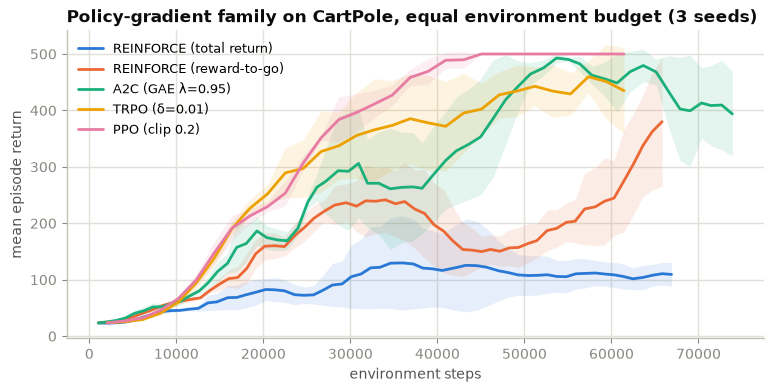

In [98]:
fig, ax = plt.subplots(figsize=(9, 4))
for name, (curves, steps) in pg_results.items():
    plot_runs(ax, curves, label=name, k=3, x=steps[0])
finish(ax, f"Policy-gradient family on CartPole, equal environment budget ({N_SEEDS} seeds)", "environment steps", "mean episode return")
plt.show()

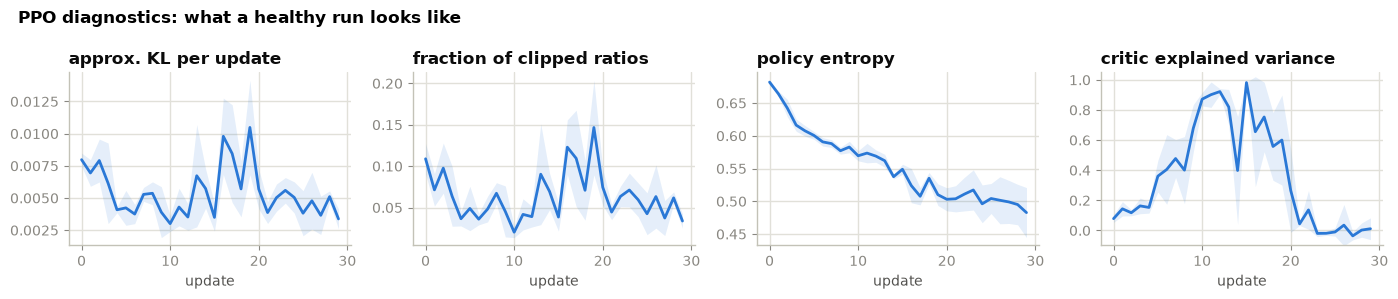

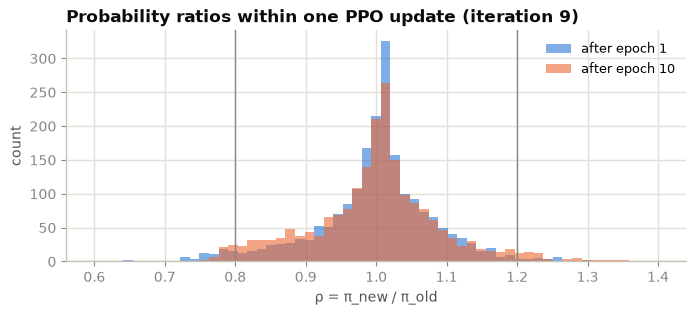

In [99]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, key, title in zip(axes, ["approx_kl", "clipfrac", "entropy", "explained_var"],
                          ["approx. KL per update", "fraction of clipped ratios", "policy entropy", "critic explained variance"]):
    plot_runs(ax, [d[key] for d in diags], color=PALETTE[0])
    finish(ax, title, "update", None, legend=False)
axes[3].set_ylim(-0.1, 1.05)
plt.suptitle("PPO diagnostics: what a healthy run looks like", x=0.01, ha="left", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 3))
bins = np.linspace(0.6, 1.4, 60)
for ep, r in ppo_ratios.items():
    ax.hist(r, bins=bins, alpha=0.6, label=f"after epoch {ep + 1}", edgecolor="none")
ax.axvline(0.8, color=MUTED, lw=1); ax.axvline(1.2, color=MUTED, lw=1)
finish(ax, "Probability ratios within one PPO update (iteration 9)", "ρ = π_new / π_old", "count")
plt.show()

**Reading the diagnostics.** Before the update every ratio is exactly 1. After the first epoch (8 minibatch
steps) they have already spread a little; by the last epoch a visible fraction sits at or beyond the clip
boundaries, and those samples contribute no gradient any more. Healthy runs show approximate KL around 0.005–0.03 per update,
clip fraction 0.05–0.3, entropy decreasing slowly, and explained variance climbing toward 1. If KL
explodes, lower the learning rate or the number of epochs; if explained variance stays near 0 *while
returns are still improving*, the critic is useless and the advantages are mostly noise.

One trap in the last panel: once every episode reaches the 500-step cap, every state is worth about
$1/(1-\gamma)$ and the return targets have almost no variance left to explain, so explained variance
collapses toward 0 (or goes negative) even though the critic is fine. Diagnostics need context.

## Variants you will meet in the wild

* **PPO-penalty**: replace the clip with $-\beta\, \mathrm{KL}(\pi_{\text{old}} \| \pi_\theta)$ and adapt
  $\beta$ up or down depending on whether the measured KL exceeds a target. Rarely used for control,
  but the per-token KL penalty in RLHF (Part 12) is its cousin.
* **Value clipping**: clip the value prediction around its old value the same way. Popular in
  implementations, of dubious benefit.
* **Dual-clip PPO**: for $\hat A_t < 0$, also cap $\rho_t$ from above (e.g. at 3) so that a single
  very-off-policy sample cannot dominate.
* **Early stopping on KL**: stop the epochs when approximate KL exceeds a target (e.g. 0.015–0.05).
  Simple and effective; many LLM trainers do this.

### Test your knowledge

In [100]:
register_quiz('9.1',
    'For a sample with negative advantage and ratio rho = 0.7 (clip eps = 0.2), what is the gradient contribution of the PPO objective?',
    ['Large negative, pushing the probability down further', 'Positive, pushing the probability back up', 'Undefined', 'Zero: the clipped term is active and it is constant in theta'],
    'e7bbefcb848f979b8704daed21c5eb120d53ece04261db9bce88fea3848d396a',
    'Rm9yIEEgPCAwIHRoZSBvYmplY3RpdmUgaXMgbWF4KHJobypBLCBjbGlwKHJobykqQSkgaW4gYWJzb2x1dGUgdGVybXM7IGJlbG93IDEgLSBlcHMgdGhlIGNsaXBwZWQgYnJhbmNoIHdpbnMgYW5kIGlzIGZsYXQsIHNvIHRoaXMgc2FtcGxlIGhhcyBhbHJlYWR5IGJlZW4gcHVzaGVkIGRvd24gJ2Vub3VnaCcgYW5kIGlzIGlnbm9yZWQuIE5vdGUgdGhlIGFzeW1tZXRyeTogaWYgcmhvIHdlcmUgMC43IHdpdGggQSA+IDAgdGhlIHVuY2xpcHBlZCBicmFuY2ggKHdoaWNoIGlzIGxvd2VyKSB3b3VsZCBiZSBhY3RpdmUsIGFuZCB0aGUgZ3JhZGllbnQgd291bGQgcHVsbCB0aGUgcHJvYmFiaWxpdHkgYmFjayB1cC4=')
quiz('9.1')

QUIZ 9.1: For a sample with negative advantage and ratio rho = 0.7 (clip eps = 0.2), what is the gradient contribution of the PPO objective?

   A)  Large negative, pushing the probability down further
   B)  Positive, pushing the probability back up
   C)  Undefined
   D)  Zero: the clipped term is active and it is constant in theta

-> put your choice in the answer('9.1', ...) cell below and run it.


In [101]:
answer('9.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [102]:
register_quiz('9.2',
    'Why can PPO run 10 epochs on one batch while REINFORCE / A2C take a single gradient step?',
    ['The importance ratio corrects for the policy drifting away from the data-collecting policy, and the clip prevents that drift from becoming large enough to make the correction unreliable', "PPO's critic makes the data on-policy again", "PPO's learning rate is smaller", 'PPO uses a replay buffer'],
    'd583f92474339dc04184cb658079cca34ba970e686a42da996b9ad61842f3755',
    'VGhlIHN1cnJvZ2F0ZSBMIGlzIGFuIGltcG9ydGFuY2Utc2FtcGxlZCBlc3RpbWF0ZSB0aGF0IGlzIHZhbGlkIG9ubHkgd2hpbGUgdGhlIG5ldyBwb2xpY3kgc3RheXMgY2xvc2UgdG8gdGhlIG9sZC4gQ2xpcHBpbmcgKHBsdXMgZ3JhZGllbnQgY2xpcHBpbmcgYW5kIEtMIG1vbml0b3JpbmcpIGtlZXBzIGl0IGluIHRoYXQgcmVnaW1lLCBzbyByZS11c2luZyB0aGUgYmF0Y2ggaXMgY2hlYXAgZXh0cmEgc2lnbmFsLg==')
quiz('9.2')

QUIZ 9.2: Why can PPO run 10 epochs on one batch while REINFORCE / A2C take a single gradient step?

   A)  The importance ratio corrects for the policy drifting away from the data-collecting policy, and the clip prevents that drift from becoming large enough to make the correction unreliable
   B)  PPO's critic makes the data on-policy again
   C)  PPO's learning rate is smaller
   D)  PPO uses a replay buffer

-> put your choice in the answer('9.2', ...) cell below and run it.


In [103]:
answer('9.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [104]:
register_quiz('9.3',
    'Your PPO run shows approx_kl = 0.2 per update and a clip fraction of 0.8. What is the most likely fix?',
    ['Increase gamma', 'Increase the number of epochs', 'Remove advantage normalisation', 'Lower the learning rate or the number of epochs, or add early stopping on KL; the policy is moving far too much per update'],
    '47a951c35f1bceaa79767ef620ee2d54a4e9ea1a43b16c335767d4a2bee4de37',
    'VGhvc2UgbnVtYmVycyBtZWFuIG5lYXJseSBldmVyeSBzYW1wbGUgaXMgb3V0c2lkZSB0aGUgdHJ1c3QgcmVnaW9uIGFuZCB0aGUgcG9saWN5IGNoYW5nZWQgZHJhc3RpY2FsbHkuIFRoYXQgaXMgdGhlIGluc3RhYmlsaXR5IFBQTyBleGlzdHMgdG8gcHJldmVudC4gVHlwaWNhbCBoZWFsdGh5IHZhbHVlcyBhcmUgS0wgfiAwLjAxIGFuZCBjbGlwIGZyYWN0aW9uIH4gMC4xLTAuMy4=')
quiz('9.3')

QUIZ 9.3: Your PPO run shows approx_kl = 0.2 per update and a clip fraction of 0.8. What is the most likely fix?

   A)  Increase gamma
   B)  Increase the number of epochs
   C)  Remove advantage normalisation
   D)  Lower the learning rate or the number of epochs, or add early stopping on KL; the policy is moving far too much per update

-> put your choice in the answer('9.3', ...) cell below and run it.


In [105]:
answer('9.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 9.4 · The clipped surrogate loss

Implement `ppo_clip_loss(logp_new, logp_old, adv, eps)` returning the **scalar loss to minimise**
(the negative clipped objective, averaged over the batch). All inputs are 1-D tensors.

In [106]:
def ppo_clip_loss(logp_new, logp_old, adv, eps=0.2):
    # YOUR CODE HERE
    raise NotImplementedError

In [107]:
register_exercise('9.4', 'ZGVmIHBwb19jbGlwX2xvc3MobG9ncF9uZXcsIGxvZ3Bfb2xkLCBhZHYsIGVwcz0wLjIpOgogICAgcmF0aW8gPSB0b3JjaC5leHAobG9ncF9uZXcgLSBsb2dwX29sZCkKICAgIHJldHVybiAtdG9yY2gubWluKHJhdGlvICogYWR2LCB0b3JjaC5jbGFtcChyYXRpbywgMSAtIGVwcywgMSArIGVwcykgKiBhZHYpLm1lYW4oKQ==')

def _tests(fn):
    logp_old = torch.log(torch.tensor([0.5, 0.5, 0.5, 0.5]))
    logp_new = torch.log(torch.tensor([0.5, 0.75, 0.25, 0.75]))     # ratios 1.0, 1.5, 0.5, 1.5
    adv = torch.tensor([1.0, 1.0, -1.0, -1.0])
    loss = fn(logp_new, logp_old, adv, 0.2)
    assert loss is not None and loss.dim() == 0, "return a scalar"
    # per-sample objective: min(1*1, 1*1)=1 ; min(1.5, 1.2)=1.2 ; min(-0.5, -0.8)=-0.8 ; min(-1.5, -1.2)=-1.5
    expected = -torch.tensor([1.0, 1.2, -0.8, -1.5]).mean()
    assert torch.isclose(loss, expected, atol=1e-6), f"expected {expected.item():.4f}, got {loss.item():.4f}"

check('9.4', ppo_clip_loss, _tests)
# solution('9.4')   # <- uncomment to reveal the reference solution

[9.4] not implemented yet. Fill in the cell above (or run solution('9.4')).


---
# Part 10 · RL for language models: the setting

Everything so far was about balancing poles. The same machinery now trains the systems you talk to.
The mapping is exact once you see it:

| RL concept | In an LLM |
|---|---|
| state $s_t$ | the prompt plus the tokens generated so far |
| action $a_t$ | the next token (vocabulary of ~100k "arms") |
| policy $\pi_\theta(a_t \mid s_t)$ | the LM's next-token distribution |
| transition | deterministic: append the token |
| episode / trajectory | one complete response |
| reward | usually a single number at the end: a reward model's score, a unit test passing, a correct final answer |
| discount $\gamma$ | 1 (a few thousand steps, all of which matter) |

Two things are different from CartPole and shape every algorithm in Parts 11–17:

1. **The reward is sparse and terminal.** One scalar for a thousand-token response. Credit assignment
   across tokens is brutal, so most methods give every token of a response the *same* advantage.
2. **We start from a very good policy.** Pretraining plus supervised fine-tuning already produce
   sensible text. RL's job is to *sharpen* and *steer* that policy, not to learn from scratch, and
   drifting too far from the starting point destroys capabilities. Hence the ubiquitous **KL penalty to a
   reference model**.

## The post-training pipeline

The classic RLHF recipe (Ouyang et al., 2022, InstructGPT) has three stages after pretraining.
Newer "reasoning" recipes (DeepSeek-R1, 2025) replace the reward model with a **verifier** (RL with
verifiable rewards, RLVR), and DPO-style methods (Part 13) skip the RL loop entirely.

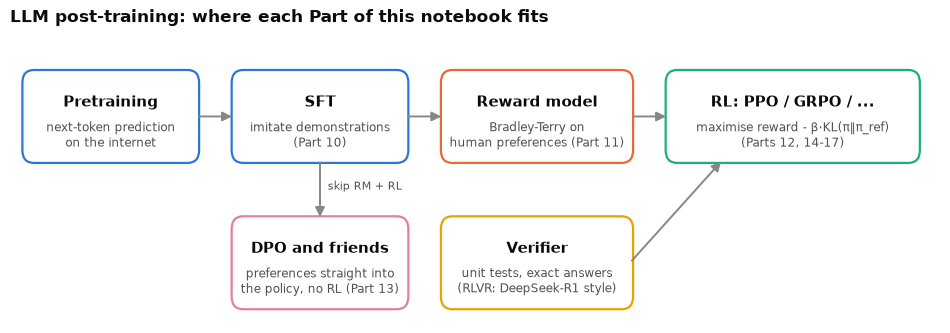

In [108]:
def draw_pipeline():
    fig, ax = plt.subplots(figsize=(12, 3.8)); ax.set_xlim(0, 12); ax.set_ylim(0.3, 3.7); ax.axis("off"); ax.grid(False)
    def box(x, y, w, h, text, color, sub=None):
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.04,rounding_size=0.15", fc="white", ec=color, lw=1.6))
        ax.text(x + w / 2, y + h / 2 + (0.16 if sub else 0), text, ha="center", va="center", fontsize=10.5, color=INK, fontweight="bold")
        if sub: ax.text(x + w / 2, y + h / 2 - 0.22, sub, ha="center", va="center", fontsize=8.5, color=INK2)
    def arrow(x0, y0, x1, y1, color=MUTED, style="-|>"):
        ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle=style, mutation_scale=14, lw=1.4, color=color, connectionstyle="arc3,rad=0.0"))
    box(0.2, 2.2, 2.2, 1.0, "Pretraining", PALETTE[0], "next-token prediction\non the internet")
    box(2.9, 2.2, 2.2, 1.0, "SFT", PALETTE[0], "imitate demonstrations\n(Part 10)")
    box(5.6, 2.2, 2.4, 1.0, "Reward model", PALETTE[1], "Bradley-Terry on\nhuman preferences (Part 11)")
    box(8.5, 2.2, 3.2, 1.0, "RL: PPO / GRPO / ...", PALETTE[2], "maximise reward - β·KL(π‖π_ref)\n(Parts 12, 14-17)")
    arrow(2.4, 2.7, 2.9, 2.7); arrow(5.1, 2.7, 5.6, 2.7); arrow(8.0, 2.7, 8.5, 2.7)
    box(5.6, 0.5, 2.4, 1.0, "Verifier", PALETTE[3], "unit tests, exact answers\n(RLVR: DeepSeek-R1 style)")
    arrow(8.0, 1.0, 9.2, 2.2)
    box(2.9, 0.5, 2.2, 1.0, "DPO and friends", PALETTE[4], "preferences straight into\nthe policy, no RL (Part 13)")
    arrow(4.0, 2.2, 4.0, 1.5)
    ax.text(4.1, 1.85, "skip RM + RL", fontsize=8, color=INK2)
    ax.set_title("LLM post-training: where each Part of this notebook fits")
    plt.show()
draw_pipeline()

## A toy language model we can train in seconds

We need a "language model" small enough to train on a CPU in seconds but real enough that
token-level RL makes sense. We'll use a **two-layer transformer** with a 16-token vocabulary on a
mini arithmetic task:

> prompt: `07+15=` → completion: `22<eos>`

* **Easy prompts** have both operands below 10 (100 prompts). **Hard** prompts have at least one
  two-digit operand (300 prompts). This is our stand-in for problems of varying difficulty.
* The **verifier** is exact-match against the true sum in canonical form (`22`, not `022`).
* Two extra tokens, `<call>` and `<obs>`, are reserved for the tool-use agent in Part 17.

We deliberately fine-tune the model on **noisy demonstrations**: hard prompts get the correct answer
only half the time. That mimics a real base model that "knows" the answer sometimes, which is exactly
when RL helps: the model already contains the right behaviour at some probability, and RL amplifies it.

In [109]:
# ---- Vocabulary and task ----
VOCAB = [str(d) for d in range(10)] + ["+", "=", "<eos>", "<pad>", "<call>", "<obs>"]
PLUS, EQ, EOS, PAD, CALL, OBS = 10, 11, 12, 13, 14, 15
V_SIZE, PROMPT_LEN, MAX_NEW, CTX = len(VOCAB), 6, 4, 16
MAX_OPERAND = 19
ALL_PAIRS = [(a, b) for a in range(MAX_OPERAND + 1) for b in range(MAX_OPERAND + 1)]
def is_easy(a, b): return a < 10 and b < 10
EASY_PAIRS = [p for p in ALL_PAIRS if is_easy(*p)]; HARD_PAIRS = [p for p in ALL_PAIRS if not is_easy(*p)]

def encode_prompt(a, b): return [a // 10, a % 10, PLUS, b // 10, b % 10, EQ]
def encode_answer(n, zero_pad=False): return [int(ch) for ch in (f"{n:02d}" if zero_pad else str(n))] + [EOS]
def decode(tokens): return "".join(VOCAB[int(t)] for t in tokens if int(t) != PAD)

def parse_completion(tokens):
    '''Digits up to <eos>. Returns (string, well_formed).'''
    digits = []
    for t in tokens:
        t = int(t)
        if t == EOS: return "".join(map(str, digits)), True
        if t > 9: return None, False                          # any non-digit token before <eos> is malformed
        digits.append(t)
    return None, False                                        # ran out of tokens without <eos>

def verify(a, b, completion_tokens):
    '''The verifiable reward: 1.0 iff the completion is exactly the canonical sum followed by <eos>.'''
    s, ok = parse_completion(completion_tokens)
    return float(ok and s == str(a + b))

print(f"{len(ALL_PAIRS)} prompts ({len(EASY_PAIRS)} easy, {len(HARD_PAIRS)} hard). Example prompt:", decode(encode_prompt(7, 15)),
      "-> answer", decode(encode_answer(22)), "| reward for '22<eos>':", verify(7, 15, encode_answer(22)),
      "| for '022<eos>':", verify(7, 15, [0, 2, 2, EOS]))

400 prompts (100 easy, 300 hard). Example prompt: 07+15= -> answer 22<eos> | reward for '22<eos>': 1.0 | for '022<eos>': 0.0


In [110]:
# ---- A tiny GPT ----
class Block(nn.Module):
    def __init__(self, d, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.qkv, self.proj = nn.Linear(d, 3 * d), nn.Linear(d, d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
    def forward(self, x):
        B, T, D = x.shape
        q, k, v = self.qkv(self.ln1(x)).split(D, dim=-1)
        q, k, v = [t.view(B, T, self.n_heads, D // self.n_heads).transpose(1, 2) for t in (q, k, v)]
        att = F.scaled_dot_product_attention(q, k, v, is_causal=True)      # causal self-attention
        x = x + self.proj(att.transpose(1, 2).reshape(B, T, D))
        return x + self.mlp(self.ln2(x))

class TinyLM(nn.Module):
    def __init__(self, vocab=V_SIZE, d=64, n_layers=2, n_heads=4, ctx=CTX):
        super().__init__()
        self.tok_emb, self.pos_emb = nn.Embedding(vocab, d), nn.Embedding(ctx, d)
        self.blocks = nn.ModuleList([Block(d, n_heads) for _ in range(n_layers)])
        self.ln_f, self.head = nn.LayerNorm(d), nn.Linear(d, vocab, bias=False)
    def hidden(self, idx):                        # (B, T) -> (B, T, d)
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(idx.shape[1]))
        for blk in self.blocks: x = blk(x)
        return self.ln_f(x)
    def forward(self, idx):                       # (B, T) -> logits (B, T, vocab)
        return self.head(self.hidden(idx))

def token_logprobs(model, seq):
    '''log pi(seq[:, t+1] | seq[:, :t+1]) for every position: (B, L) -> (B, L-1).'''
    logits = model(seq[:, :-1])
    return F.log_softmax(logits, -1).gather(-1, seq[:, 1:, None]).squeeze(-1)

def completion_logprobs(model, seq, prompt_len=PROMPT_LEN):
    '''Per-token log-probs of the generated part only: (B, L-prompt_len).'''
    return token_logprobs(model, seq)[:, prompt_len - 1:]

@torch.no_grad()
def generate(model, prompts, max_new=MAX_NEW, temperature=1.0, greedy=False):
    '''Sample completions. Returns seq (B, P+max_new) and mask (B, max_new): 1 for real generated tokens
    (up to and including <eos>), 0 for padding after <eos>.'''
    seq, B = prompts.clone(), prompts.shape[0]
    alive, mask = torch.ones(B, dtype=torch.bool), torch.zeros(B, max_new)
    for t in range(max_new):
        logits = model(seq)[:, -1] / temperature
        nxt = logits.argmax(-1) if greedy else torch.multinomial(F.softmax(logits, -1), 1).squeeze(1)
        nxt = torch.where(alive, nxt, torch.full_like(nxt, PAD))
        mask[:, t] = alive
        seq = torch.cat([seq, nxt[:, None]], 1)
        alive = alive & (nxt != EOS)
    return seq, mask

lm = TinyLM()
print(f"TinyLM parameters: {sum(p.numel() for p in lm.parameters()):,}")
seq, mask = generate(lm, torch.tensor([encode_prompt(7, 15)]))
print("untrained sample:", repr(decode(seq[0, PROMPT_LEN:])), "| mask:", mask[0].tolist())

TinyLM parameters: 103,168
untrained sample: '8<obs>4+' | mask: [1.0, 1.0, 1.0, 1.0]


### Supervised fine-tuning (SFT)

SFT is plain maximum likelihood on demonstration completions, with the loss masked to the completion
tokens (we don't train the model to predict the prompt). We build the dataset with the noise described above,
plus a small "formatting quirk": 5% of single-digit answers are written zero-padded (`07`). The verifier
counts those as wrong, so the SFT model starts with a small format problem that RL can fix.

In [111]:
def make_sft_dataset(pairs, per_prompt=8, hard_correct_prob=0.5, zero_pad_prob=0.05):
    X, Y = [], []
    for a, b in pairs:
        for _ in range(per_prompt):
            ans = a + b
            if not is_easy(a, b) and np.random.rand() > hard_correct_prob:              # noisy label on hard prompts
                ans = max(0, ans + int(np.random.choice([d for d in range(-9, 10) if d != 0])))
            X.append(encode_prompt(a, b)); Y.append(encode_answer(ans, zero_pad=(ans < 10 and np.random.rand() < zero_pad_prob)))
    return X, Y

def pad_batch(X, Y, total_len=PROMPT_LEN + MAX_NEW, roles=None):
    '''Right-pad prompt+completion. loss_mask[i, t] = 1 where seq[i, t+1] is a completion token the MODEL should predict
    (roles, if given, mark which completion tokens belong to the model (1) vs. the environment (0); see Part 17).'''
    seq = torch.full((len(X), total_len), PAD, dtype=torch.long); loss_mask = torch.zeros(len(X), total_len - 1)
    for i, (x, y) in enumerate(zip(X, Y)):
        toks = x + y; seq[i, :len(toks)] = torch.tensor(toks)
        r = roles[i] if roles is not None else [1] * len(y)
        loss_mask[i, len(x) - 1:len(toks) - 1] = torch.tensor(r, dtype=torch.float32)   # predict completion tokens only
    return seq, loss_mask

def sft_train(model, X, Y, steps=1500, batch_size=128, lr=3e-3, verbose=True, roles=None, total_len=PROMPT_LEN + MAX_NEW):
    seq, loss_mask = pad_batch(X, Y, total_len, roles)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)
    losses = []
    for step in range(steps):
        idx = torch.randint(0, len(seq), (batch_size,))
        logp = token_logprobs(model, seq[idx])
        loss = -(logp * loss_mask[idx]).sum() / loss_mask[idx].sum()
        opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); sched.step()
        losses.append(loss.item())
        if verbose and (step + 1) % 500 == 0: print(f"  sft step {step + 1}: loss {np.mean(losses[-100:]):.3f}")
    return losses

seed_everything(0)
X_sft, Y_sft = make_sft_dataset(ALL_PAIRS)
print(f"{len(X_sft)} SFT examples, e.g. {decode(X_sft[900])} -> {decode(Y_sft[900])}")
sft_model = TinyLM()
with Timer("SFT"):
    sft_losses = sft_train(sft_model, X_sft, Y_sft)

3200 SFT examples, e.g. 05+12= -> 17<eos>


  sft step 500: loss 0.580


  sft step 1000: loss 0.466


  sft step 1500: loss 0.412
[SFT] 23.8s


SFT model, sampling at T=1:  accuracy (pass@1) = 0.621   easy = 0.971   hard = 0.505   mean length = 2.84
SFT model, greedy decoding:  accuracy = 0.943   easy = 1.000   hard = 0.923


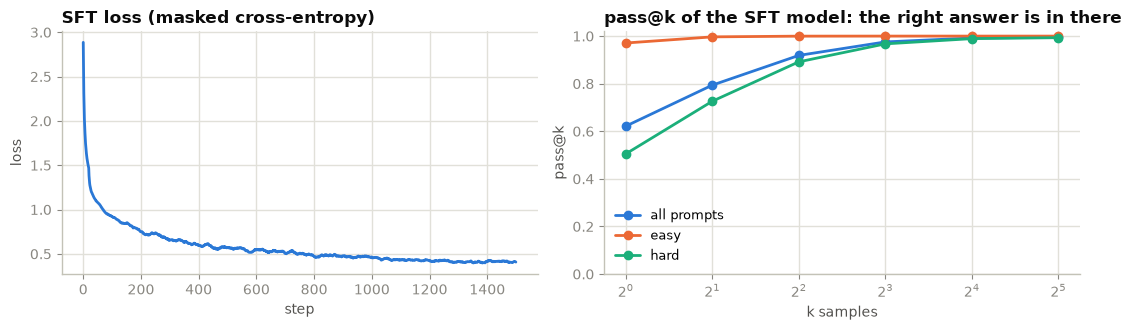

In [112]:
from math import comb

@torch.no_grad()
def evaluate_lm(model, pairs=ALL_PAIRS, n_samples=8, temperature=1.0, greedy=False, gen_fn=None, verify_fn=None):
    '''Sample n completions per prompt. Returns per-prompt correctness matrix (len(pairs), n) and summary dict.'''
    gen_fn, verify_fn = gen_fn or generate, verify_fn or verify
    prompts = torch.tensor([encode_prompt(a, b) for a, b in pairs]).repeat_interleave(n_samples, 0)
    seq, mask = gen_fn(model, prompts, temperature=temperature, greedy=greedy)
    rewards = np.array([verify_fn(a, b, seq[i * n_samples + j, PROMPT_LEN:].tolist()) for i, (a, b) in enumerate(pairs) for j in range(n_samples)])
    R = rewards.reshape(len(pairs), n_samples)
    easy = np.array([is_easy(a, b) for a, b in pairs])
    return R, dict(acc=R.mean(), easy=R[easy].mean(), hard=R[~easy].mean(), length=(mask.sum(1).mean().item()))

def pass_at_k(R, k):
    '''Unbiased pass@k estimator (Chen et al., 2021) from n samples with c correct per prompt.'''
    n = R.shape[1]; c = R.sum(1)
    return np.mean([1.0 - comb(int(n - ci), k) / comb(n, k) if n - ci >= k else 1.0 for ci in c])

R_sft, stats = evaluate_lm(sft_model, n_samples=32)
print("SFT model, sampling at T=1:  accuracy (pass@1) = {acc:.3f}   easy = {easy:.3f}   hard = {hard:.3f}   mean length = {length:.2f}".format(**stats))
_, greedy_stats = evaluate_lm(sft_model, n_samples=1, greedy=True)
print("SFT model, greedy decoding:  accuracy = {acc:.3f}   easy = {easy:.3f}   hard = {hard:.3f}".format(**greedy_stats))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(smooth(sft_losses, 20)); finish(axes[0], "SFT loss (masked cross-entropy)", "step", "loss", legend=False)
ks = [1, 2, 4, 8, 16, 32]
axes[1].plot(ks, [pass_at_k(R_sft, k) for k in ks], marker="o", label="all prompts")
axes[1].plot(ks, [pass_at_k(R_sft[[is_easy(*p) for p in ALL_PAIRS]], k) for k in ks], marker="o", label="easy")
axes[1].plot(ks, [pass_at_k(R_sft[[not is_easy(*p) for p in ALL_PAIRS]], k) for k in ks], marker="o", label="hard")
axes[1].set_xscale("log", base=2); axes[1].set_ylim(0, 1.02)
finish(axes[1], "pass@k of the SFT model: the right answer is in there", "k samples", "pass@k")
plt.tight_layout(); plt.show()

**This plot is the whole motivation for RLVR.** With one sample the SFT model gets a hard prompt right
about half the time; with 8 samples it almost always produces the right answer *somewhere*. The
knowledge is in the model; the sampling distribution is just not concentrated on it. RL with a
verifier takes the samples that happened to be right and makes them more likely. Whether RL can teach
*genuinely new* skills beyond what pass@k reveals is an active research debate (Yue et al., 2025); for our
toy the sharpening view is exactly right.

We'll keep `sft_model` frozen as the **reference policy** $\pi_{\text{ref}}$ for every method that follows.
Let's also look at a few actual samples so the task feels concrete.

In [113]:
def show_samples(model, pairs, n=4, temperature=1.0):
    prompts = torch.tensor([encode_prompt(a, b) for a, b in pairs]).repeat_interleave(n, 0)
    seq, _ = generate(model, prompts, temperature=temperature)
    for i, (a, b) in enumerate(pairs):
        outs = [decode(seq[i * n + j, PROMPT_LEN:]) for j in range(n)]
        marks = ["✓" if verify(a, b, seq[i * n + j, PROMPT_LEN:].tolist()) else "✗" for j in range(n)]
        print(f"{decode(encode_prompt(a, b)):8s} (true {a + b:2d}) : " + "   ".join(f"{o:8s}{m}" for o, m in zip(outs, marks)))
seed_everything(1)
show_samples(sft_model, [(3, 4), (7, 2), (13, 8), (17, 19), (9, 16)])

03+04=   (true  7) : 07<eos> ✗   7<eos>  ✓   7<eos>  ✓   7<eos>  ✓
07+02=   (true  9) : 9<eos>  ✓   9<eos>  ✓   9<eos>  ✓   9<eos>  ✓
13+08=   (true 21) : 21<eos> ✓   21<eos> ✓   21<eos> ✓   21<eos> ✓
17+19=   (true 36) : 36<eos> ✓   42<eos> ✗   42<eos> ✗   36<eos> ✓
09+16=   (true 25) : 29<eos> ✗   25<eos> ✓   25<eos> ✓   25<eos> ✓


### Test your knowledge

In [114]:
register_quiz('10.1',
    "In the LLM-as-MDP view, what is the 'state' at step t?",
    ['The current token only', 'The hidden activations of the last layer', 'The reward received so far', 'The prompt plus all tokens generated so far'],
    '5cfbb5030fa5c86598add9c4836be4f373f7cea083a2cd85f47a068a071be580',
    'VGhlIG5leHQtdG9rZW4gZGlzdHJpYnV0aW9uIGlzIGNvbmRpdGlvbmVkIG9uIHRoZSB3aG9sZSBwcmVmaXgsIHNvIHRoZSBwcmVmaXggaXMgdGhlIHN0YXRlLiBJdCBncm93cyBldmVyeSBzdGVwLCB0aGUgdHJhbnNpdGlvbiBpcyBkZXRlcm1pbmlzdGljIChhcHBlbmQgdGhlIHNhbXBsZWQgdG9rZW4pLCBhbmQgdGhlIE1hcmtvdiBwcm9wZXJ0eSBob2xkcyB0cml2aWFsbHku')
quiz('10.1')

QUIZ 10.1: In the LLM-as-MDP view, what is the 'state' at step t?

   A)  The current token only
   B)  The hidden activations of the last layer
   C)  The reward received so far
   D)  The prompt plus all tokens generated so far

-> put your choice in the answer('10.1', ...) cell below and run it.


In [115]:
answer('10.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [116]:
register_quiz('10.2',
    'Why is the KL penalty to a reference model so central in LLM RL but absent in CartPole?',
    ['Because gamma = 1 for LLMs', 'We start from a strong pretrained policy whose capabilities we must not destroy, and the reward signal is too narrow to define good behaviour on its own', 'LLMs have more parameters', 'CartPole has a discrete action space'],
    'a9075730dfb78b8331db45055493dd86647854cfb2b376207140cdd1e49efc6e',
    'VGhlIHJld2FyZCAoYSByZXdhcmQgbW9kZWwgc2NvcmUsIGEgdW5pdCB0ZXN0KSBjb3ZlcnMgYSBzbGl2ZXIgb2Ygd2hhdCBtYWtlcyBhIHJlc3BvbnNlIGdvb2QuIFVuY29uc3RyYWluZWQgb3B0aW1pc2F0aW9uIGZpbmRzIG91dHB1dHMgdGhhdCBzY29yZSB3ZWxsIGFuZCBhcmUgb3RoZXJ3aXNlIGRlZ2VuZXJhdGUgKHJld2FyZCBoYWNraW5nKS4gU3RheWluZyBjbG9zZSB0byBwaV9yZWYga2VlcHMgdGhlIHJlc3Qgb2YgdGhlIGJlaGF2aW91ciBpbnRhY3QgYW5kIGtlZXBzIHRoZSByZXdhcmQgbW9kZWwncyBpbnB1dHMgaW4tZGlzdHJpYnV0aW9uLg==')
quiz('10.2')

QUIZ 10.2: Why is the KL penalty to a reference model so central in LLM RL but absent in CartPole?

   A)  Because gamma = 1 for LLMs
   B)  We start from a strong pretrained policy whose capabilities we must not destroy, and the reward signal is too narrow to define good behaviour on its own
   C)  LLMs have more parameters
   D)  CartPole has a discrete action space

-> put your choice in the answer('10.2', ...) cell below and run it.


In [117]:
answer('10.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [118]:
register_quiz('10.3',
    'pass@8 is far above pass@1 for the SFT model. What does that tell you about what RL with a verifier can do cheaply?',
    ['That the correct answer already has substantial probability, so RL mainly needs to reallocate probability mass toward it', 'That the model must learn a new algorithm for addition', 'Nothing, they measure different things', 'That greedy decoding is always better'],
    'c8e49e7d0b05c0076610b943b0856d7058be882fda649764f906245b778409a6',
    'SWYgdGhlIG1vZGVsIGNhbiBwcm9kdWNlIHRoZSByaWdodCBhbnN3ZXIgaW4gMSBvZiA4IHNhbXBsZXMsIHRoZSB2ZXJpZmllciB3aWxsIGZpbmQgdGhvc2Ugc2FtcGxlcyBhbmQgdGhlIHBvbGljeSBncmFkaWVudCB3aWxsIHJhaXNlIHRoZWlyIHByb2JhYmlsaXR5LiBUaGlzICdzaGFycGVuaW5nJyBpcyBmYXN0LiBUZWFjaGluZyBza2lsbHMgdGhlIGJhc2UgbW9kZWwgY2Fubm90IHNhbXBsZSBhdCBhbGwgaXMgbXVjaCBoYXJkZXIu')
quiz('10.3')

QUIZ 10.3: pass@8 is far above pass@1 for the SFT model. What does that tell you about what RL with a verifier can do cheaply?

   A)  That the correct answer already has substantial probability, so RL mainly needs to reallocate probability mass toward it
   B)  That the model must learn a new algorithm for addition
   C)  Nothing, they measure different things
   D)  That greedy decoding is always better

-> put your choice in the answer('10.3', ...) cell below and run it.


In [119]:
answer('10.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


---
# Part 11 · Reward models and the Bradley–Terry model

For arithmetic we have a verifier. For "write a helpful, harmless answer" we don't, so RLHF learns a
**reward model** $r_\phi(x, y)$ from human comparisons. Annotators see two responses to a prompt and pick
the better one; the **Bradley–Terry** model turns the scalar reward into a preference probability:

$$P(y_w \succ y_l \mid x) = \sigma\big(r_\phi(x, y_w) - r_\phi(x, y_l)\big), \qquad
\mathcal L_{\text{RM}} = -\mathbb E\big[\log \sigma\big(r_\phi(x, y_w) - r_\phi(x, y_l)\big)\big].$$

The reward model is usually the LM itself (or a copy of it) with a scalar head on the last token.

## A synthetic annotator

We simulate human raters on our arithmetic task. The rater prefers the correct answer 85% of the time
(humans err), and, when both answers are equally right or wrong, prefers the **longer** one 85% of the
time. That second rule is the toy version of a real, well-documented bias: human raters (and LLM
judges) like longer, more elaborate answers. Watch what it does to the learned reward.

In [120]:
class RewardModel(nn.Module):
    '''LM backbone (initialised from the SFT model) + scalar head read at the last generated token.'''
    def __init__(self, init_from):
        super().__init__()
        self.backbone = copy.deepcopy(init_from); self.head = nn.Linear(64, 1)
    def forward(self, seq, mask):
        h = self.backbone.hidden(seq)                                   # (B, L, d)
        last = (PROMPT_LEN + mask.sum(1).long() - 1).clamp(max=seq.shape[1] - 1)
        return self.head(h[torch.arange(len(seq)), last]).squeeze(-1)   # (B,)

def annotator_prefers(a, b, tok_i, tok_j, p_correct=0.85, p_longer=0.85):
    '''Returns True if the simulated rater prefers completion i over j.'''
    ci, cj = verify(a, b, tok_i), verify(a, b, tok_j)
    if ci != cj:
        return (ci > cj) if np.random.rand() < p_correct else (ci < cj)
    li, lj = len(parse_completion(tok_i)[0] or ""), len(parse_completion(tok_j)[0] or "")
    if li != lj:
        return (li > lj) if np.random.rand() < p_longer else (li < lj)
    return np.random.rand() < 0.5

@torch.no_grad()
def sample_completions(model, pairs, n, temperature=1.0, gen_fn=None):
    prompts = torch.tensor([encode_prompt(a, b) for a, b in pairs]).repeat_interleave(n, 0)
    return (gen_fn or generate)(model, prompts, temperature=temperature)

def build_preference_data(model, pairs, n_samples=6, pairs_per_prompt=4):
    '''Sample n completions per prompt and let the annotator label random pairs of DISTINCT completions
    (two identical strings carry no preference information).'''
    seq, mask = sample_completions(model, pairs, n_samples)
    W, Lo, Mw, Ml = [], [], [], []
    for p, (a, b) in enumerate(pairs):
        cands = seq[p * n_samples:(p + 1) * n_samples]
        distinct = [(i, j) for i in range(n_samples) for j in range(i + 1, n_samples) if not torch.equal(cands[i], cands[j])]
        for k in np.random.permutation(len(distinct))[:pairs_per_prompt]:
            i, j = distinct[k]
            si, sj = seq[p * n_samples + i], seq[p * n_samples + j]
            mi, mj = mask[p * n_samples + i], mask[p * n_samples + j]
            if annotator_prefers(a, b, si[PROMPT_LEN:].tolist(), sj[PROMPT_LEN:].tolist()):
                W.append(si); Lo.append(sj); Mw.append(mi); Ml.append(mj)
            else:
                W.append(sj); Lo.append(si); Mw.append(mj); Ml.append(mi)
    return torch.stack(W), torch.stack(Mw), torch.stack(Lo), torch.stack(Ml)

seed_everything(0)
perm = np.random.permutation(len(ALL_PAIRS)); train_pairs = [ALL_PAIRS[i] for i in perm[:320]]; heldout_pairs = [ALL_PAIRS[i] for i in perm[320:]]
pref_train = build_preference_data(sft_model, train_pairs); pref_test = build_preference_data(sft_model, heldout_pairs)
print(f"{len(pref_train[0])} training pairs, {len(pref_test[0])} held-out pairs (different prompts)")

944 training pairs, 252 held-out pairs (different prompts)


In [121]:
def train_reward_model(pref, steps=600, batch_size=64, lr=1e-3):
    rm = RewardModel(sft_model); opt = torch.optim.AdamW(rm.parameters(), lr=lr, weight_decay=0.01)
    W, Mw, L, Ml = pref; losses = []
    for step in range(steps):
        idx = torch.randint(0, len(W), (batch_size,))
        margin = rm(W[idx], Mw[idx]) - rm(L[idx], Ml[idx])
        loss = -F.logsigmoid(margin).mean()                             # Bradley-Terry negative log-likelihood
        opt.zero_grad(); loss.backward(); opt.step(); losses.append(loss.item())
    return rm, losses

@torch.no_grad()
def rm_accuracy(rm, pref):
    W, Mw, L, Ml = pref
    return ((rm(W, Mw) - rm(L, Ml)) > 0).float().mean().item()

[reward model] 9.9s
pairwise accuracy: train 0.861 | held-out prompts 0.615 (the annotator itself is only ~85% consistent, so ~0.85 is the ceiling)


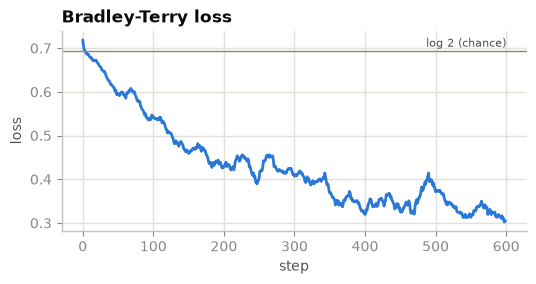

In [122]:
with Timer("reward model"):
    reward_model, rm_losses = train_reward_model(pref_train)
print(f"pairwise accuracy: train {rm_accuracy(reward_model, pref_train):.3f} | held-out prompts {rm_accuracy(reward_model, pref_test):.3f} "
      f"(the annotator itself is only ~85% consistent, so ~0.85 is the ceiling)")
fig, ax = plt.subplots(figsize=(6, 2.6)); ax.plot(smooth(rm_losses, 20)); ax.axhline(math.log(2), color=MUTED, lw=1)
ax.text(len(rm_losses), math.log(2) + 0.01, "log 2 (chance)", ha="right", color=INK2, fontsize=8)
finish(ax, "Bradley-Terry loss", "step", "loss", legend=False); plt.show()

## Optimising against a proxy: best-of-n and Goodhart's law

The simplest way to "optimise" a policy against a reward model is **best-of-n**: sample $n$ responses,
keep the one the RM likes most. It is a real deployment technique (rejection sampling) and a clean
experimental probe, because the KL divergence between best-of-$n$ selection and the base policy has a
closed form, $\mathrm{KL} \approx \log n - \frac{n-1}{n}$, independent of the task.

We measure two things as $n$ grows: the **proxy** reward (what the RM says) and the **true** reward
(what the verifier says). Gao et al. (2022) showed that in real RLHF the true reward eventually peaks and
declines while the proxy keeps rising: the policy finds responses the RM over-values. This is
**Goodhart's law**: "when a measure becomes a target, it ceases to be a good measure."

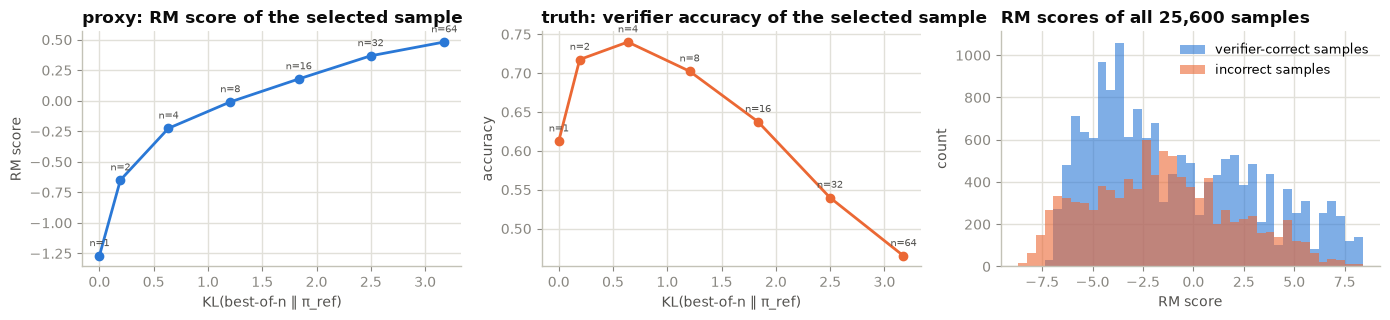

best-of-n table:
  n=  1  KL=0.00  proxy=-1.27  true=0.613
  n=  2  KL=0.19  proxy=-0.65  true=0.718
  n=  4  KL=0.64  proxy=-0.23  true=0.740
  n=  8  KL=1.20  proxy=-0.01  true=0.703
  n= 16  KL=1.84  proxy=+0.18  true=0.637
  n= 32  KL=2.50  proxy=+0.37  true=0.540
  n= 64  KL=3.17  proxy=+0.48  true=0.465
what best-of-64 picks for a few prompts:
  00+00= (true  0) -> 4<eos>   RM score -3.43  verifier 0
  06+17= (true 23) -> 23<eos>  RM score +3.70  verifier 1
  13+01= (true 14) -> 16<eos>  RM score +7.46  verifier 0
  19+19= (true 38) -> 39<eos>  RM score -1.98  verifier 0


In [123]:
seed_everything(0)
N_BON = 64
seq_bon, mask_bon = sample_completions(sft_model, ALL_PAIRS, N_BON)
with torch.no_grad():
    proxy = reward_model(seq_bon, mask_bon).numpy().reshape(len(ALL_PAIRS), N_BON)
true = np.array([verify(a, b, seq_bon[p * N_BON + j, PROMPT_LEN:].tolist()) for p, (a, b) in enumerate(ALL_PAIRS) for j in range(N_BON)]).reshape(len(ALL_PAIRS), N_BON)
lengths = np.array([len(parse_completion(seq_bon[i, PROMPT_LEN:].tolist())[0] or "") for i in range(len(seq_bon))]).reshape(len(ALL_PAIRS), N_BON)

ns = [1, 2, 4, 8, 16, 32, 64]; rows = []
for n in ns:
    best = proxy[:, :n].argmax(1)                                        # index of the RM-preferred sample among the first n
    rows.append(dict(n=n, kl=np.log(n) - (n - 1) / n, proxy=proxy[np.arange(len(ALL_PAIRS)), best].mean(),
                     true=true[np.arange(len(ALL_PAIRS)), best].mean(), length=lengths[np.arange(len(ALL_PAIRS)), best].mean()))
fig, axes = plt.subplots(1, 3, figsize=(14, 3.3))
kls = [r["kl"] for r in rows]
axes[0].plot(kls, [r["proxy"] for r in rows], marker="o"); finish(axes[0], "proxy: RM score of the selected sample", "KL(best-of-n ‖ π_ref)", "RM score", legend=False)
axes[1].plot(kls, [r["true"] for r in rows], marker="o", color=PALETTE[1]); finish(axes[1], "truth: verifier accuracy of the selected sample", "KL(best-of-n ‖ π_ref)", "accuracy", legend=False)
for ax in axes[:2]:
    for r in rows: ax.annotate(f"n={r['n']}", (r["kl"], ax.lines[0].get_ydata()[rows.index(r)]), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=7, color=INK2)
bins = np.linspace(proxy.min(), proxy.max(), 40)
axes[2].hist(proxy[true == 1], bins=bins, alpha=0.6, label="verifier-correct samples", edgecolor="none")
axes[2].hist(proxy[true == 0], bins=bins, alpha=0.6, label="incorrect samples", edgecolor="none")
finish(axes[2], "RM scores of all 25,600 samples", "RM score", "count")
plt.tight_layout(); plt.show()
print("best-of-n table:"); [print(f"  n={r['n']:3d}  KL={r['kl']:.2f}  proxy={r['proxy']:+.2f}  true={r['true']:.3f}") for r in rows]
print("what best-of-64 picks for a few prompts:")
for p in [0, 137, 261, 399]:
    a, b = ALL_PAIRS[p]; j = int(proxy[p].argmax())
    print(f"  {decode(encode_prompt(a, b))} (true {a + b:2d}) -> {decode(seq_bon[p * N_BON + j, PROMPT_LEN:]):8s} RM score {proxy[p, j]:+.2f}  verifier {true[p, j]:.0f}")

The proxy rises monotonically, as it must (we are selecting on it). The true reward rises for small $n$,
peaks, and then **falls**: the textbook Goodhart curve. The right panel shows why. The reward model
separates correct from incorrect samples only partially (it was trained on a few hundred noisy pairs), and
the two score distributions overlap in the upper tail. Mild selection (n = 2–4) mostly picks correct samples;
heavy selection (n = 64) reaches into the tail where the highest-scoring sample for many prompts is a wrong
answer the RM happens to over-value. Real RLHF applies vastly more optimisation pressure than
best-of-64, which is why practitioners (a) keep the KL small, (b) retrain the RM on fresh samples from the
current policy in several rounds, (c) ensemble RMs, and (d) use verifiable rewards whenever they can.

### Test your knowledge

In [124]:
register_quiz('11.1',
    'The Bradley-Terry loss only depends on the DIFFERENCE r(y_w) - r(y_l). What consequence does that have?',
    ['The reward model cannot be trained with gradient descent', 'The absolute scale and offset of the reward are unidentified: adding a per-prompt constant changes nothing, which is fine because the policy gradient only uses differences too', 'It makes the reward model linear', 'It requires exactly two responses per prompt'],
    '8ff888c3f470dbb96ec93890915e51583943f6c38e2058e7e4aa85a7040bf3bf',
    'UHJlZmVyZW5jZXMgb25seSByZXZlYWwgcmVsYXRpdmUgcXVhbGl0eS4gVGhpcyBpcyBhbHNvIHdoeSBEUE8gY2FuIGRyb3AgdGhlIHBhcnRpdGlvbiBmdW5jdGlvbiBaKHgpIChQYXJ0IDEzKSBhbmQgd2h5IEdSUE8gY2FuIHN1YnRyYWN0IHRoZSBncm91cCBtZWFuIChQYXJ0IDE1KTogb25seSBkaWZmZXJlbmNlcyB3aXRoaW4gYSBwcm9tcHQgY2FycnkgaW5mb3JtYXRpb24u')
quiz('11.1')

QUIZ 11.1: The Bradley-Terry loss only depends on the DIFFERENCE r(y_w) - r(y_l). What consequence does that have?

   A)  The reward model cannot be trained with gradient descent
   B)  The absolute scale and offset of the reward are unidentified: adding a per-prompt constant changes nothing, which is fine because the policy gradient only uses differences too
   C)  It makes the reward model linear
   D)  It requires exactly two responses per prompt

-> put your choice in the answer('11.1', ...) cell below and run it.


In [125]:
answer('11.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [126]:
register_quiz('11.2',
    'In the best-of-n experiment, why does the proxy reward keep rising even where the true reward does not?',
    ['Because the verifier is stochastic', 'Selecting the sample with the highest RM score guarantees the score increases with n; if the RM over-values some feature (length), selection finds samples that have that feature whether or not they are correct', 'Because KL grows with n', 'The reward model is trained on the wrong prompts'],
    '695a97022282801beffbba80f12958698a277af88f8b0fc0dd068ebddaf558ae',
    'T3B0aW1pc2F0aW9uIGV4cGxvaXRzIHRoZSBlcnJvcnMgb2YgdGhlIHByb3h5IGluIHByb3BvcnRpb24gdG8gaG93IGhhcmQgaXQgb3B0aW1pc2VzLiBHb29kaGFydCdzIGxhdyBpcyBhIHN0YXRlbWVudCBhYm91dCB0aGUgdGFpbCBvZiBhIGRpc3RyaWJ1dGlvbiwgd2hpY2ggc2VsZWN0aW9uIGFuZCBSTCBib3RoIGV4cGxvcmUgYWdncmVzc2l2ZWx5Lg==')
quiz('11.2')

QUIZ 11.2: In the best-of-n experiment, why does the proxy reward keep rising even where the true reward does not?

   A)  Because the verifier is stochastic
   B)  Selecting the sample with the highest RM score guarantees the score increases with n; if the RM over-values some feature (length), selection finds samples that have that feature whether or not they are correct
   C)  Because KL grows with n
   D)  The reward model is trained on the wrong prompts

-> put your choice in the answer('11.2', ...) cell below and run it.


In [127]:
answer('11.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 11.3 · Bradley–Terry loss with label noise

Implement `bt_loss(r_w, r_l, label_smoothing=0.0)` returning the mean loss over a batch. With label
smoothing $\epsilon$ the target probability that $y_w$ is better becomes $1-\epsilon$, so the loss is
$-(1-\epsilon)\log\sigma(r_w - r_l) - \epsilon \log\sigma(r_l - r_w)$. This is what many production RM
trainers use to cope with annotator noise.

In [128]:
def bt_loss(r_w, r_l, label_smoothing=0.0):
    # YOUR CODE HERE
    raise NotImplementedError

In [129]:
register_exercise('11.3', 'ZGVmIGJ0X2xvc3Mocl93LCByX2wsIGxhYmVsX3Ntb290aGluZz0wLjApOgogICAgbWFyZ2luID0gcl93IC0gcl9sCiAgICByZXR1cm4gKC0oMSAtIGxhYmVsX3Ntb290aGluZykgKiBGLmxvZ3NpZ21vaWQobWFyZ2luKSAtIGxhYmVsX3Ntb290aGluZyAqIEYubG9nc2lnbW9pZCgtbWFyZ2luKSkubWVhbigp')

def _tests(fn):
    r_w, r_l = torch.tensor([2.0, 0.0]), torch.tensor([0.0, 1.0])
    out = fn(r_w, r_l)
    assert out is not None and out.dim() == 0, "return a scalar"
    exp = -(F.logsigmoid(torch.tensor(2.0)) + F.logsigmoid(torch.tensor(-1.0))) / 2
    assert torch.isclose(out, exp, atol=1e-6), f"expected {exp.item():.4f}, got {out.item():.4f}"
    out2 = fn(r_w, r_l, label_smoothing=0.1)
    exp2 = (-(0.9 * F.logsigmoid(r_w - r_l) + 0.1 * F.logsigmoid(r_l - r_w))).mean()
    assert torch.isclose(out2, exp2, atol=1e-6), "label smoothing is wrong"

check('11.3', bt_loss, _tests)
# solution('11.3')   # <- uncomment to reveal the reference solution

[11.3] not implemented yet. Fill in the cell above (or run solution('11.3')).


---
# Part 12 · RLHF with PPO

The classic RLHF objective (Ziegler et al., 2019; Ouyang et al., 2022) is

$$\max_\theta\; \mathbb E_{x \sim \mathcal D,\, y \sim \pi_\theta(\cdot|x)}\big[\, r(x, y)\,\big] \;-\; \beta\, \mathbb E_x\big[\mathrm{KL}\big(\pi_\theta(\cdot|x)\,\|\,\pi_{\text{ref}}(\cdot|x)\big)\big].$$

Implemented with PPO over tokens:

1. Sample a response per prompt from the current policy.
2. Score it with the reward function (RM or verifier) to get one scalar $R$.
3. Turn it into **per-token rewards**: $r_t = -\beta\big(\log\pi_\theta(a_t|s_t) - \log\pi_{\text{ref}}(a_t|s_t)\big)$ for
   every token, plus $R$ on the final token. The KL penalty becomes part of the reward the critic must predict.
4. Compute GAE advantages over tokens with a **value model** (a second LM with a scalar head) and $\gamma = 1$.
5. Run PPO's clipped update over tokens for a couple of epochs.

That is four large models in memory at once (policy, reference, critic, reward model), which is the main
reason critic-free methods (Parts 14–16) took over for reasoning models.

## Building it

In [130]:
class Critic(nn.Module):
    '''Value model: LM backbone + scalar head, one value per prefix position.'''
    def __init__(self, init_from):
        super().__init__()
        self.backbone = copy.deepcopy(init_from); self.head = nn.Linear(64, 1)
    def forward(self, seq):                        # (B, L) -> V for the prefix ending at each position: (B, L)
        return self.head(self.backbone.hidden(seq)).squeeze(-1)

def shape_rewards(final_reward, logp, ref_logp, mask, beta):
    '''Per-token rewards: -beta * (log pi - log pi_ref) on every real token, plus the final reward on the last real token.'''
    rewards = -beta * (logp - ref_logp) * mask
    last = (mask.sum(1).long() - 1).clamp(min=0)
    rewards[torch.arange(len(mask)), last] += final_reward
    return rewards

def gae_tokens(rewards, values, mask, gamma=1.0, lam=0.95):
    '''GAE over completion tokens. values[:, t] = V(prefix before token t). Terminal after the last real token.'''
    B, T = rewards.shape; adv = torch.zeros(B, T); last = torch.zeros(B)
    for t in reversed(range(T)):
        next_v = values[:, t + 1] * mask[:, t + 1] if t + 1 < T else torch.zeros(B)   # V = 0 after the last real token
        delta = rewards[:, t] + gamma * next_v - values[:, t]
        last = (delta + gamma * lam * last) * mask[:, t]        # the mask is a prefix, so this resets the recursion at padding
        adv[:, t] = last
    return adv, (adv + values) * mask

def batch_prompts(pairs, n_samples):
    return torch.tensor([encode_prompt(a, b) for a, b in pairs]).repeat_interleave(n_samples, 0)

def batch_rewards(pairs, n_samples, seq, reward_fn):
    return torch.tensor([reward_fn(a, b, seq[i * n_samples + j]) for i, (a, b) in enumerate(pairs) for j in range(n_samples)], dtype=torch.float32)

verifier_reward = lambda a, b, seq: verify(a, b, seq[PROMPT_LEN:].tolist())

In [131]:
def make_ppo_llm_step(policy, ref, critic, reward_fn=verifier_reward, n_samples=8, beta=0.02, clip=0.2,
                      epochs=2, minibatch=128, lr=3e-4, lr_v=1e-3, vf_coef=0.5, lam=0.95, gen_fn=None):
    opt = torch.optim.Adam(policy.parameters(), lr=lr); opt_v = torch.optim.Adam(critic.parameters(), lr=lr_v)
    gen_fn = gen_fn or generate
    def step(pairs):
        prompts = batch_prompts(pairs, n_samples)
        seq, mask = gen_fn(policy, prompts)                                   # 1. sample
        R = batch_rewards(pairs, n_samples, seq, reward_fn)                   # 2. score
        with torch.no_grad():
            old_logp = completion_logprobs(policy, seq); ref_logp = completion_logprobs(ref, seq)
            values = critic(seq[:, :-1])[:, PROMPT_LEN - 1:]                  # V(prefix) aligned with each completion token
            rewards = shape_rewards(R, old_logp, ref_logp, mask, beta)        # 3. per-token rewards with KL penalty
            adv, ret = gae_tokens(rewards, values, mask, lam=lam)             # 4. GAE over tokens
        N = len(seq); stats = defaultdict(list)
        for _ in range(epochs):                                               # 5. PPO epochs
            perm = torch.randperm(N)
            for s in range(0, N, minibatch):
                idx = perm[s:s + minibatch]; m = mask[idx]
                mb_adv = adv[idx]; mb_adv = (mb_adv - mb_adv[m > 0].mean()) / (mb_adv[m > 0].std() + 1e-8)
                logp = completion_logprobs(policy, seq[idx]); ratio = torch.exp(logp - old_logp[idx])
                pg = -torch.min(ratio * mb_adv, torch.clamp(ratio, 1 - clip, 1 + clip) * mb_adv)
                pg_loss = (pg * m).sum() / m.sum()
                v_pred = critic(seq[idx][:, :-1])[:, PROMPT_LEN - 1:]
                v_loss = (((v_pred - ret[idx]) ** 2) * m).sum() / m.sum()
                opt.zero_grad(); pg_loss.backward(); nn.utils.clip_grad_norm_(policy.parameters(), 1.0); opt.step()
                opt_v.zero_grad(); (vf_coef * v_loss).backward(); opt_v.step()
                stats["clipfrac"].append((((ratio - 1).abs() > clip).float() * m).sum().item() / m.sum().item())
        with torch.no_grad():
            ent = -(completion_logprobs(policy, seq) * mask).sum() / mask.sum()   # mean negative log-prob of sampled tokens (an entropy proxy)
        return dict(reward=R.mean().item(), kl=((old_logp - ref_logp) * mask).sum(1).mean().item(),
                    length=mask.sum(1).mean().item(), nll=ent.item(), clipfrac=float(np.mean(stats["clipfrac"])))
    return step

def train_llm_rl(step_fn, policy, steps=120, batch_size=32, eval_every=10, gen_fn=None, verify_fn=None, extra_eval=None, verbose=True):
    '''Generic driver: sample a batch of prompts, call step_fn, log, periodically evaluate on all prompts.'''
    log = defaultdict(list)
    for step in range(steps):
        pairs = [ALL_PAIRS[i] for i in np.random.choice(len(ALL_PAIRS), batch_size, replace=False)]
        for k, v in step_fn(pairs).items(): log[k].append(v)
        if step % eval_every == 0 or step == steps - 1:
            _, ev = evaluate_lm(policy, n_samples=4, gen_fn=gen_fn, verify_fn=verify_fn)
            log["eval_step"].append(step); log["eval_acc"].append(ev["acc"]); log["eval_easy"].append(ev["easy"]); log["eval_hard"].append(ev["hard"])
            if extra_eval is not None:
                for k, v in extra_eval(policy).items(): log[k].append(v)
            if verbose and (step % (eval_every * 4) == 0 or step == steps - 1):
                print(f"  step {step:4d} | batch reward {np.mean(log['reward'][-eval_every:]):.3f} | eval acc {ev['acc']:.3f} "
                      f"(easy {ev['easy']:.2f}, hard {ev['hard']:.2f}) | KL {np.mean(log['kl'][-eval_every:]):.3f} | len {np.mean(log['length'][-eval_every:]):.2f}")
    return log

In [132]:
seed_everything(0)
policy_ppo = copy.deepcopy(sft_model); critic_ppo = Critic(sft_model)
ppo_llm_step = make_ppo_llm_step(policy_ppo, sft_model, critic_ppo)
with Timer("PPO-RLHF (verifier reward)"):
    log_ppo_llm = train_llm_rl(ppo_llm_step, policy_ppo)
llm_results = {"PPO (critic + KL reward)": log_ppo_llm}

  step    0 | batch reward 0.555 | eval acc 0.657 (easy 0.97, hard 0.55) | KL 0.000 | len 2.84


  step   40 | batch reward 0.964 | eval acc 0.961 (easy 0.98, hard 0.95) | KL 0.464 | len 2.84


  step   80 | batch reward 0.980 | eval acc 0.983 (easy 0.99, hard 0.98) | KL 0.577 | len 2.87


  step  119 | batch reward 0.983 | eval acc 0.989 (easy 0.99, hard 0.99) | KL 0.604 | len 2.84
[PPO-RLHF (verifier reward)] 20.2s


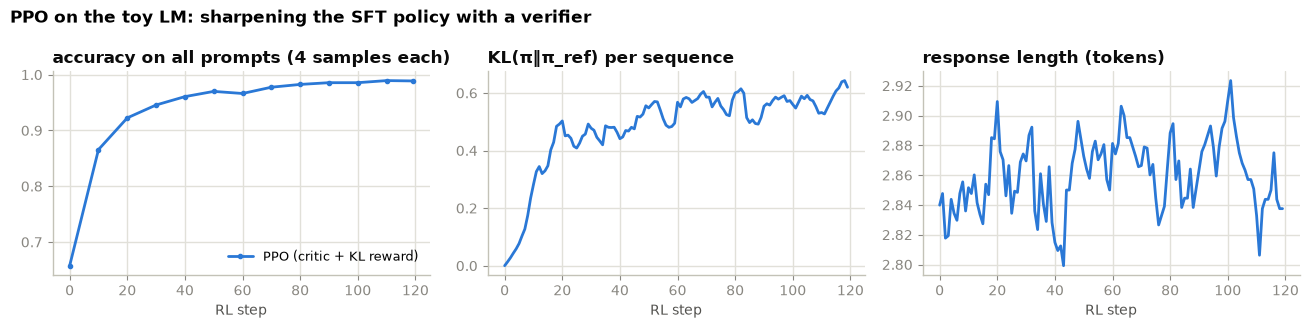

In [133]:
def plot_llm_runs(results, title="", keys=("eval_acc", "kl", "length"), titles=("accuracy on all prompts (4 samples each)", "KL(π‖π_ref) per sequence", "response length (tokens)")):
    fig, axes = plt.subplots(1, len(keys), figsize=(4.4 * len(keys), 3.3))
    for name, log in results.items():
        for ax, key in zip(axes, keys):
            if key.startswith("eval"): ax.plot(log["eval_step"], log[key], marker="o", ms=3, label=name)
            else: ax.plot(smooth(log[key], 5), label=name)
    for ax, t in zip(axes, titles): finish(ax, t, "RL step", None, legend=(ax is axes[0]))
    if title: fig.suptitle(title, x=0.01, ha="left", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()

plot_llm_runs(llm_results, "PPO on the toy LM: sharpening the SFT policy with a verifier")

Accuracy climbs from the SFT level toward 100% while the KL to the reference grows slowly: the policy
concentrates probability on answers it could already produce. The response length stays put because the
verifier does not reward verbosity. Now let's optimise against the **reward model** from Part 11 instead
and watch the same run through two lenses: the proxy it optimises and the truth.

[PPO-RLHF (reward-model reward)] 56.5s


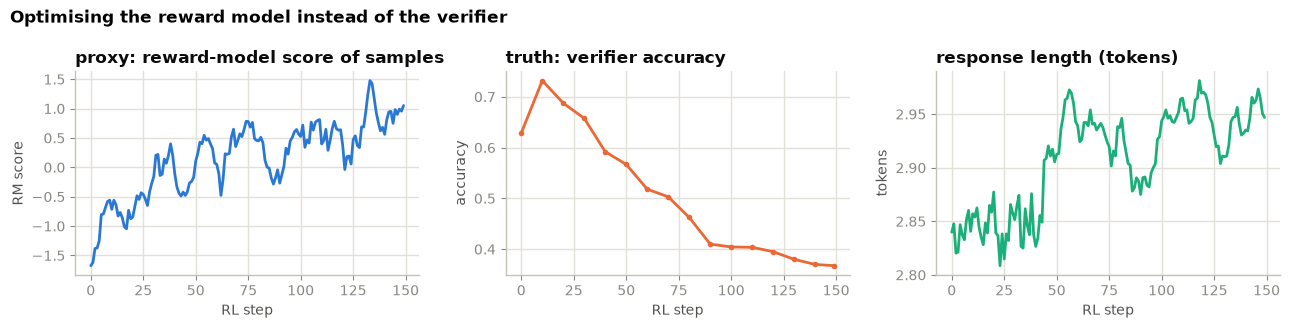

samples from the RM-optimised policy:
03+04=   (true  7) : 18<eos> ✗   18<eos> ✗   18<eos> ✗   18<eos> ✗
02+05=   (true  7) : 15<eos> ✗   15<eos> ✗   15<eos> ✗   15<eos> ✗
13+08=   (true 21) : 21<eos> ✓   20<eos> ✗   28<eos> ✗   28<eos> ✗
17+19=   (true 36) : 35<eos> ✗   35<eos> ✗   35<eos> ✗   35<eos> ✗


In [134]:
@torch.no_grad()
def rm_reward_factory(rm):
    def rm_reward(a, b, seq):
        m = torch.zeros(1, MAX_NEW)
        toks = seq[PROMPT_LEN:].tolist(); n = next((i + 1 for i, t in enumerate(toks) if t == EOS), MAX_NEW); m[0, :n] = 1
        return rm(seq[None], m).item()
    return rm_reward

seed_everything(0)
policy_rm = copy.deepcopy(sft_model); critic_rm = Critic(sft_model)
rm_reward = rm_reward_factory(reward_model)
rm_step = make_ppo_llm_step(policy_rm, sft_model, critic_rm, reward_fn=rm_reward, beta=0.01)
with Timer("PPO-RLHF (reward-model reward)"):
    log_rm = train_llm_rl(rm_step, policy_rm, steps=150, verbose=False)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
axes[0].plot(smooth(log_rm["reward"], 5), color=PALETTE[0]); finish(axes[0], "proxy: reward-model score of samples", "RL step", "RM score", legend=False)
axes[1].plot(log_rm["eval_step"], log_rm["eval_acc"], marker="o", ms=3, color=PALETTE[1]); finish(axes[1], "truth: verifier accuracy", "RL step", "accuracy", legend=False)
axes[2].plot(smooth(log_rm["length"], 5), color=PALETTE[2]); finish(axes[2], "response length (tokens)", "RL step", "tokens", legend=False)
plt.suptitle("Optimising the reward model instead of the verifier", x=0.01, ha="left", fontsize=12, fontweight="bold"); plt.tight_layout(); plt.show()
seed_everything(2); print("samples from the RM-optimised policy:"); show_samples(policy_rm, [(3, 4), (2, 5), (13, 8), (17, 19)])

The proxy climbs while the truth collapses. Look at the samples: the policy has drifted to strings the
reward model never saw in training (a lone digit, or malformed outputs containing `=` or `+`), which the RM
scores highly by *extrapolation*. Nothing in the Bradley–Terry loss constrains scores off the training
distribution, and the policy gradient is an efficient search for exactly those inputs. Compare with the SFT
samples in Part 10. In production RLHF this is the failure mode people mean by "reward hacking", and it
is why every recipe since has combined a learned reward with a KL leash (we used a small β = 0.01 here on
purpose), verifiers, or both.

### Test your knowledge

In [135]:
register_quiz('12.1',
    'Why is the KL penalty put INTO the per-token reward rather than added as a separate loss term?',
    ['It is not; PPO always adds it as a loss', 'It is cheaper to compute', 'Because PPO cannot have two loss terms', 'So the critic learns to predict it and GAE distributes it over tokens; the policy is then optimised against a single consistent objective (reward minus KL)'],
    '1caaa4dfec41552752b7f7f42ecb3827ddf49c99b4cc5670c3e5bf269a1a6046',
    'Qm90aCBwbGFjZW1lbnRzIGV4aXN0LiBSZXdhcmQgc2hhcGluZyAoT3BlbkFJJ3Mgb3JpZ2luYWwgcmVjaXBlKSBmb2xkcyB0aGUgY29uc3RyYWludCBpbnRvIHRoZSByZXR1cm4gc28gY3JlZGl0IGFzc2lnbm1lbnQgaGFuZGxlcyBpdDsgR1JQTyBpbnN0ZWFkIGFkZHMgYSBLTCB0ZXJtIHRvIHRoZSBsb3NzIGRpcmVjdGx5IChQYXJ0IDE1KS4gRWFjaCBjaG9pY2UgaGFzIGl0cyBvd24gYmlhcy92YXJpYW5jZSB0cmFkZS1vZmZzLg==')
quiz('12.1')

QUIZ 12.1: Why is the KL penalty put INTO the per-token reward rather than added as a separate loss term?

   A)  It is not; PPO always adds it as a loss
   B)  It is cheaper to compute
   C)  Because PPO cannot have two loss terms
   D)  So the critic learns to predict it and GAE distributes it over tokens; the policy is then optimised against a single consistent objective (reward minus KL)

-> put your choice in the answer('12.1', ...) cell below and run it.


In [136]:
answer('12.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [137]:
register_quiz('12.2',
    'In PPO-RLHF the critic predicts the value of a text prefix. Why is this harder than predicting the value of a CartPole state?',
    ['Because gamma = 1', "The reward is a single sparse scalar at the end of a long sequence, and the 'state' is a whole prefix whose future depends on subtle wording, so the value regression is noisy and needs a model as large as the policy", 'Text is discrete', "It isn't harder"],
    'bec725f1fb5a5c061a09d09a3d27e1f51f87d047ba3e3794437706e18dc85e7d',
    'QSB2YWx1ZSBtb2RlbCBmb3IgbGFuZ3VhZ2UgaXMgZXNzZW50aWFsbHkgYW5vdGhlciBMTE0gdGhhdCBtdXN0IGp1ZGdlIHBhcnRpYWwgcmVzcG9uc2VzLiBJdCBpcyBleHBlbnNpdmUsIGFuZCBpdHMgZXJyb3JzIGluamVjdCBiaWFzIGludG8gZXZlcnkgYWR2YW50YWdlLiBUaGlzIGlzIHRoZSBjb3JlIG1vdGl2YXRpb24gZm9yIEdSUE8gYW5kIFJMT08ncyBNb250ZSBDYXJsbyBiYXNlbGluZXMu')
quiz('12.2')

QUIZ 12.2: In PPO-RLHF the critic predicts the value of a text prefix. Why is this harder than predicting the value of a CartPole state?

   A)  Because gamma = 1
   B)  The reward is a single sparse scalar at the end of a long sequence, and the 'state' is a whole prefix whose future depends on subtle wording, so the value regression is noisy and needs a model as large as the policy
   C)  Text is discrete
   D)  It isn't harder

-> put your choice in the answer('12.2', ...) cell below and run it.


In [138]:
answer('12.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [139]:
register_quiz('12.3',
    'Which set of models must be held in memory for classic PPO-RLHF?',
    ['Policy, reference policy, critic (value model), and reward model', 'Policy only', 'Policy and critic', 'Policy and reward model'],
    'a884932f9d09ad046e7d9bc8ef98ddf5a195b9a26982d9bf784dbfd138d29e08',
    'Rm91ciBtb2RlbHMsIHR3byBvZiB3aGljaCAocG9saWN5LCBjcml0aWMpIGFyZSB0cmFpbmVkLiBXaXRoIDcwQi1wYXJhbWV0ZXIgbW9kZWxzIHRoaXMgZG9taW5hdGVzIHRoZSBlbmdpbmVlcmluZy4gR1JQTyBkcm9wcyB0aGUgY3JpdGljOyBSTFZSIHJlcGxhY2VzIHRoZSByZXdhcmQgbW9kZWwgYnkgYSBwcm9ncmFtOyBEUE8gZHJvcHMgYm90aCBwbHVzIHRoZSBzYW1wbGluZyBsb29wLg==')
quiz('12.3')

QUIZ 12.3: Which set of models must be held in memory for classic PPO-RLHF?

   A)  Policy, reference policy, critic (value model), and reward model
   B)  Policy only
   C)  Policy and critic
   D)  Policy and reward model

-> put your choice in the answer('12.3', ...) cell below and run it.


In [140]:
answer('12.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 12.4 · Per-token reward shaping

Implement `my_shape_rewards(final_reward, logp, ref_logp, mask, beta)` from scratch. `logp`, `ref_logp`, `mask`
are `(B, T)` tensors; `final_reward` is `(B,)`. Every real token gets $-\beta(\log\pi - \log\pi_{\text{ref}})$;
the **last real token** of each sequence additionally gets the final reward. Padding tokens get exactly 0.

In [141]:
def my_shape_rewards(final_reward, logp, ref_logp, mask, beta):
    # YOUR CODE HERE
    raise NotImplementedError

In [142]:
register_exercise('12.4', 'ZGVmIG15X3NoYXBlX3Jld2FyZHMoZmluYWxfcmV3YXJkLCBsb2dwLCByZWZfbG9ncCwgbWFzaywgYmV0YSk6CiAgICByID0gLWJldGEgKiAobG9ncCAtIHJlZl9sb2dwKSAqIG1hc2sKICAgIGxhc3QgPSAobWFzay5zdW0oMSkubG9uZygpIC0gMSkuY2xhbXAobWluPTApCiAgICByW3RvcmNoLmFyYW5nZShsZW4obWFzaykpLCBsYXN0XSArPSBmaW5hbF9yZXdhcmQKICAgIHJldHVybiBy')

def _tests(fn):
    logp = torch.tensor([[-1.0, -2.0, -3.0], [-0.5, -0.5, -0.5]]); ref = torch.tensor([[-1.5, -2.0, -2.0], [-1.0, -1.0, -1.0]])
    mask = torch.tensor([[1.0, 1.0, 0.0], [1.0, 1.0, 1.0]]); R = torch.tensor([1.0, 0.0])
    out = fn(R, logp, ref, mask, beta=0.1)
    exp = torch.tensor([[-0.1 * 0.5, -0.1 * 0.0 + 1.0, 0.0], [-0.05, -0.05, -0.05]])
    assert out is not None and torch.allclose(out, exp, atol=1e-6), f"expected {exp.tolist()}, got {out.tolist()}"

check('12.4', my_shape_rewards, _tests)
# solution('12.4')   # <- uncomment to reveal the reference solution

[12.4] not implemented yet. Fill in the cell above (or run solution('12.4')).


---
# Part 13 · DPO: direct preference optimisation

PPO-RLHF is a lot of machinery just to nudge a model toward what humans prefer. **DPO** (Rafailov et al.,
2023) noticed that the RLHF objective has a *closed-form* solution, and that plugging it back into the
Bradley–Terry model gives a loss you can minimise on preference pairs directly. No reward model, no
sampling, no critic.

## The derivation in four lines

1. The KL-regularised objective $\max_\pi \mathbb E_{y\sim\pi}[r(x,y)] - \beta\,\mathrm{KL}(\pi\|\pi_{\text{ref}})$
   is maximised by the Gibbs distribution
   $$\pi^*(y|x) = \frac{1}{Z(x)}\, \pi_{\text{ref}}(y|x)\, \exp\!\big(r(x,y)/\beta\big).$$
2. Solve for the reward: $r(x,y) = \beta \log \dfrac{\pi^*(y|x)}{\pi_{\text{ref}}(y|x)} + \beta \log Z(x)$.
3. Plug into Bradley–Terry. The intractable $Z(x)$ **cancels** because both responses share the prompt:
   $$P(y_w \succ y_l) = \sigma\!\Big(\beta \log \frac{\pi^*(y_w|x)}{\pi_{\text{ref}}(y_w|x)} - \beta \log \frac{\pi^*(y_l|x)}{\pi_{\text{ref}}(y_l|x)}\Big).$$
4. Replace $\pi^*$ by $\pi_\theta$ and maximise the likelihood of the observed preferences:
   $$\mathcal L_{\text{DPO}}(\theta) = -\mathbb E\Big[\log \sigma\Big(\beta \big[\underbrace{\log\tfrac{\pi_\theta(y_w|x)}{\pi_{\text{ref}}(y_w|x)}}_{\text{implicit reward of } y_w} - \log\tfrac{\pi_\theta(y_l|x)}{\pi_{\text{ref}}(y_l|x)}\big]\Big)\Big].$$

The gradient weights each pair by $\sigma(\hat r_l - \hat r_w)$: pairs the implicit reward model gets
*wrong* get the largest updates. $\beta$ plays the same role as in RLHF (how far from the reference we are
allowed to go).

## DPO on our task

We build preference pairs the cheap way: sample completions from the SFT model and let the *verifier*
label a correct one as chosen and an incorrect one as rejected. That is the "offline RLVR" setting
several 2025 papers explored; with human labels the code is identical.

In [143]:
def sequence_logprob(model, seq, mask):
    return (completion_logprobs(model, seq) * mask).sum(1)

def dpo_loss(policy, ref, W, Mw, L, Ml, beta=0.1):
    pi_w, pi_l = sequence_logprob(policy, W, Mw), sequence_logprob(policy, L, Ml)
    with torch.no_grad():
        ref_w, ref_l = sequence_logprob(ref, W, Mw), sequence_logprob(ref, L, Ml)
    margin = beta * ((pi_w - ref_w) - (pi_l - ref_l))          # difference of implicit rewards
    loss = -F.logsigmoid(margin).mean()
    return loss, dict(margin=margin.mean().item(), pref_acc=(margin > 0).float().mean().item(),
                      logp_chosen=pi_w.mean().item(), logp_rejected=pi_l.mean().item())

def build_verifier_pairs(model, pairs, n_samples=8, max_pairs=4):
    '''chosen = a correct sample, rejected = an incorrect sample of the same prompt.'''
    seq, mask = sample_completions(model, pairs, n_samples)
    W, Mw, L, Ml = [], [], [], []
    for p, (a, b) in enumerate(pairs):
        idx = range(p * n_samples, (p + 1) * n_samples)
        good = [i for i in idx if verify(a, b, seq[i, PROMPT_LEN:].tolist())]; bad = [i for i in idx if i not in good]
        for _ in range(min(max_pairs, len(good), len(bad))):
            i, j = np.random.choice(good), np.random.choice(bad)
            W.append(seq[i]); Mw.append(mask[i]); L.append(seq[j]); Ml.append(mask[j])
    return torch.stack(W), torch.stack(Mw), torch.stack(L), torch.stack(Ml)

seed_everything(0)
dpo_pairs = build_verifier_pairs(sft_model, ALL_PAIRS)
print(f"{len(dpo_pairs[0])} preference pairs; example chosen/rejected: {decode(dpo_pairs[0][0])} / {decode(dpo_pairs[2][0])}")

761 preference pairs; example chosen/rejected: 00+02=2<eos> / 00+02=02<eos>


In [144]:
def train_dpo(pairs_data, steps=300, batch_size=64, beta=0.1, lr=2e-4, eval_every=20):
    policy = copy.deepcopy(sft_model); opt = torch.optim.Adam(policy.parameters(), lr=lr)
    W, Mw, L, Ml = pairs_data; log = defaultdict(list)
    for step in range(steps):
        idx = torch.randint(0, len(W), (batch_size,))
        loss, info = dpo_loss(policy, sft_model, W[idx], Mw[idx], L[idx], Ml[idx], beta)
        opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(policy.parameters(), 1.0); opt.step()
        for k, v in info.items(): log[k].append(v)
        if step % eval_every == 0 or step == steps - 1:
            _, ev = evaluate_lm(policy, n_samples=4)
            log["eval_step"].append(step); log["eval_acc"].append(ev["acc"]); log["eval_easy"].append(ev["easy"]); log["eval_hard"].append(ev["hard"])
    return policy, log

  β = 0.1: accuracy 0.648 -> 0.823  (easy 0.48, hard 0.94) | final log π: chosen -0.34, rejected -19.70


  β = 0.3: accuracy 0.648 -> 0.875  (easy 0.69, hard 0.94) | final log π: chosen -0.21, rejected -14.30


  β = 1.0: accuracy 0.648 -> 0.917  (easy 0.89, hard 0.93) | final log π: chosen -0.11, rejected -8.66
[DPO (three values of β)] 24.6s


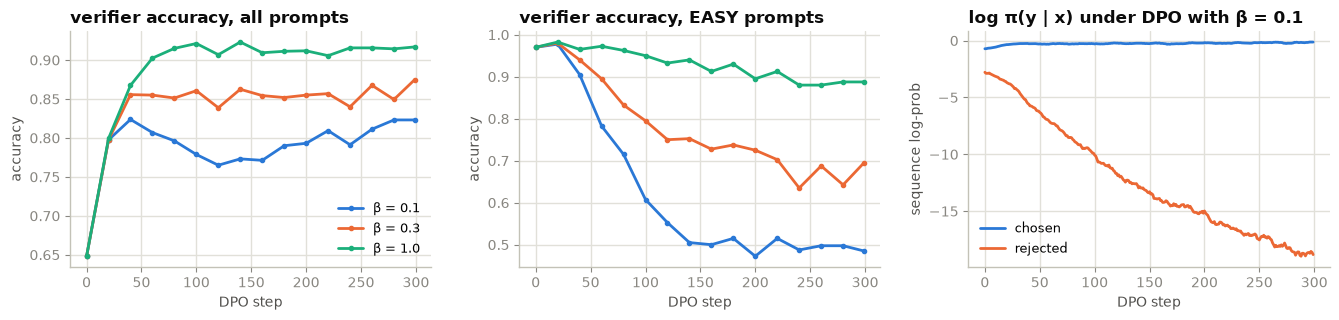

samples from the β = 0.1 policy on easy prompts:
02+05=   (true  7) : 1<eos>  ✗   1<eos>  ✗   1<eos>  ✗   1<eos>  ✗
09+09=   (true 18) : 14<eos> ✗   18<eos> ✓   14<eos> ✗   14<eos> ✗
03+04=   (true  7) : 7<eos>  ✓   7<eos>  ✓   7<eos>  ✓   7<eos>  ✓


In [145]:
dpo_runs = {}
with Timer("DPO (three values of β)"):
    for beta in [0.1, 0.3, 1.0]:
        seed_everything(0)
        dpo_runs[beta] = train_dpo(dpo_pairs, beta=beta)
        pol, lg = dpo_runs[beta]
        print(f"  β = {beta}: accuracy {lg['eval_acc'][0]:.3f} -> {lg['eval_acc'][-1]:.3f}  (easy {lg['eval_easy'][-1]:.2f}, hard {lg['eval_hard'][-1]:.2f}) "
              f"| final log π: chosen {lg['logp_chosen'][-1]:.2f}, rejected {lg['logp_rejected'][-1]:.2f}")
policy_dpo, log_dpo = dpo_runs[1.0]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.3))
for beta, (pol, lg) in dpo_runs.items():
    axes[0].plot(lg["eval_step"], lg["eval_acc"], marker="o", ms=3, label=f"β = {beta}")
    axes[1].plot(lg["eval_step"], lg["eval_easy"], marker="o", ms=3, label=f"β = {beta}")
finish(axes[0], "verifier accuracy, all prompts", "DPO step", "accuracy")
finish(axes[1], "verifier accuracy, EASY prompts", "DPO step", "accuracy", legend=False)
lg = dpo_runs[0.1][1]
axes[2].plot(smooth(lg["logp_chosen"], 10), label="chosen"); axes[2].plot(smooth(lg["logp_rejected"], 10), label="rejected")
finish(axes[2], "log π(y | x) under DPO with β = 0.1", "DPO step", "sequence log-prob")
plt.tight_layout(); plt.show()
seed_everything(1); print("samples from the β = 0.1 policy on easy prompts:"); show_samples(dpo_runs[0.1][0], [(2, 5), (9, 9), (3, 4)])

**DPO can over-optimise, and β is the leash.** With the textbook β = 0.1 the hard prompts improve but the
*easy* ones collapse: look at the samples, the model starts emitting empty or truncated answers. The right
panel explains why. DPO only cares about the *gap* between chosen and rejected, and the cheapest way to
widen it is to drive the rejected sequences to log-probabilities of −20 and below. With only a few
hundred easy-prompt pairs to anchor it, the probability mass that leaves the rejected answers does not go
to the chosen ones (whose log-prob is already ≈ 0) but to *unseen* strings. This is **likelihood
displacement** (Razin et al., 2024), a well-documented DPO failure mode, and a large β (a tighter KL leash)
or early stopping prevents it. Production runs use β ≈ 0.1 with learning rates a thousand times smaller
than ours, which amounts to the same thing: a small total policy change.

## The DPO family

| Method | Loss idea | Needs $\pi_{\text{ref}}$? | Notes |
|---|---|---|---|
| **DPO** (2023) | $-\log\sigma(\beta\,\Delta)$, $\Delta$ = chosen-minus-rejected difference of $\log\frac{\pi_\theta}{\pi_{\text{ref}}}$ | yes | the baseline; sensitive to over-fitting on small data |
| **IPO** (Azar et al., 2023) | $(\Delta - \tfrac{1}{2\beta})^2$ | yes | bounded target instead of pushing the margin to ∞; more robust to deterministic preferences |
| **KTO** (Ethayarajh et al., 2024) | prospect-theory utility on *unpaired* good/bad examples | yes | uses thumbs-up/down data, no pairs required |
| **SimPO** (Meng et al., 2024) | length-normalised log-prob as the reward, plus a target margin $\gamma$ | **no** | cheaper, fights length bias, popular for open models |
| **ORPO** (Hong et al., 2024) | odds-ratio penalty added to the SFT loss | no | single-stage SFT + alignment |
| **Online / iterative DPO** | sample from the current policy, label with an RM or verifier, DPO step, repeat | yes | recovers most of the benefit of on-policy RL |

The offline methods share one limitation: they can only reinforce responses that already exist in the
dataset. On-policy RL (Parts 12, 14–17) generates its own data, explores, and finds behaviours no
annotator wrote down. Empirically, for reasoning tasks on-policy RL wins; for cheap alignment of
chat models, DPO-style methods are often good enough and far simpler to run.

### Test your knowledge

In [146]:
register_quiz('13.1',
    'Why can DPO drop the partition function Z(x) that appears in the optimal policy?',
    ['It is estimated with a critic', 'Both responses in a pair share the same prompt, so log Z(x) appears in both implicit rewards and cancels in their difference', 'Z(x) is always 1', 'Because beta is small'],
    '025568c6d0b9b75927b2bb843e6347a47cdaa686d58fe9a7108fc314300976b8',
    'VGhpcyBjYW5jZWxsYXRpb24gaXMgdGhlIHdob2xlIHRyaWNrLiBJdCBpcyBhbHNvIHdoeSBEUE8gbmVlZHMgUEFJUlMgKG9yIGEgcmVmZXJlbmNlIHBvaW50IHBlciBwcm9tcHQpOiBhbiBhYnNvbHV0ZSByZXdhcmQgZm9yIGEgc2luZ2xlIHJlc3BvbnNlIHdvdWxkIHN0aWxsIGNvbnRhaW4gdGhlIGludHJhY3RhYmxlIFooeCku')
quiz('13.1')

QUIZ 13.1: Why can DPO drop the partition function Z(x) that appears in the optimal policy?

   A)  It is estimated with a critic
   B)  Both responses in a pair share the same prompt, so log Z(x) appears in both implicit rewards and cancels in their difference
   C)  Z(x) is always 1
   D)  Because beta is small

-> put your choice in the answer('13.1', ...) cell below and run it.


In [147]:
answer('13.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [148]:
register_quiz('13.2',
    "What is the 'implicit reward' in DPO?",
    ['log pi_theta(y|x)', "The reward model's output", 'beta * log( pi_theta(y|x) / pi_ref(y|x) )', "The verifier's score"],
    'b90d43e767c604898416edfbaf4fe0d0c83c76f961f8c014af397207075f5a1d',
    'RFBPIHRyYWlucyB0aGUgcG9saWN5IHNvIHRoYXQgdGhpcyBxdWFudGl0eSBiZWhhdmVzIGxpa2UgYSBCcmFkbGV5LVRlcnJ5IHJld2FyZCBvbiB0aGUgcHJlZmVyZW5jZSBkYXRhLiBZb3UgY2FuIGV2ZW4gdXNlIGEgRFBPLXRyYWluZWQgbW9kZWwgYXMgYSByZXdhcmQgbW9kZWwgYnkgcmVhZGluZyBvZmYgdGhpcyByYXRpby4=')
quiz('13.2')

QUIZ 13.2: What is the 'implicit reward' in DPO?

   A)  log pi_theta(y|x)
   B)  The reward model's output
   C)  beta * log( pi_theta(y|x) / pi_ref(y|x) )
   D)  The verifier's score

-> put your choice in the answer('13.2', ...) cell below and run it.


In [149]:
answer('13.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [150]:
register_quiz('13.3',
    'Compared with on-policy RL (PPO/GRPO), the main limitation of offline DPO is:',
    ['It requires verifiable rewards', "It only ever sees the fixed dataset's responses, so it cannot discover and reinforce new behaviours that the current policy would generate", 'It needs a critic', 'It cannot use a reference model'],
    '98ab182ad63af5cc71126db3a2a34c3e9addbbe1daf95067305e198343baac29',
    'RGlzdHJpYnV0aW9uIHNoaWZ0OiBhcyB0aGUgcG9saWN5IGNoYW5nZXMsIHRoZSBkYXRhc2V0J3MgcmVzcG9uc2VzIGJlY29tZSBzdGFsZS4gSXRlcmF0aXZlL29ubGluZSBEUE8gYWRkcmVzc2VzIHRoaXMgYnkgcmVnZW5lcmF0aW5nIGRhdGEsIGF0IHdoaWNoIHBvaW50IHlvdSBhcmUgbW9zdCBvZiB0aGUgd2F5IGJhY2sgdG8gUkwu')
quiz('13.3')

QUIZ 13.3: Compared with on-policy RL (PPO/GRPO), the main limitation of offline DPO is:

   A)  It requires verifiable rewards
   B)  It only ever sees the fixed dataset's responses, so it cannot discover and reinforce new behaviours that the current policy would generate
   C)  It needs a critic
   D)  It cannot use a reference model

-> put your choice in the answer('13.3', ...) cell below and run it.


In [151]:
answer('13.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 13.4 · DPO loss from log-probabilities

Implement `my_dpo_loss(pi_w, pi_l, ref_w, ref_l, beta)` given four `(B,)` tensors of **sequence**
log-probabilities (policy and reference, chosen and rejected). Return the mean loss.

In [152]:
def my_dpo_loss(pi_w, pi_l, ref_w, ref_l, beta=0.1):
    # YOUR CODE HERE
    raise NotImplementedError

In [153]:
register_exercise('13.4', 'ZGVmIG15X2Rwb19sb3NzKHBpX3csIHBpX2wsIHJlZl93LCByZWZfbCwgYmV0YT0wLjEpOgogICAgbWFyZ2luID0gYmV0YSAqICgocGlfdyAtIHJlZl93KSAtIChwaV9sIC0gcmVmX2wpKQogICAgcmV0dXJuIC1GLmxvZ3NpZ21vaWQobWFyZ2luKS5tZWFuKCk=')

def _tests(fn):
    pi_w, pi_l = torch.tensor([-1.0, -2.0]), torch.tensor([-3.0, -1.0])
    ref_w, ref_l = torch.tensor([-1.5, -2.0]), torch.tensor([-2.5, -2.0])
    out = fn(pi_w, pi_l, ref_w, ref_l, 0.5)
    margin = 0.5 * ((pi_w - ref_w) - (pi_l - ref_l))
    exp = -F.logsigmoid(margin).mean()
    assert out is not None and torch.isclose(out, exp, atol=1e-6), f"expected {exp.item():.4f}, got {out.item():.4f}"

check('13.4', my_dpo_loss, _tests)
# solution('13.4')   # <- uncomment to reveal the reference solution

[13.4] not implemented yet. Fill in the cell above (or run solution('13.4')).


---
# Part 14 · Critic-free policy gradients: RLOO and REINFORCE++

Look again at what PPO-RLHF does with its critic. The "environment" is deterministic, the reward is
one number at the end, and we can sample as many responses per prompt as we like. In that setting the
Monte Carlo return is *exact* (it's just $R$), so the critic exists only to provide a **baseline**.
Ahmadian et al. (2024, "Back to Basics") argued that a well-chosen baseline plus plain REINFORCE is as
good as PPO for LLMs and far simpler. The sequence-level policy gradient is

$$\nabla_\theta J = \mathbb E\Big[(R(y) - b)\, \nabla_\theta \log \pi_\theta(y|x)\Big], \qquad \log\pi_\theta(y|x) = \sum_t \log \pi_\theta(y_t \mid x, y_{<t}).$$

## RLOO: REINFORCE leave-one-out

Sample $K$ responses $y_1..y_K$ for the same prompt and use the **mean of the other $K-1$ rewards** as the
baseline for each one:

$$A_i = R_i - \frac{1}{K-1}\sum_{j \ne i} R_j .$$

Because $b_i$ does not depend on $y_i$, the estimator stays unbiased (Part 7), and it adapts to the
prompt's difficulty automatically. The KL penalty is folded into the sequence reward:
$R_i \leftarrow R_i - \beta\, \mathrm{KL}_i$.

## REINFORCE++

Hu (2025) kept PPO's *token-level* clipped objective but removed the critic: per-token rewards with the
KL shaping of Part 12, reward-to-go advantages (with $\gamma = 1$ the advantage of every token is just
the sequence's total shaped reward from that token on), and **normalisation over the whole batch** rather
than per prompt. Its "-baseline" variant additionally subtracts each prompt's mean reward first, like RLOO.
The clip makes it safe to take a couple of epochs per batch.

In [154]:
def make_rloo_step(policy, ref, reward_fn=verifier_reward, n_samples=8, beta=0.02, lr=3e-4, gen_fn=None):
    opt = torch.optim.Adam(policy.parameters(), lr=lr); gen_fn = gen_fn or generate
    def step(pairs):
        prompts = batch_prompts(pairs, n_samples)
        seq, mask = gen_fn(policy, prompts)
        R = batch_rewards(pairs, n_samples, seq, reward_fn)
        with torch.no_grad():
            old_logp = completion_logprobs(policy, seq); ref_logp = completion_logprobs(ref, seq)
            kl_seq = ((old_logp - ref_logp) * mask).sum(1)
            R_shaped = (R - beta * kl_seq).view(-1, n_samples)                       # KL penalty inside the reward
            baseline = (R_shaped.sum(1, keepdim=True) - R_shaped) / (n_samples - 1)  # leave-one-out mean
            adv = (R_shaped - baseline).reshape(-1)
        logp_seq = (completion_logprobs(policy, seq) * mask).sum(1)                   # log pi(y|x)
        loss = -(adv * logp_seq).mean()                                               # one REINFORCE step
        opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(policy.parameters(), 1.0); opt.step()
        return dict(reward=R.mean().item(), kl=kl_seq.mean().item(), length=mask.sum(1).mean().item())
    return step

def make_reinforce_pp_step(policy, ref, reward_fn=verifier_reward, n_samples=8, beta=0.02, clip=0.2, lr=3e-4,
                           epochs=2, minibatch=128, prompt_baseline=True, gen_fn=None):
    opt = torch.optim.Adam(policy.parameters(), lr=lr); gen_fn = gen_fn or generate
    def step(pairs):
        prompts = batch_prompts(pairs, n_samples)
        seq, mask = gen_fn(policy, prompts)
        R = batch_rewards(pairs, n_samples, seq, reward_fn)
        with torch.no_grad():
            old_logp = completion_logprobs(policy, seq); ref_logp = completion_logprobs(ref, seq)
            if prompt_baseline:                                                       # REINFORCE++-baseline
                R = (R.view(-1, n_samples) - R.view(-1, n_samples).mean(1, keepdim=True)).reshape(-1)
            rewards = shape_rewards(R, old_logp, ref_logp, mask, beta)
            adv = torch.flip(torch.cumsum(torch.flip(rewards, [1]), 1), [1]) * mask      # reward-to-go, gamma = 1
            valid = mask > 0
            adv = (adv - adv[valid].mean()) / (adv[valid].std() + 1e-8) * mask           # global batch normalisation
        N = len(seq)
        for _ in range(epochs):
            perm = torch.randperm(N)
            for s in range(0, N, minibatch):
                idx = perm[s:s + minibatch]; m = mask[idx]
                ratio = torch.exp(completion_logprobs(policy, seq[idx]) - old_logp[idx])
                pg = -torch.min(ratio * adv[idx], torch.clamp(ratio, 1 - clip, 1 + clip) * adv[idx])
                loss = (pg * m).sum() / m.sum()
                opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(policy.parameters(), 1.0); opt.step()
        return dict(reward=batch_rewards(pairs, n_samples, seq, reward_fn).mean().item(),
                    kl=((old_logp - ref_logp) * mask).sum(1).mean().item(), length=mask.sum(1).mean().item())
    return step

  step    0 | batch reward 0.527 | eval acc 0.641 (easy 0.97, hard 0.53) | KL 0.000 | len 2.85


  step   40 | batch reward 0.902 | eval acc 0.911 (easy 0.98, hard 0.89) | KL 0.327 | len 2.84


  step   80 | batch reward 0.954 | eval acc 0.959 (easy 0.99, hard 0.95) | KL 0.482 | len 2.86


  step  119 | batch reward 0.972 | eval acc 0.978 (easy 0.99, hard 0.97) | KL 0.539 | len 2.84
[RLOO] 8.3s


  step    0 | batch reward 0.527 | eval acc 0.671 (easy 0.99, hard 0.56) | KL 0.000 | len 2.85


  step   40 | batch reward 0.955 | eval acc 0.964 (easy 0.98, hard 0.96) | KL 0.488 | len 2.84


  step   80 | batch reward 0.984 | eval acc 0.971 (easy 0.99, hard 0.96) | KL 0.572 | len 2.86


  step  119 | batch reward 0.987 | eval acc 0.978 (easy 0.99, hard 0.97) | KL 0.597 | len 2.84
[REINFORCE++] 12.1s


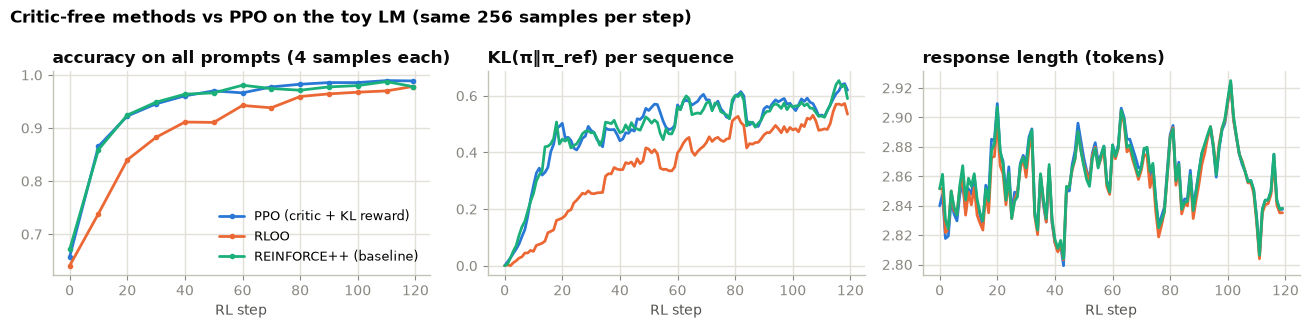

In [155]:
seed_everything(0)
policy_rloo = copy.deepcopy(sft_model)
with Timer("RLOO"):
    log_rloo = train_llm_rl(make_rloo_step(policy_rloo, sft_model), policy_rloo)
seed_everything(0)
policy_rpp = copy.deepcopy(sft_model)
with Timer("REINFORCE++"):
    log_rpp = train_llm_rl(make_reinforce_pp_step(policy_rpp, sft_model), policy_rpp)
llm_results["RLOO"] = log_rloo; llm_results["REINFORCE++ (baseline)"] = log_rpp
plot_llm_runs(llm_results, "Critic-free methods vs PPO on the toy LM (same 256 samples per step)")

On this task the critic-free methods match or beat PPO, at a fraction of the cost: no value model, no
GAE, and one forward pass fewer per step. This is the empirical finding that drove the field toward
GRPO-style algorithms in 2024–25.

### Test your knowledge

In [156]:
register_quiz('14.1',
    'Why is the leave-one-out baseline unbiased while using the mean of ALL K rewards (including R_i itself) is not?',
    ['A valid baseline must be independent of the action being scored; R_i depends on y_i, so including it correlates the baseline with the sample and biases the gradient (by a factor (K-1)/K, as it turns out)', 'The full mean has higher variance', 'Both are biased', 'The leave-one-out mean is always larger'],
    'b641fe886fbf72db88ebf12f81a6ad45414c00382486e6cf83ddb177c2765fcf',
    'RVtncmFkIGxvZyBwaSh5X2kpICogZih5X2kpXSBpcyBub3QgemVybyBmb3IgYSBmdW5jdGlvbiBvZiB5X2kuIFdpdGggdGhlIGZ1bGwgbWVhbiB0aGUgYmlhcyBpcyBhIGNvbnN0YW50IHJlc2NhbGluZyBvZiB0aGUgZ3JhZGllbnQsIHdoaWNoIGlzIHdoeSBHUlBPICh3aGljaCB1c2VzIHRoZSBmdWxsLWdyb3VwIG1lYW4pIHN0aWxsIHdvcmtzIGluIHByYWN0aWNlLg==')
quiz('14.1')

QUIZ 14.1: Why is the leave-one-out baseline unbiased while using the mean of ALL K rewards (including R_i itself) is not?

   A)  A valid baseline must be independent of the action being scored; R_i depends on y_i, so including it correlates the baseline with the sample and biases the gradient (by a factor (K-1)/K, as it turns out)
   B)  The full mean has higher variance
   C)  Both are biased
   D)  The leave-one-out mean is always larger

-> put your choice in the answer('14.1', ...) cell below and run it.


In [157]:
answer('14.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [158]:
register_quiz('14.2',
    'REINFORCE++ normalises advantages over the entire batch, RLOO/GRPO per prompt. What is a consequence of per-prompt normalisation?',
    ['The batch must contain a single prompt', 'It requires a critic', 'Prompts where all samples get the same reward contribute no gradient at all', 'Per-prompt normalisation is biased'],
    '57e1d162b25e4a32ddb0bb96b8992f79b64cad0c86535bf0497f1e31dc294ecb',
    'SWYgZXZlcnkgc2FtcGxlIG9mIGEgcHJvbXB0IHNjb3JlcyAwICh0b28gaGFyZCkgb3IgMSAodG9vIGVhc3kpLCB0aGUgcGVyLXByb21wdCBhZHZhbnRhZ2VzIGFyZSBhbGwgemVyby4gVGhhdCB3YXN0ZXMgY29tcHV0ZSBhbmQgaXMgdGhlIG1vdGl2YXRpb24gZm9yIERBUE8ncyBkeW5hbWljIHNhbXBsaW5nIChQYXJ0IDE2KS4=')
quiz('14.2')

QUIZ 14.2: REINFORCE++ normalises advantages over the entire batch, RLOO/GRPO per prompt. What is a consequence of per-prompt normalisation?

   A)  The batch must contain a single prompt
   B)  It requires a critic
   C)  Prompts where all samples get the same reward contribute no gradient at all
   D)  Per-prompt normalisation is biased

-> put your choice in the answer('14.2', ...) cell below and run it.


In [159]:
answer('14.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 14.3 · RLOO advantages

Implement `rloo_advantages(R, K)` where `R` is a `(B,)` tensor of rewards ordered so that consecutive
blocks of `K` entries belong to the same prompt. Return the `(B,)` tensor of leave-one-out advantages.

In [160]:
def rloo_advantages(R, K):
    # YOUR CODE HERE
    raise NotImplementedError

In [161]:
register_exercise('14.3', 'ZGVmIHJsb29fYWR2YW50YWdlcyhSLCBLKToKICAgIFJnID0gUi52aWV3KC0xLCBLKQogICAgYmFzZWxpbmUgPSAoUmcuc3VtKDEsIGtlZXBkaW09VHJ1ZSkgLSBSZykgLyAoSyAtIDEpCiAgICByZXR1cm4gKFJnIC0gYmFzZWxpbmUpLnJlc2hhcGUoLTEp')

def _tests(fn):
    R = torch.tensor([1.0, 0.0, 0.0, 1.0,   1.0, 1.0, 1.0, 0.0])
    out = fn(R, 4)
    exp = torch.tensor([1 - 1/3, 0 - 2/3, 0 - 2/3, 1 - 1/3,   1 - 2/3, 1 - 2/3, 1 - 2/3, 0 - 1.0])
    assert out is not None and torch.allclose(out, exp, atol=1e-6), f"expected {exp.tolist()}, got {out.tolist()}"

check('14.3', rloo_advantages, _tests)
# solution('14.3')   # <- uncomment to reveal the reference solution

[14.3] not implemented yet. Fill in the cell above (or run solution('14.3')).


---
# Part 15 · GRPO: group relative policy optimisation

GRPO (Shao et al., 2024, DeepSeekMath) is the algorithm behind DeepSeek-R1 and, in modified form, most
open reasoning models of 2025. It is PPO with the critic replaced by a **group baseline**:

1. For each prompt $x$, sample a group of $G$ responses $\{y_1, \dots, y_G\}$ from the old policy.
2. Score them, $R_i$, and compute **group-normalised advantages**
   $$\hat A_i = \frac{R_i - \operatorname{mean}(R_1..R_G)}{\operatorname{std}(R_1..R_G)},$$
   shared by every token of $y_i$.
3. Take PPO's clipped objective per token, average over each response's tokens, then over the group,
   and subtract a KL penalty **in the loss** using the unbiased, always-positive "k3" estimator:
   $$\mathcal J_{\text{GRPO}} = \frac{1}{G}\sum_{i=1}^{G} \frac{1}{|y_i|} \sum_{t=1}^{|y_i|}
   \Big[\min\big(\rho_{i,t}\hat A_i,\; \text{clip}(\rho_{i,t}, 1-\epsilon, 1+\epsilon)\hat A_i\big)
   - \beta\, \mathbb D_{i,t}\Big], \qquad
   \mathbb D_{i,t} = \frac{\pi_{\text{ref}}}{\pi_\theta} - \log\frac{\pi_{\text{ref}}}{\pi_\theta} - 1 .$$

That's it. Compared with PPO-RLHF it needs no value model and no GAE, and the baseline is a
Monte Carlo estimate of $V(x)$ computed from the group itself. The division by the group std is
GRPO's distinctive (and controversial, see Part 16) choice: it turns every prompt's rewards into
z-scores, so a lone correct answer among 8 failures gets a huge advantage.

**DeepSeek-R1's recipe on top of GRPO** was almost embarrassingly simple: rule-based rewards only
(accuracy + a format reward for `<think>...</think>` tags), no neural reward model, thousands of steps,
and the reasoning chains grew on their own ("aha moments"). The lesson was that the algorithm matters
less than having a verifiable reward and enough compute.

  step    0 | batch reward 0.527 | eval acc 0.641 (easy 0.97, hard 0.53) | KL 0.000 | len 2.85


  step   40 | batch reward 0.895 | eval acc 0.910 (easy 0.99, hard 0.88) | KL 0.305 | len 2.84


  step   80 | batch reward 0.952 | eval acc 0.954 (easy 0.99, hard 0.94) | KL 0.461 | len 2.86


  step  119 | batch reward 0.968 | eval acc 0.976 (easy 0.99, hard 0.97) | KL 0.520 | len 2.84
[GRPO] 8.1s


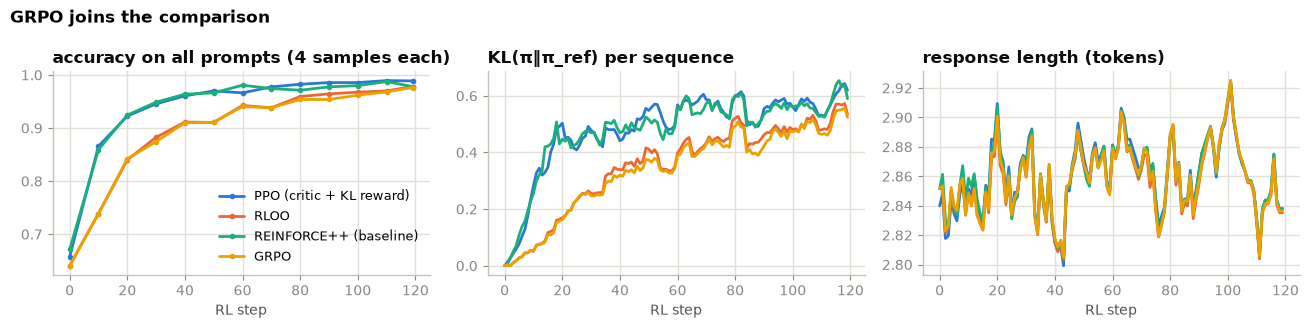

In [162]:
def group_advantages(R, G, normalize_std=True, eps=1e-4):
    '''R: (B,) rewards in blocks of G per prompt -> (B,) advantages.'''
    Rg = R.view(-1, G)
    adv = Rg - Rg.mean(1, keepdim=True)
    if normalize_std:
        adv = adv / (Rg.std(1, keepdim=True) + eps)
    return adv.reshape(-1)

def make_grpo_step(policy, ref, reward_fn=verifier_reward, n_samples=8, clip=0.2, beta=0.04, lr=3e-4,
                   epochs=1, normalize_std=True, gen_fn=None):
    opt = torch.optim.Adam(policy.parameters(), lr=lr); gen_fn = gen_fn or generate
    def step(pairs):
        prompts = batch_prompts(pairs, n_samples)
        seq, mask = gen_fn(policy, prompts)                                   # 1. sample a group per prompt
        R = batch_rewards(pairs, n_samples, seq, reward_fn)                   # 2. score
        adv = group_advantages(R, n_samples, normalize_std)[:, None]          #    group-relative advantages (B, 1)
        with torch.no_grad():
            old_logp = completion_logprobs(policy, seq); ref_logp = completion_logprobs(ref, seq)
        for _ in range(epochs):                                               # 3. clipped objective + KL in the loss
            logp = completion_logprobs(policy, seq)
            ratio = torch.exp(logp - old_logp)
            surrogate = torch.min(ratio * adv, torch.clamp(ratio, 1 - clip, 1 + clip) * adv)
            kl = torch.exp(ref_logp - logp) - (ref_logp - logp) - 1           # k3 estimator of KL(pi_theta || pi_ref), per token
            per_token = surrogate - beta * kl
            loss = -((per_token * mask).sum(1) / mask.sum(1)).mean()          # 1/|y_i| inside, 1/G outside
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(policy.parameters(), 1.0); opt.step()
        Rg = R.view(-1, n_samples)
        return dict(reward=R.mean().item(), kl=((old_logp - ref_logp) * mask).sum(1).mean().item(), length=mask.sum(1).mean().item(),
                    dead_groups=(Rg.std(1) == 0).float().mean().item(), entropy=-(old_logp * mask).sum().item() / mask.sum().item())
    return step

seed_everything(0)
policy_grpo = copy.deepcopy(sft_model)
with Timer("GRPO"):
    log_grpo = train_llm_rl(make_grpo_step(policy_grpo, sft_model), policy_grpo)
llm_results["GRPO"] = log_grpo
plot_llm_runs(llm_results, "GRPO joins the comparison")

prompt 14+17=  (true answer 31), SFT policy samples:
  31<eos>  reward 1   advantage: GRPO +0.54   mean-only +0.25
  31<eos>  reward 1   advantage: GRPO +0.54   mean-only +0.25
  39<eos>  reward 0   advantage: GRPO -1.62   mean-only -0.75
  31<eos>  reward 1   advantage: GRPO +0.54   mean-only +0.25
  24<eos>  reward 0   advantage: GRPO -1.62   mean-only -0.75
  31<eos>  reward 1   advantage: GRPO +0.54   mean-only +0.25
  31<eos>  reward 1   advantage: GRPO +0.54   mean-only +0.25
  31<eos>  reward 1   advantage: GRPO +0.54   mean-only +0.25


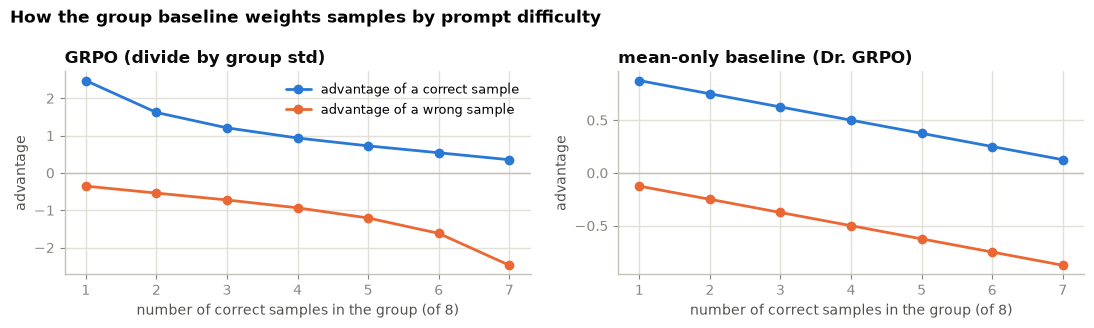

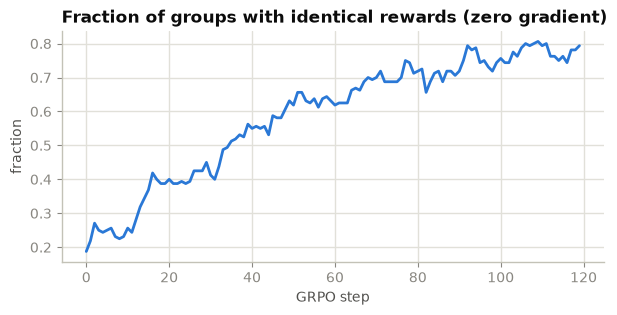

In [163]:
# Look inside one group: samples, rewards, and the advantages GRPO assigns.
seed_everything(5)
a, b = 14, 17
prompts = batch_prompts([(a, b)], 8); seq, mask = generate(sft_model, prompts)
R = batch_rewards([(a, b)], 8, seq, verifier_reward)
adv_std, adv_mean = group_advantages(R, 8, True), group_advantages(R, 8, False)
print(f"prompt {decode(encode_prompt(a, b))}  (true answer {a + b}), SFT policy samples:")
for i in range(8):
    print(f"  {decode(seq[i, PROMPT_LEN:]):8s} reward {R[i]:.0f}   advantage: GRPO {adv_std[i]:+.2f}   mean-only {adv_mean[i]:+.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
ks = np.arange(1, 8)                                                 # number of correct samples in a group of 8
for normalize, ax, title in [(True, axes[0], "GRPO (divide by group std)"), (False, axes[1], "mean-only baseline (Dr. GRPO)")]:
    a_correct = [group_advantages(torch.tensor([1.0] * k + [0.0] * (8 - k)), 8, normalize)[0].item() for k in ks]
    a_wrong = [group_advantages(torch.tensor([1.0] * k + [0.0] * (8 - k)), 8, normalize)[-1].item() for k in ks]
    ax.plot(ks, a_correct, marker="o", label="advantage of a correct sample"); ax.plot(ks, a_wrong, marker="o", label="advantage of a wrong sample")
    ax.axhline(0, color=AXIS, lw=1); finish(ax, title, "number of correct samples in the group (of 8)", "advantage", legend=(ax is axes[0]))
plt.suptitle("How the group baseline weights samples by prompt difficulty", x=0.01, ha="left", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(smooth(log_grpo["dead_groups"], 5)); finish(ax, "Fraction of groups with identical rewards (zero gradient)", "GRPO step", "fraction", legend=False)
plt.show()

Two things to take from these plots:

* **Std-normalisation is a difficulty weighting.** With one correct sample out of eight, GRPO gives it an
  advantage of about +2.5 and each wrong one −0.35; with seven correct, the roles flip. Mean-only
  advantages are symmetric and much smaller for lopsided groups. GRPO therefore pushes hardest on
  prompts the model almost never (or almost always) solves, which Dr. GRPO argues is a *bias* rather than a
  feature (Part 16).
* **Dead groups grow as the model improves.** Once most prompts are solved 8/8 the batch is mostly zero
  advantage: compute spent on samples that teach nothing. This is why DAPO resamples until the batch is full
  of informative groups, and why real training curricula keep feeding harder problems.

### Test your knowledge

In [164]:
register_quiz('15.1',
    'What replaces the critic in GRPO?',
    ['A reward model', "The mean (and std) of the rewards of the other samples in the same prompt's group, a Monte Carlo estimate of the prompt's value", 'Nothing; GRPO has no baseline', 'A moving average of all rewards'],
    '27f3d37b96c6e28fbde434502bcbc97f3178614c98097723d572e54cabe872c6',
    'U2FtcGxpbmcgRyByZXNwb25zZXMgcGVyIHByb21wdCBnaXZlcyBhIGZyZWUgZXN0aW1hdGUgb2YgVih4KS4gSXQgY29zdHMgZXh0cmEgc2FtcGxpbmcgaW5zdGVhZCBvZiBhbiBleHRyYSBtb2RlbCwgYW5kIHNhbXBsaW5nIGlzIGNoZWFwIHJlbGF0aXZlIHRvIHRyYWluaW5nIGEgdmFsdWUgTE0gb2YgdGhlIHNhbWUgc2l6ZS4=')
quiz('15.1')

QUIZ 15.1: What replaces the critic in GRPO?

   A)  A reward model
   B)  The mean (and std) of the rewards of the other samples in the same prompt's group, a Monte Carlo estimate of the prompt's value
   C)  Nothing; GRPO has no baseline
   D)  A moving average of all rewards

-> put your choice in the answer('15.1', ...) cell below and run it.


In [165]:
answer('15.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [166]:
register_quiz('15.2',
    "GRPO's KL term uses the estimator pi_ref/pi_theta - log(pi_ref/pi_theta) - 1. Why this form instead of the plain log-ratio log(pi_theta/pi_ref)?",
    ['It is an unbiased estimator of KL that is always non-negative and has much lower variance than the log-ratio sample, whose expectation is KL only after averaging many samples of both signs', 'The plain log-ratio is biased', 'It is cheaper to compute', 'It is the exact KL'],
    '61b775e12164598ec40db50897a42f9611aebc3663779e28235f716c2aa195c5',
    'Qm90aCBhcmUgdW5iaWFzZWQgZm9yIEtMKHBpX3RoZXRhIHx8IHBpX3JlZikgdW5kZXIgc2FtcGxlcyBmcm9tIHBpX3RoZXRhLCBidXQgdGhlIHBsYWluIGxvZy1yYXRpbyBrMSA9IGxvZyhwaS9waV9yZWYpIHRha2VzIGJvdGggc2lnbnMgYW5kIGlzIG5vaXN5OyBrMyA9IHIgLSBsb2cgciAtIDEgKHdpdGggciA9IHBpX3JlZi9waSkgaXMgPj0gMCBhbmQgbG93LXZhcmlhbmNlIChTY2h1bG1hbidzICdhcHByb3hpbWF0aW5nIEtMJyBub3RlKS4=')
quiz('15.2')

QUIZ 15.2: GRPO's KL term uses the estimator pi_ref/pi_theta - log(pi_ref/pi_theta) - 1. Why this form instead of the plain log-ratio log(pi_theta/pi_ref)?

   A)  It is an unbiased estimator of KL that is always non-negative and has much lower variance than the log-ratio sample, whose expectation is KL only after averaging many samples of both signs
   B)  The plain log-ratio is biased
   C)  It is cheaper to compute
   D)  It is the exact KL

-> put your choice in the answer('15.2', ...) cell below and run it.


In [167]:
answer('15.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [168]:
register_quiz('15.3',
    'With G = 8 samples, a prompt the model solves exactly once gets advantages of roughly +2.5 (correct) and -0.35 (each wrong). What does this imply for training dynamics?',
    ['The KL penalty is ignored', 'Easy prompts dominate the gradient', "Prompts near the edge of the model's ability get large gradient signal, while prompts solved 0/8 or 8/8 contribute nothing", 'The policy becomes deterministic immediately'],
    '3d0e79e4819eafd6dc4ac8c9e32042186cfd4aef55fdded8405d69084794701a',
    'R1JQTyBpbXBsaWNpdGx5IGltcGxlbWVudHMgYSBjdXJyaWN1bHVtIGZvY3VzZWQgb24gJ2p1c3QgYmFyZWx5IHNvbHZhYmxlJyBwcm9tcHRzLiBJdHMgc3RkIG5vcm1hbGlzYXRpb24gYW1wbGlmaWVzIHRoaXM7IERyLiBHUlBPIHJlbW92ZXMgdGhlIGFtcGxpZmljYXRpb24sIGFuZCBEQVBPIHJlbW92ZXMgdGhlIHVuaW5mb3JtYXRpdmUgZ3JvdXBzIGVudGlyZWx5Lg==')
quiz('15.3')

QUIZ 15.3: With G = 8 samples, a prompt the model solves exactly once gets advantages of roughly +2.5 (correct) and -0.35 (each wrong). What does this imply for training dynamics?

   A)  The KL penalty is ignored
   B)  Easy prompts dominate the gradient
   C)  Prompts near the edge of the model's ability get large gradient signal, while prompts solved 0/8 or 8/8 contribute nothing
   D)  The policy becomes deterministic immediately

-> put your choice in the answer('15.3', ...) cell below and run it.


In [169]:
answer('15.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 15.4 · k3 KL estimator

Implement `k3_kl(logp, ref_logp)` returning the per-token estimate $\frac{\pi_{\text{ref}}}{\pi_\theta} - \log\frac{\pi_{\text{ref}}}{\pi_\theta} - 1$
from log-probability tensors of the same shape. It must be non-negative everywhere and zero when the two agree.

In [170]:
def k3_kl(logp, ref_logp):
    # YOUR CODE HERE
    raise NotImplementedError

In [171]:
register_exercise('15.4', 'ZGVmIGszX2tsKGxvZ3AsIHJlZl9sb2dwKToKICAgIGxvZ19yYXRpbyA9IHJlZl9sb2dwIC0gbG9ncAogICAgcmV0dXJuIHRvcmNoLmV4cChsb2dfcmF0aW8pIC0gbG9nX3JhdGlvIC0gMQ==')

def _tests(fn):
    lp, rp = torch.tensor([-1.0, -2.0, -0.5]), torch.tensor([-1.0, -1.0, -1.5])
    out = fn(lp, rp)
    exp = torch.exp(rp - lp) - (rp - lp) - 1
    assert out is not None and torch.allclose(out, exp, atol=1e-6), f"expected {exp.tolist()}, got {out.tolist()}"
    assert (out >= 0).all() and torch.isclose(out[0], torch.tensor(0.0)), "must be >= 0 and zero when equal"

check('15.4', k3_kl, _tests)
# solution('15.4')   # <- uncomment to reveal the reference solution

[15.4] not implemented yet. Fill in the cell above (or run solution('15.4')).


---
# Part 16 · After GRPO: the 2025–2026 landscape

GRPO's success triggered a wave of papers that each fixed one weakness. Almost all of them can be
expressed as small edits to three decisions: **how advantages are computed**, **how the importance
ratio is formed and clipped**, and **how token losses are aggregated**. Here are the ones that shaped
the recipes used in current systems.

### Dr. GRPO — "GRPO done right" (Liu et al., March 2025)
Two of GRPO's normalisations are *biases*, not features:
* The $1/|y_i|$ term makes long wrong answers cheaper per token than short wrong answers, so under
  negative advantage the model learns to **ramble** (the "response length keeps growing" effect).
* Dividing by the group std up-weights very easy and very hard prompts (Part 15's plot).

Fix: drop both. Use $A_i = R_i - \text{mean}(R)$ and replace the per-response $1/|y_i|$ by a normaliser that
does not depend on the response's own length (a constant in the paper; in our implementation the batch's
total token count, i.e. DAPO's token-level mean, which differs only by a scale Adam ignores).

### DAPO — Decoupled clip and dynamic sampling (Yu et al., ByteDance Seed, March 2025)
An open-sourced large-scale recipe with four tricks:
1. **Clip-Higher**: asymmetric clipping, $\epsilon_{\text{low}} = 0.2$, $\epsilon_{\text{high}} = 0.28$. The
   upper clip is what stops low-probability tokens from growing, which drives **entropy collapse**;
   loosening it keeps exploration alive.
2. **Dynamic sampling**: throw away groups whose rewards are all equal (zero advantage) and keep
   sampling until the batch is full of informative groups.
3. **Token-level loss**: average over all tokens in the batch rather than per response, so long
   responses are not down-weighted (same fix as Dr. GRPO's first point).
4. **Overlong reward shaping**: a soft length penalty instead of a hard zero for truncated responses.
DAPO also drops the KL term entirely, arguing that reasoning training is *supposed* to drift far.

### GSPO — Group Sequence Policy Optimisation (Zheng et al., Qwen team, July 2025)
Token-level importance ratios are noisy estimates: each one is a single sample from the token's
distribution, and the noise accumulates over thousands of tokens. For mixture-of-experts models it
is worse (expert routing can flip between old and new policy). GSPO instead uses **one ratio per
sequence**, length-normalised, and clips at the sequence level:

$$s_i(\theta) = \Big(\frac{\pi_\theta(y_i|x)}{\pi_{\theta_{\text{old}}}(y_i|x)}\Big)^{1/|y_i|}
= \exp\Big(\frac{1}{|y_i|}\sum_t \log\frac{\pi_\theta(y_{i,t}|\cdot)}{\pi_{\theta_{\text{old}}}(y_{i,t}|\cdot)}\Big).$$

Every token in $y_i$ shares the weight $s_i$, and whole sequences are either kept or clipped. This
is what trained the Qwen3 models.

### CISPO — Clipped importance-sampling policy optimisation (MiniMax-M1, June 2025)
PPO-style clipping *zeroes the gradient* of clipped tokens. Those are often exactly the rare
"reflective" tokens ("wait", "however") that matter most for reasoning. CISPO clips the
**importance weight** but keeps every token's gradient:

$$\mathcal J_{\text{CISPO}} = \mathbb E\Big[\sum_t \text{sg}\big(\text{clip}(\rho_{i,t}, 1-\epsilon_{\text{low}}, 1+\epsilon_{\text{high}})\big)\, \hat A_i \log \pi_\theta(y_{i,t}|\cdot)\Big],$$

where sg is stop-gradient. It is REINFORCE with clipped, detached importance weights. Meta's
"ScaleRL" study (Khatri et al., Oct 2025) also picked CISPO (plus prompt-level averaging and
batch-level normalisation) as the most scalable loss in its comparison.

### Others worth knowing
| Method | Idea |
|---|---|
| **VAPO** (ByteDance, Apr 2025) | a value-based recipe that beats DAPO: critic pre-training, separate λ for critic and policy, length-adaptive GAE, clip-higher, token-level loss. Critics are not dead. |
| **Lite PPO** (Liu et al., Aug 2025) | after ablating every trick: group-mean advantage with batch-level std, token-level loss, and nothing else, works about as well as the full recipes. |
| **ProRL** (NVIDIA, May 2025) | prolonged RL (thousands of steps) with periodic reference-policy resets and KL to fight collapse; argues RL *does* expand reasoning beyond the base model. |
| **Magistral** (Mistral, Jun 2025) | GRPO minus KL, plus clip-higher, minibatch advantage normalisation, dynamic sampling, length penalties; an asynchronous training system. |
| **Kimi K1.5 / K2** (Moonshot, 2025) | online policy mirror descent: a squared loss $(r - \tau\log\frac{\pi}{\pi_{\text{old}}} - b)^2$ instead of a clipped ratio; also length penalties and curriculum. |
| **OPO** (May 2025) | strictly on-policy training with the *optimal* reward baseline; argues that most instability comes from being off-policy at all. |
| **TOPR** (Mar 2025) | tapered off-policy REINFORCE: clip ratios asymmetrically for positive vs negative advantages. |
| **Entropy control** (Cui et al., 2025) | Clip-Cov / KL-Cov: regulate the tokens whose probability–advantage covariance is largest, since those drive entropy collapse. |

The names differ; the dials are the same. Let's build one loss function with all of them and run the
variants side by side.

In [172]:
@dataclass
class RLConfig:
    name: str = "GRPO"
    adv: str = "group_std"        # group_std (GRPO) | group_mean (Dr. GRPO, DAPO) | rloo | batch_norm (REINFORCE++)
    ratio: str = "token"          # token (PPO/GRPO) | sequence (GSPO)
    clip_low: float = 0.2
    clip_high: float = 0.2
    cispo: bool = False           # clip the weight but keep every token's gradient
    agg: str = "sequence"         # sequence (1/|y_i| then mean over group) | token (mean over all tokens)
    beta: float = 0.04            # KL coefficient in the loss (0 = no KL, as in DAPO)
    dynamic_sampling: bool = False   # drop zero-advantage groups (DAPO)
    epochs: int = 1

def compute_advantages(R, G, cfg):
    Rg = R.view(-1, G)
    if cfg.adv == "group_std":   adv = (Rg - Rg.mean(1, keepdim=True)) / (Rg.std(1, keepdim=True) + 1e-4)
    elif cfg.adv == "group_mean": adv = Rg - Rg.mean(1, keepdim=True)
    elif cfg.adv == "rloo":      adv = Rg - (Rg.sum(1, keepdim=True) - Rg) / (G - 1)
    elif cfg.adv == "batch_norm": adv = (Rg - Rg.mean(1, keepdim=True)); adv = adv / (adv.std() + 1e-4)
    return adv.reshape(-1)

def policy_loss(logp, old_logp, ref_logp, adv, mask, cfg):
    '''All the 2025 variants in one place. logp/old_logp/ref_logp/mask: (B, T); adv: (B,).'''
    A = adv[:, None]
    if cfg.ratio == "sequence":                                        # GSPO: one length-normalised ratio per sequence
        log_ratio = ((logp - old_logp) * mask).sum(1, keepdim=True) / mask.sum(1, keepdim=True)
        ratio = torch.exp(log_ratio).expand_as(logp)
    else:                                                              # PPO/GRPO: per-token ratio
        ratio = torch.exp(logp - old_logp)
    clipped = torch.clamp(ratio, 1 - cfg.clip_low, 1 + cfg.clip_high)
    if cfg.cispo:                                                      # REINFORCE with clipped, detached weights
        surrogate = clipped.detach() * A * logp
    else:                                                              # PPO-style pessimistic min
        surrogate = torch.min(ratio * A, clipped * A)
    kl = torch.exp(ref_logp - logp) - (ref_logp - logp) - 1 if cfg.beta > 0 else torch.zeros_like(logp)
    per_token = surrogate - cfg.beta * kl
    if cfg.agg == "sequence":
        return -((per_token * mask).sum(1) / mask.sum(1)).mean()
    return -(per_token * mask).sum() / mask.sum()

def make_rl_step(policy, ref, cfg, reward_fn=verifier_reward, n_samples=8, lr=3e-4, gen_fn=None):
    opt = torch.optim.Adam(policy.parameters(), lr=lr); gen_fn = gen_fn or generate
    def step(pairs):
        prompts = batch_prompts(pairs, n_samples)
        seq, mask = gen_fn(policy, prompts)
        R = batch_rewards(pairs, n_samples, seq, reward_fn)
        adv = compute_advantages(R, n_samples, cfg)
        if cfg.dynamic_sampling:                                       # keep only groups with signal
            keep = (R.view(-1, n_samples).std(1) > 0).repeat_interleave(n_samples)
            if keep.sum() == 0: return dict(reward=R.mean().item(), kl=0.0, length=mask.sum(1).mean().item(), entropy=float("nan"))
            seq, mask, adv = seq[keep], mask[keep], adv[keep]
        with torch.no_grad():
            old_logp = completion_logprobs(policy, seq); ref_logp = completion_logprobs(ref, seq)
        for _ in range(cfg.epochs):
            loss = policy_loss(completion_logprobs(policy, seq), old_logp, ref_logp, adv, mask, cfg)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(policy.parameters(), 1.0); opt.step()
        with torch.no_grad():                                          # entropy of the next-token distribution over the completion
            logits = policy(seq[:, :-1])[:, PROMPT_LEN - 1:]
            ent = -(F.softmax(logits, -1) * F.log_softmax(logits, -1)).sum(-1)
        return dict(reward=R.mean().item(), kl=((old_logp - ref_logp) * mask).sum(1).mean().item(),
                    length=mask.sum(1).mean().item(), entropy=(ent * mask).sum().item() / mask.sum().item())
    return step

VARIANTS = [
    RLConfig("GRPO"),
    RLConfig("Dr. GRPO", adv="group_mean", agg="token"),
    RLConfig("DAPO-style", adv="group_mean", agg="token", clip_high=0.28, beta=0.0, dynamic_sampling=True),
    RLConfig("GSPO", ratio="sequence", clip_low=0.003, clip_high=0.004, beta=0.0),   # paper: 3e-4 / 4e-4 for long sequences
    RLConfig("CISPO", adv="group_mean", agg="token", cispo=True, clip_high=5.0, beta=0.0),
]

  GRPO        final accuracy 0.976 (hard 0.971) | KL 0.52 | entropy 0.064 | length 2.84


  Dr. GRPO    final accuracy 0.968 (hard 0.961) | KL 0.50 | entropy 0.080 | length 2.84


  DAPO-style  final accuracy 0.976 (hard 0.973) | KL 0.48 | entropy 0.082 | length 2.93


  GSPO        final accuracy 0.979 (hard 0.974) | KL 0.54 | entropy 0.058 | length 2.84


  CISPO       final accuracy 0.978 (hard 0.974) | KL 0.53 | entropy 0.062 | length 2.84
[GRPO variants] 42.3s


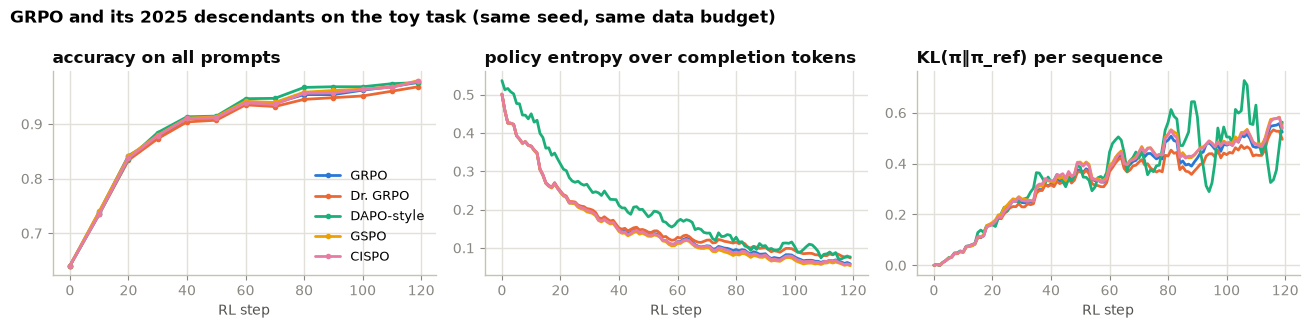

In [173]:
variant_logs = {}
with Timer("GRPO variants"):
    for cfg in VARIANTS:
        seed_everything(0)
        pol = copy.deepcopy(sft_model)
        variant_logs[cfg.name] = train_llm_rl(make_rl_step(pol, sft_model, cfg), pol, steps=120, verbose=False)
        lg = variant_logs[cfg.name]
        print(f"  {cfg.name:11s} final accuracy {lg['eval_acc'][-1]:.3f} (hard {lg['eval_hard'][-1]:.3f}) | KL {np.mean(lg['kl'][-10:]):.2f} | entropy {np.nanmean(lg['entropy'][-10:]):.3f} | length {np.mean(lg['length'][-10:]):.2f}")

plot_llm_runs(variant_logs, "GRPO and its 2025 descendants on the toy task (same seed, same data budget)",
              keys=("eval_acc", "entropy", "kl"), titles=("accuracy on all prompts", "policy entropy over completion tokens", "KL(π‖π_ref) per sequence"))

**What to look for.** On a three-token task every variant solves the problem, so the accuracy curves
bunch together; the *side channels* are where the design choices show. The DAPO-style run keeps a
visibly higher entropy: partly clip-higher doing its job, and partly a selection effect, because with
dynamic sampling the entropy is measured only on the informative (not-yet-solved) groups. Be suspicious of
any single-metric comparison of RL recipes; they interact with what is in the batch. Where these
differences really matter is over tens of thousands of steps of long chain-of-thought training, where
entropy collapse means the model stops exploring and plateaus, and where token-ratio noise over thousands
of tokens makes GSPO/CISPO-style weighting the difference between a stable and a divergent run.

**GSPO's clip range** looks absurd (the paper uses $\epsilon_{\text{low}} = 3\cdot10^{-4}$,
$\epsilon_{\text{high}} = 4\cdot10^{-4}$; we use ten times that for our three-token sequences) until you
remember its ratio is a *geometric mean* over tokens: a sequence-level ratio of 1.0004 means the token
ratios drifted by that factor *on average*, which over thousands of tokens is a substantial change.

### Off-policy corrections for asynchronous systems (2025–26)

A practical development behind the newest recipes: production trainers generate rollouts on a separate
inference engine (vLLM, SGLang) that runs a few steps *behind* the trainer, often with different numerics.
That makes every batch slightly off-policy even at "epoch 1", and token-level ratios blow up on long
sequences. The fixes are all importance-sampling corrections: sequence-level ratios (GSPO), truncated
importance sampling against the inference engine's log-probs (Yao et al., 2025, "Your efficient RL
framework secretly brings you off-policy RL training"), and decoupled clipping. If you read a 2026
training report and see "TIS", "MIS", "IcePop" or "sequence-level IS", this is the problem being solved.

### Test your knowledge

In [174]:
register_quiz('16.1',
    "Why does dividing each response's loss by its length |y_i| (as in GRPO) tend to make responses longer?",
    ['Because the KL term grows with length', "For a wrong answer (negative advantage) the per-token penalty is spread thinner over a long response, so being long is 'cheaper' when wrong; for a right answer, being short concentrates the reward", 'Longer responses get more tokens of positive advantage', "It doesn't; length grows because of the clip"],
    'd4fb8e91f73267189f663716d6a6d73b6acc3456500ec79bdf8f68185ac42d33',
    'RHIuIEdSUE8gYW5kIERBUE8gYm90aCBzd2l0Y2ggdG8gYSB0b2tlbi1sZXZlbCAoY29uc3RhbnQtbm9ybWFsaXNlcikgYWdncmVnYXRpb24gZm9yIGV4YWN0bHkgdGhpcyByZWFzb24uIExlbmd0aCBncm93dGggaW4gUjEtc3R5bGUgdHJhaW5pbmcgaXMgcGFydGx5IHJlYWwgcmVhc29uaW5nIGFuZCBwYXJ0bHkgdGhpcyBhcnRlZmFjdC4=')
quiz('16.1')

QUIZ 16.1: Why does dividing each response's loss by its length |y_i| (as in GRPO) tend to make responses longer?

   A)  Because the KL term grows with length
   B)  For a wrong answer (negative advantage) the per-token penalty is spread thinner over a long response, so being long is 'cheaper' when wrong; for a right answer, being short concentrates the reward
   C)  Longer responses get more tokens of positive advantage
   D)  It doesn't; length grows because of the clip

-> put your choice in the answer('16.1', ...) cell below and run it.


In [175]:
answer('16.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [176]:
register_quiz('16.2',
    'What is the key difference between PPO-style clipping and CISPO?',
    ["PPO's clip zeroes the gradient of tokens outside the trust region; CISPO clips the importance WEIGHT but detaches it, so every token still contributes a (bounded) gradient", 'CISPO uses a smaller learning rate', 'CISPO removes importance sampling entirely', 'CISPO clips at the sequence level'],
    'e304d7a516279092798cd482362029b01c767c34f4b0b1d8282e13f7ff964acb',
    'UmFyZSBwaXZvdGFsIHRva2VucyAoJ3dhaXQnLCAnaG93ZXZlcicpIG9mdGVuIGhhdmUgbGFyZ2UgcmF0aW9zIGFmdGVyIG9uZSB1cGRhdGUgYW5kIHdvdWxkIGJlIHNpbGVuY2VkIGJ5IFBQTydzIGNsaXAuIENJU1BPIGtlZXBzIHRoZWlyIHNpZ25hbCB3aGlsZSBib3VuZGluZyB0aGVpciB3ZWlnaHQsIHdoaWNoIE1pbmlNYXggZm91bmQgYWNjZWxlcmF0ZWQgcmVhc29uaW5nIHRyYWluaW5nLg==')
quiz('16.2')

QUIZ 16.2: What is the key difference between PPO-style clipping and CISPO?

   A)  PPO's clip zeroes the gradient of tokens outside the trust region; CISPO clips the importance WEIGHT but detaches it, so every token still contributes a (bounded) gradient
   B)  CISPO uses a smaller learning rate
   C)  CISPO removes importance sampling entirely
   D)  CISPO clips at the sequence level

-> put your choice in the answer('16.2', ...) cell below and run it.


In [177]:
answer('16.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [178]:
register_quiz('16.3',
    'GSPO computes ONE importance ratio per sequence, the length-normalised product of token ratios. What problem does this address?',
    ['Token-level ratios are single-sample estimates whose noise accumulates over long sequences (and flips with MoE expert routing), causing unstable updates; sequence-level weighting matches the sequence-level reward', 'The need for a critic', 'Slow generation', "The KL estimator's bias"],
    '7ffba4f912533033b8f3a01a0787109baaf2c3d98bc34c8a47722dd1f54b98d3',
    'R1NQTydzIGF1dGhvcnMgYXJndWUgdGhlIHVuaXQgb2Ygb3B0aW1pc2F0aW9uIHNob3VsZCBtYXRjaCB0aGUgdW5pdCBvZiByZXdhcmQ6IHRoZSByZXdhcmQgaXMgcGVyIHNlcXVlbmNlLCBzbyB0aGUgaW1wb3J0YW5jZSB3ZWlnaHQgYW5kIHRoZSBjbGlwcGluZyBkZWNpc2lvbiBzaG91bGQgYmUgcGVyIHNlcXVlbmNlIHRvby4=')
quiz('16.3')

QUIZ 16.3: GSPO computes ONE importance ratio per sequence, the length-normalised product of token ratios. What problem does this address?

   A)  Token-level ratios are single-sample estimates whose noise accumulates over long sequences (and flips with MoE expert routing), causing unstable updates; sequence-level weighting matches the sequence-level reward
   B)  The need for a critic
   C)  Slow generation
   D)  The KL estimator's bias

-> put your choice in the answer('16.3', ...) cell below and run it.


In [179]:
answer('16.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 16.4 · GSPO's sequence-level ratio

Implement `gspo_ratio(logp, old_logp, mask)` returning a `(B,)` tensor: the length-normalised sequence ratio
$s_i = \exp\big(\frac{1}{|y_i|}\sum_t (\log\pi_\theta - \log\pi_{\text{old}})\big)$ using only masked tokens.

In [180]:
def gspo_ratio(logp, old_logp, mask):
    # YOUR CODE HERE
    raise NotImplementedError

In [181]:
register_exercise('16.4', 'ZGVmIGdzcG9fcmF0aW8obG9ncCwgb2xkX2xvZ3AsIG1hc2spOgogICAgbG9nX3JhdGlvID0gKChsb2dwIC0gb2xkX2xvZ3ApICogbWFzaykuc3VtKDEpIC8gbWFzay5zdW0oMSkKICAgIHJldHVybiB0b3JjaC5leHAobG9nX3JhdGlvKQ==')

def _tests(fn):
    logp = torch.tensor([[-1.0, -1.0, -5.0], [-2.0, -1.0, -1.0]]); old = torch.tensor([[-1.5, -0.5, 0.0], [-2.0, -2.0, -1.0]])
    mask = torch.tensor([[1.0, 1.0, 0.0], [1.0, 1.0, 1.0]])
    out = fn(logp, old, mask)
    exp = torch.tensor([math.exp(((-1 + 1.5) + (-1 + 0.5)) / 2), math.exp((0 + 1 + 0) / 3)])
    assert out is not None and torch.allclose(out, exp, atol=1e-6), f"expected {exp.tolist()}, got {out.tolist()} (did you ignore masked tokens?)"

check('16.4', gspo_ratio, _tests)
# solution('16.4')   # <- uncomment to reveal the reference solution

[16.4] not implemented yet. Fill in the cell above (or run solution('16.4')).


---
# Part 17 · Agentic RL: multi-turn episodes, tools, and loss masking

Coding assistants, research agents and computer-use models are trained with the same algorithms as
Parts 12–16, but the *episode* looks different. A single trajectory is now:

```
prompt → model turn → tool call → tool output → model turn → tool call → … → final answer → reward
```

The tool outputs (a compiler error, a search result, a file's contents) are **observations from the
environment**, not actions. That changes four things in the implementation:

1. **Loss masking.** Only tokens the model generated get a gradient (and an importance ratio). Tool
   outputs are masked out exactly like the prompt. Getting this wrong makes the model learn to
   *predict* tool outputs, which is both useless and a source of hallucinated tool results.
2. **Rewards are outcome-based and often verifiable**: tests pass, the task's checker succeeds, the
   answer matches. Costs (tokens, tool latency, number of turns) are usually folded in as small penalties.
3. **Credit assignment spans many turns.** Most systems still assign the same sequence-level advantage
   to every model token of the whole multi-turn trajectory (GRPO-style); finer per-turn credit is an
   open research area.
4. **Rollouts are long, slow and asynchronous**, so training is partially off-policy, which is what the
   importance-sampling corrections at the end of Part 16 are for.

## A calculator tool for our toy model

We give the model a `<call>` token. When it emits one, the environment appends `<obs> digits <obs>` with
the correct sum and the model continues. The tool is free to *use* but we charge a small cost
(0.25 reward) per call, so the interesting question is: **does the policy learn to call the tool only when
it needs to?** We fine-tune a fresh model on demonstrations that use the tool half the time regardless of
difficulty; its *direct* answers are reliable on easy prompts and right only one time in five on hard ones.

In [182]:
def calculator_obs(prompt_tokens):
    a = 10 * int(prompt_tokens[0]) + int(prompt_tokens[1]); b = 10 * int(prompt_tokens[3]) + int(prompt_tokens[4])
    return [OBS] + [int(ch) for ch in str(a + b)] + [OBS]

@torch.no_grad()
def generate_with_tool(model, prompts, max_len=CTX, temperature=1.0, greedy=False):
    '''Agentic generation loop. On <call> the environment inserts the calculator's observation tokens.
    Returns seq (B, max_len) and gen_mask (B, max_len - PROMPT_LEN): 1 for MODEL tokens, 0 for env tokens / padding.'''
    B = prompts.shape[0]
    seqs = [p.tolist() for p in prompts]; roles = [[] for _ in range(B)]; alive = [True] * B
    while any(alive):
        idx = [i for i in range(B) if alive[i]]
        L = max(len(seqs[i]) for i in idx)
        batch = torch.full((len(idx), L), PAD, dtype=torch.long)
        for k, i in enumerate(idx): batch[k, :len(seqs[i])] = torch.tensor(seqs[i])
        logits = model(batch)[torch.arange(len(idx)), torch.tensor([len(seqs[i]) - 1 for i in idx])] / temperature
        nxt = logits.argmax(-1) if greedy else torch.multinomial(F.softmax(logits, -1), 1).squeeze(1)
        for k, i in enumerate(idx):
            t = int(nxt[k]); seqs[i].append(t); roles[i].append(1)                  # model token
            if t == EOS or len(seqs[i]) >= max_len:
                alive[i] = False
            elif t == CALL:                                                          # environment turn
                for o in calculator_obs(seqs[i][:PROMPT_LEN]):
                    if len(seqs[i]) < max_len: seqs[i].append(o); roles[i].append(0)
                if len(seqs[i]) >= max_len: alive[i] = False
    seq = torch.full((B, max_len), PAD, dtype=torch.long); gen_mask = torch.zeros(B, max_len - PROMPT_LEN)
    for i in range(B):
        seq[i, :len(seqs[i])] = torch.tensor(seqs[i]); gen_mask[i, :len(roles[i])] = torch.tensor(roles[i], dtype=torch.float32)
    return seq, gen_mask

def used_tool(tokens): return CALL in [int(t) for t in tokens]

def verify_tool(a, b, completion_tokens):
    '''Final answer = digits after the last <obs> (if the tool was used), else the whole completion.'''
    toks = [int(t) for t in completion_tokens]
    if OBS in toks:
        last_obs = max(i for i, t in enumerate(toks) if t == OBS); toks = toks[last_obs + 1:]
    return verify(a, b, toks)

TOOL_COST = 0.25
tool_reward = lambda a, b, seq: verify_tool(a, b, seq[PROMPT_LEN:].tolist()) - TOOL_COST * used_tool(seq[PROMPT_LEN:].tolist())

def roles_for_completion(y):
    '''1 for model tokens, 0 for the environment's <obs>...<obs> segment.'''
    roles, in_obs, seen = [], False, 0
    for t in y:
        if t == OBS:
            roles.append(0); seen += 1; in_obs = (seen % 2 == 1)
        else:
            roles.append(0 if in_obs else 1)
    return roles

def make_tool_sft_dataset(pairs, per_prompt=8, tool_prob=0.5, hard_correct_prob=0.5):
    X, Y, R = [], [], []
    for a, b in pairs:
        for _ in range(per_prompt):
            X.append(encode_prompt(a, b))
            if np.random.rand() < tool_prob:                                        # demonstration with the tool
                y = [CALL] + calculator_obs(X[-1]) + encode_answer(a + b)
            else:                                                                   # direct answer, noisy on hard prompts
                ans = a + b
                if not is_easy(a, b) and np.random.rand() > hard_correct_prob:
                    ans = max(0, ans + int(np.random.choice([d for d in range(-9, 10) if d != 0])))
                y = encode_answer(ans)
            Y.append(y); R.append(roles_for_completion(y))
    return X, Y, R

In [183]:
seed_everything(0)
X_tool, Y_tool, R_tool = make_tool_sft_dataset(ALL_PAIRS, hard_correct_prob=0.2)   # direct hard answers: right 1 time in 5
i = next(k for k in range(len(Y_tool)) if CALL in Y_tool[k])
print("tool demonstration:", decode(X_tool[i]), "->", decode(Y_tool[i]), "| loss mask:", R_tool[i])
tool_sft_model = TinyLM()
with Timer("tool SFT"):
    sft_train(tool_sft_model, X_tool, Y_tool, roles=R_tool, total_len=CTX)

tool demonstration: 00+00= -> <call><obs>0<obs>0<eos> | loss mask: [1, 0, 0, 0, 1, 1]


  sft step 500: loss 0.571


  sft step 1000: loss 0.464


  sft step 1500: loss 0.403
[tool SFT] 27.6s


In [184]:
@torch.no_grad()
def tool_stats(model, n_samples=4):
    out = {}
    for tier, pairs in [("easy", EASY_PAIRS), ("hard", HARD_PAIRS)]:
        seq, _ = generate_with_tool(model, batch_prompts(pairs, n_samples))
        out[f"tool_rate_{tier}"] = float(np.mean([used_tool(s[PROMPT_LEN:].tolist()) for s in seq]))
    return out

_, ev = evaluate_lm(tool_sft_model, n_samples=4, gen_fn=generate_with_tool, verify_fn=verify_tool)
print("tool-SFT model: accuracy {acc:.3f} (easy {easy:.2f}, hard {hard:.2f})".format(**ev), "| tool use:", tool_stats(tool_sft_model))
seed_everything(3)
seq, gm = generate_with_tool(tool_sft_model, batch_prompts([(3, 4), (16, 17)], 3))
for s, m in zip(seq, gm):
    print(f"  {decode(s[:PROMPT_LEN]):8s} {decode(s[PROMPT_LEN:]):22s} model-token mask: {m[:int((s != PAD).sum()) - PROMPT_LEN].int().tolist()}")

tool-SFT model: accuracy 0.692 (easy 0.98, hard 0.59) | tool use: {'tool_rate_easy': 0.48, 'tool_rate_hard': 0.48333333333333334}
  03+04=   7<eos>                 model-token mask: [1, 1]
  03+04=   7<eos>                 model-token mask: [1, 1]
  03+04=   <call><obs>7<obs>7<eos> model-token mask: [1, 0, 0, 0, 1, 1]
  16+17=   <call><obs>33<obs>33<eos> model-token mask: [1, 0, 0, 0, 0, 1, 1, 1]
  16+17=   <call><obs>33<obs>33<eos> model-token mask: [1, 0, 0, 0, 0, 1, 1, 1]
  16+17=   <call><obs>33<obs>33<eos> model-token mask: [1, 0, 0, 0, 0, 1, 1, 1]


The SFT model uses the tool about half the time regardless of difficulty, because that is what the
demonstrations did. Now we run GRPO with the tool-aware reward. Everything from Part 16 is reused
unchanged; the only differences are the generation function and the mask it returns.

[agentic GRPO] 23.2s


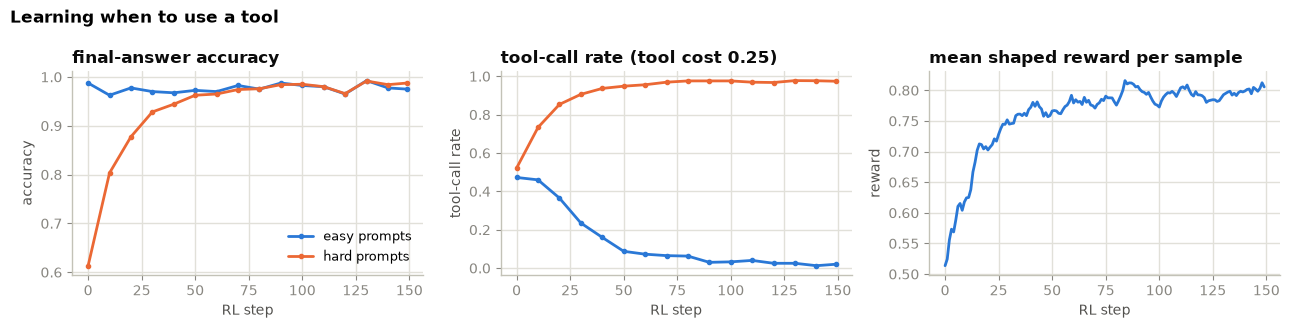

final tool-use rates: {'tool_rate_easy': 0.015, 'tool_rate_hard': 0.9733333333333334}
  02+05=   -> 7<eos>
  02+05=   -> 7<eos>
  07+01=   -> 8<eos>
  07+01=   -> 8<eos>
  14+18=   -> <call><obs>32<obs>32<eos>
  14+18=   -> <call><obs>32<obs>32<eos>
  19+09=   -> <call><obs>28<obs>28<eos>
  19+09=   -> <call><obs>28<obs>28<eos>


In [185]:
seed_everything(0)
policy_tool = copy.deepcopy(tool_sft_model)
cfg_tool = RLConfig("GRPO (tool)", beta=0.02)
with Timer("agentic GRPO"):
    log_tool = train_llm_rl(make_rl_step(policy_tool, tool_sft_model, cfg_tool, reward_fn=tool_reward, gen_fn=generate_with_tool),
                            policy_tool, steps=150, gen_fn=generate_with_tool, verify_fn=verify_tool, extra_eval=tool_stats, verbose=False)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
axes[0].plot(log_tool["eval_step"], log_tool["eval_easy"], marker="o", ms=3, label="easy prompts"); axes[0].plot(log_tool["eval_step"], log_tool["eval_hard"], marker="o", ms=3, label="hard prompts")
finish(axes[0], "final-answer accuracy", "RL step", "accuracy")
axes[1].plot(log_tool["eval_step"], log_tool["tool_rate_easy"], marker="o", ms=3, label="easy prompts"); axes[1].plot(log_tool["eval_step"], log_tool["tool_rate_hard"], marker="o", ms=3, label="hard prompts")
finish(axes[1], f"tool-call rate (tool cost {TOOL_COST})", "RL step", "tool-call rate", legend=False)
axes[2].plot(smooth(log_tool["reward"], 5)); finish(axes[2], "mean shaped reward per sample", "RL step", "reward", legend=False)
plt.suptitle("Learning when to use a tool", x=0.01, ha="left", fontsize=12, fontweight="bold"); plt.tight_layout(); plt.show()
print("final tool-use rates:", tool_stats(policy_tool))
seed_everything(4); seq, _ = generate_with_tool(policy_tool, batch_prompts([(2, 5), (7, 1), (14, 18), (19, 9)], 2))
for s in seq: print(f"  {decode(s[:PROMPT_LEN]):8s} -> {decode(s[PROMPT_LEN:])}")

The policy was never told which prompts are hard. It discovered from reward alone that a 0.25 tool
cost is worth paying when its own answer is unreliable and not otherwise. Scale this up (thousands of
tools, tests as the verifier, long multi-turn trajectories, an asynchronous rollout fleet) and you have
the training loop behind current coding agents.

Try `hard_correct_prob=0.5` in the SFT data: the direct answers are then good enough that RL *sharpens
them past the tool's 0.75 payoff* and the policy abandons the tool on hard prompts too. Whether an agent
internalises a skill or outsources it depends on the tool's cost relative to its own reliability, and RL
will find that break-even point.

### What is still hard (and where the field is going)
* **Credit assignment across turns.** One scalar for a 50-turn trajectory is a weak signal. Process
  reward models, turn-level advantages and learned critics for agents are active work.
* **Reward hacking with real tools.** An agent rewarded for "tests pass" can delete the tests, mock the
  network, or special-case the checker. Sandboxes, held-out tests and judge models are part of the reward.
* **Environment engineering.** Most of the effort in agentic RL now goes into building diverse,
  verifiable environments and curricula, not into the loss function.
* **Off-policy stability at scale.** Long rollouts force asynchrony; sequence-level importance
  sampling (GSPO), truncated IS, and periodic reference resets (ProRL) are the current tools.

### Test your knowledge

In [186]:
register_quiz('17.1',
    'Why must tool-output tokens be excluded from the policy-gradient loss?',
    ['Because they contain digits', 'They are too long', 'They should be included; masking is only for padding', 'They were produced by the environment, not sampled from the policy, so they carry no action for the gradient to reinforce and including them would train the model to imitate (hallucinate) tool outputs'],
    '55f53d89d8fe00577113b9127681504562d5aaea24a852d92b57c14d1fc2f2e4',
    'SW4gTURQIHRlcm1zIHRoZSBvYnNlcnZhdGlvbiBpcyBwYXJ0IG9mIHNfe3QrMX0sIG5vdCBhX3QuIFRoZSBsb2ctcHJvYmFiaWxpdHkgcmF0aW8gYW5kIHRoZSBhZHZhbnRhZ2Ugb25seSBtYWtlIHNlbnNlIGZvciB0b2tlbnMgdGhlIHBvbGljeSBjaG9zZS4gUHJvbXB0IHRva2VucyBhcmUgbWFza2VkIGZvciB0aGUgc2FtZSByZWFzb24u')
quiz('17.1')

QUIZ 17.1: Why must tool-output tokens be excluded from the policy-gradient loss?

   A)  Because they contain digits
   B)  They are too long
   C)  They should be included; masking is only for padding
   D)  They were produced by the environment, not sampled from the policy, so they carry no action for the gradient to reinforce and including them would train the model to imitate (hallucinate) tool outputs

-> put your choice in the answer('17.1', ...) cell below and run it.


In [187]:
answer('17.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [188]:
register_quiz('17.2',
    'In our experiment, why did the policy keep calling the tool on hard prompts instead of eventually learning to add directly?',
    ['The KL penalty forbids direct answers', 'The tool cost was zero', 'Hard prompts have no correct answer', 'Once it routes hard prompts to the tool it stops generating direct answers for them, so it collects no data that would improve its direct accuracy: the equilibrium is self-reinforcing'],
    '0747b2e3bb2a45a00c33f1aff2498f0ecf0838bb9a0af71c6a52bef10eb4ea82',
    'Ukwgb25seSBpbXByb3ZlcyBiZWhhdmlvdXJzIGl0IHNhbXBsZXMuIFRoaXMgaXMgYSBzbWFsbCBleGFtcGxlIG9mIGEgZ2VuZXJhbCBwaGVub21lbm9uOiB0aGUgcG9saWN5J3MgZXhwbG9yYXRpb24gaXMgc2hhcGVkIGJ5IGl0cyBjdXJyZW50IHN0cmF0ZWd5LCBhbmQgYSBjaGVhcCB0b29sIGNhbiBjcm93ZCBvdXQgbGVhcm5pbmcgdGhlIHVuZGVybHlpbmcgc2tpbGwu')
quiz('17.2')

QUIZ 17.2: In our experiment, why did the policy keep calling the tool on hard prompts instead of eventually learning to add directly?

   A)  The KL penalty forbids direct answers
   B)  The tool cost was zero
   C)  Hard prompts have no correct answer
   D)  Once it routes hard prompts to the tool it stops generating direct answers for them, so it collects no data that would improve its direct accuracy: the equilibrium is self-reinforcing

-> put your choice in the answer('17.2', ...) cell below and run it.


In [189]:
answer('17.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [190]:
register_quiz('17.3',
    "A coding agent is rewarded when the repository's tests pass. Which is a realistic reward-hacking risk?",
    ['The agent modifies or deletes the failing tests, or special-cases the test inputs, so the checker passes without solving the task', 'The agent refuses to use tools', 'None; test passing is a verifiable reward and cannot be hacked', 'The agent writes code that is too well documented'],
    '5f63e49e168941484435fbf3a53c687d6cd32761f969e84292d14b21b5841447',
    'VmVyaWZpYWJsZSBkb2VzIG5vdCBtZWFuIHVuLWhhY2thYmxlLiBQcm9kdWN0aW9uIHNldHVwcyBob2xkIG91dCB0ZXN0cyB0aGUgYWdlbnQgY2Fubm90IHNlZSwgcnVuIGluIHNhbmRib3hlcywgYW5kIGFkZCBqdWRnZSBtb2RlbHMgb3IgcnVsZSBjaGVja3MgZm9yIHN1Y2ggYmVoYXZpb3VycywgYW5kIHRob3NlIGNoZWNrcyB0aGVtc2VsdmVzIGJlY29tZSBwYXJ0IG9mIHRoZSByZXdhcmQu')
quiz('17.3')

QUIZ 17.3: A coding agent is rewarded when the repository's tests pass. Which is a realistic reward-hacking risk?

   A)  The agent modifies or deletes the failing tests, or special-cases the test inputs, so the checker passes without solving the task
   B)  The agent refuses to use tools
   C)  None; test passing is a verifiable reward and cannot be hacked
   D)  The agent writes code that is too well documented

-> put your choice in the answer('17.3', ...) cell below and run it.


In [191]:
answer('17.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


### Exercise 17.4 · Masked sequence log-probability with roles

Implement `masked_seq_logprob(logp, roles)` where `logp` is `(B, T)` per-token log-probs of a completion and
`roles` is `(B, T)` with 1 for model tokens and 0 for environment tokens or padding. Return the `(B,)` tensor of
summed log-probs over **model tokens only**. (This is the quantity RLOO/GRPO use for agentic trajectories.)

In [192]:
def masked_seq_logprob(logp, roles):
    # YOUR CODE HERE
    raise NotImplementedError

In [193]:
register_exercise('17.4', 'ZGVmIG1hc2tlZF9zZXFfbG9ncHJvYihsb2dwLCByb2xlcyk6CiAgICByZXR1cm4gKGxvZ3AgKiByb2xlcykuc3VtKDEp')

def _tests(fn):
    logp = torch.tensor([[-1.0, -2.0, -3.0, -4.0], [-0.5, -0.5, -0.5, -0.5]]); roles = torch.tensor([[1.0, 0.0, 0.0, 1.0], [1.0, 1.0, 0.0, 0.0]])
    out = fn(logp, roles)
    assert out is not None and torch.allclose(out, torch.tensor([-5.0, -1.0])), f"got {out.tolist() if out is not None else None}"

check('17.4', masked_seq_logprob, _tests)
# solution('17.4')   # <- uncomment to reveal the reference solution

[17.4] not implemented yet. Fill in the cell above (or run solution('17.4')).


---
# Part 18 · Wrap-up: the map

## One table

| Algorithm | Family | On/off-policy | Learns | Baseline / critic | Key trick | Where you meet it |
|---|---|---|---|---|---|---|
| Value iteration / policy iteration | DP | model-based | $V^*$ | exact | Bellman contraction | planning, textbooks |
| MC / TD(0) / SARSA | tabular | on-policy | $V$, $Q$ | none | bootstrapping | foundations |
| Q-learning / DQN / Double DQN | value-based | off-policy | $Q^*$ | none (target net) | replay + target network | Atari, discrete control |
| REINFORCE | policy gradient | on-policy | $\pi$ | optional constant | log-derivative trick, reward-to-go | teaching, bandits |
| A2C / A3C | actor-critic | on-policy | $\pi$, $V$ | learned $V$ | GAE advantages | classic deep RL |
| TRPO | trust region | on-policy | $\pi$, $V$ | learned $V$ | natural gradient + KL constraint | robotics (historical) |
| PPO | trust region (1st order) | almost on-policy | $\pi$, $V$ | learned $V$ | clipped ratio, many epochs | robotics, games, RLHF |
| PPO-RLHF | PPO + LLM | almost on-policy | $\pi$, $V$ | value LM | per-token KL reward | InstructGPT, ChatGPT era |
| DPO / IPO / KTO / SimPO | preference optimisation | offline | $\pi$ | implicit reward | closed-form RLHF solution | open chat models |
| RLOO / REINFORCE++ | critic-free PG | on-policy | $\pi$ | leave-one-out / batch stats | Monte Carlo baseline | 2024–25 LLM RL |
| GRPO | critic-free PG | almost on-policy | $\pi$ | group mean/std | group-normalised advantages, k3 KL | DeepSeek-R1 and descendants |
| Dr. GRPO / DAPO / Lite PPO | GRPO fixes | almost on-policy | $\pi$ | group mean | token-level loss, clip-higher, dynamic sampling | 2025 open reasoning models |
| GSPO | sequence-level PG | almost on-policy | $\pi$ | group mean/std | sequence-level ratio & clip | Qwen3 |
| CISPO | REINFORCE + clipped IS | almost on-policy | $\pi$ | group | detached clipped weights, no dead tokens | MiniMax-M1, ScaleRL |
| VAPO | value-based LLM RL | almost on-policy | $\pi$, $V$ | value LM | critic pre-training, decoupled GAE | ByteDance Seed |

## A decision guide

* **Small discrete problem, known model?** Value iteration. Done.
* **Discrete actions, cheap simulator, want sample efficiency?** DQN family (add Double DQN, prioritised replay, n-step, dueling: "Rainbow").
* **Continuous control or you just want something that works?** PPO. Tune epochs, clip, entropy, and *always* look at approx-KL and clip fraction.
* **Aligning an LLM to preferences with limited compute?** DPO (or SimPO) on a good preference set; iterate online if you can.
* **Improving an LLM on a task with a verifier (maths, code, agents)?** GRPO-style with the 2025 fixes: token-level loss, clip-higher, dynamic sampling, no or small KL, sequence-level or detached importance weights if your rollouts are async. Spend your effort on the environment and the reward.
* **Something breaks?** Check, in order: the loss mask, the done/truncation flags, the advantage normalisation, the KL/clip diagnostics, the reward function for exploits.

## Reading list (in the order the notebook covered them)

* Sutton & Barto, *Reinforcement Learning: An Introduction* (2nd ed.), Parts I–II: everything in Parts 1–4.
* Mnih et al., 2015, "Human-level control through deep reinforcement learning" (DQN); van Hasselt et al., 2016 (Double DQN).
* Williams, 1992 (REINFORCE); Sutton et al., 2000 (policy gradient theorem); Schulman et al., 2016 (GAE).
* Schulman et al., 2015 (TRPO); Schulman et al., 2017 (PPO); Engstrom et al., 2020, "Implementation matters in deep policy gradients".
* Ziegler et al., 2019 and Ouyang et al., 2022 (RLHF / InstructGPT); Gao et al., 2022 (reward-model over-optimisation).
* Rafailov et al., 2023 (DPO); Azar et al., 2023 (IPO); Ethayarajh et al., 2024 (KTO); Meng et al., 2024 (SimPO).
* Ahmadian et al., 2024 (RLOO, "Back to basics"); Hu, 2025 (REINFORCE++).
* Shao et al., 2024 (GRPO, DeepSeekMath); DeepSeek-AI, 2025 (DeepSeek-R1).
* Liu et al., 2025 (Dr. GRPO); Yu et al., 2025 (DAPO); Yue et al., 2025 (VAPO); Zheng et al., 2025 (GSPO); MiniMax, 2025 (CISPO); Khatri et al., 2025 (ScaleRL); Liu et al., 2025 (Lite PPO); Yue et al., 2025, "Does RL really incentivize reasoning capacity beyond the base model?".

## Where to go next (project ideas)

1. Add prioritised replay and dueling heads to the DQN and measure the gain on CartPole with 3 seeds.
2. Give the CartPole PPO a *continuous* action version (Gaussian policy) on a NumPy pendulum.
3. Replace the arithmetic verifier with a **learned judge** and measure how fast each GRPO variant hacks it.
4. Make the calculator tool *unreliable* (wrong 20% of the time) and see whether the policy learns to double-check.
5. Port the GRPO variants to a real small model (e.g. a 0.5B parameter instruction model with HuggingFace TRL) on GSM8K, and see which of the toy-task differences survive.

## Final self-test

In [194]:
register_quiz('18.1',
    'Which pair correctly matches an algorithm with the quantity it uses as a baseline?',
    ['PPO-RLHF: the group mean reward', 'REINFORCE: the KL to the reference', 'RLOO: the mean reward of the other K-1 samples for the same prompt', 'GRPO: a learned value model'],
    'c0017c6c405a65488eb15a9852d11575de7098ab0581a792a097ddf0502594bc',
    'UFBPLVJMSEYgdXNlcyBhIHZhbHVlIExNLCBHUlBPIHRoZSBncm91cCBtZWFuIChkaXZpZGVkIGJ5IHN0ZCksIFJMT08gdGhlIGxlYXZlLW9uZS1vdXQgbWVhbiwgcGxhaW4gUkVJTkZPUkNFIG5vbmUu')
quiz('18.1')

QUIZ 18.1: Which pair correctly matches an algorithm with the quantity it uses as a baseline?

   A)  PPO-RLHF: the group mean reward
   B)  REINFORCE: the KL to the reference
   C)  RLOO: the mean reward of the other K-1 samples for the same prompt
   D)  GRPO: a learned value model

-> put your choice in the answer('18.1', ...) cell below and run it.


In [195]:
answer('18.1', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [196]:
register_quiz('18.2',
    'You are training a 30B reasoning model with 8k-token responses and rollouts generated asynchronously by a separate inference cluster. Which combination is most in line with 2025-26 practice?',
    ['TRPO with conjugate gradient over all 30B parameters', 'A GRPO-family loss with token-level aggregation, clip-higher or detached clipped weights (CISPO), sequence-level or truncated importance sampling to handle the off-policy rollouts, dynamic sampling, and verifiable rewards', 'Offline DPO on a fixed dataset', 'Tabular Q-learning with a large table'],
    'fb205a255ab84e3506a2b1ff86730ba4b572d1ff2d5e98ef8c234f167e011b7b',
    'VGhhdCBsaXN0IGlzIGVzc2VudGlhbGx5IHRoZSB1bmlvbiBvZiBEQVBPLCBHU1BPL0NJU1BPIGFuZCBTY2FsZVJMJ3MgcmVjb21tZW5kYXRpb25zLCB3aGljaCBpcyB3aGF0IGN1cnJlbnQgb3BlbiByZXBvcnRzIGNvbnZlcmdlIG9uLg==')
quiz('18.2')

QUIZ 18.2: You are training a 30B reasoning model with 8k-token responses and rollouts generated asynchronously by a separate inference cluster. Which combination is most in line with 2025-26 practice?

   A)  TRPO with conjugate gradient over all 30B parameters
   B)  A GRPO-family loss with token-level aggregation, clip-higher or detached clipped weights (CISPO), sequence-level or truncated importance sampling to handle the off-policy rollouts, dynamic sampling, and verifiable rewards
   C)  Offline DPO on a fixed dataset
   D)  Tabular Q-learning with a large table

-> put your choice in the answer('18.2', ...) cell below and run it.


In [197]:
answer('18.2', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [198]:
register_quiz('18.3',
    "Across the whole notebook, which single idea appears in the incremental bandit update, TD learning, GAE, PPO's critic, and PPO-RLHF's value model?",
    ['Importance sampling', 'New estimate = old estimate + step size * (target - old estimate)', 'Clipping', 'Group normalisation'],
    'f152144bd28df3762eef54b970a05547bbe5e79b8ef4e463146ecde2055333be',
    'VGhlIHNhbWUgZXJyb3ItZHJpdmVuIHVwZGF0ZSBzaGFwZSwgd2l0aCBkaWZmZXJlbnQgdGFyZ2V0czogYSByZXdhcmQgc2FtcGxlLCBhIGJvb3RzdHJhcHBlZCBURCB0YXJnZXQsIGEgbGFtYmRhLXJldHVybiwgYSBzaGFwZWQgdG9rZW4gcmV0dXJuLiBSZWNvZ25pc2luZyBpdCBpcyBtb3N0IG9mIHRoZSB3YXkgdG8gcmVhZGluZyBhbnkgUkwgcGFwZXIu')
quiz('18.3')

QUIZ 18.3: Across the whole notebook, which single idea appears in the incremental bandit update, TD learning, GAE, PPO's critic, and PPO-RLHF's value model?

   A)  Importance sampling
   B)  New estimate = old estimate + step size * (target - old estimate)
   C)  Clipping
   D)  Group normalisation

-> put your choice in the answer('18.3', ...) cell below and run it.


In [199]:
answer('18.3', '?')   # <- replace '?' with A, B, C or D and run

Type a single letter: A, B, C or D.


In [200]:
score()
print("Re-run any answer(...) cell to improve your score. Exercises: run solution('<id>') to compare with the reference implementation.")

quiz score: 0 solved / 50 registered (0 attempts)
Re-run any answer(...) cell to improve your score. Exercises: run solution('<id>') to compare with the reference implementation.


*Built as a self-contained learning notebook. Every algorithm here is a faithful but minimal
implementation; production systems add distributed rollouts, mixed precision, KV caches and a great
deal of engineering, but the objectives are the ones you just implemented.*